<a href="https://colab.research.google.com/github/Listpiquito/Tesis_INGE3133_LissettePita/blob/main/LGAC053_INGE3133.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LGAC-053 — Código consolidado de tesis
## Evaluación del diseño de completación y del fracturamiento hidráulico

**ESPOL — Ingeniería en Petróleos**

Notebook organizado según las **5 etapas metodológicas** de la tesis. Al ejecutar todas las celdas se generan automáticamente las tablas y figuras en la carpeta `resultados_LGAC053`.

### Versión con gráficos visibles
Esta versión tiene `MOSTRAR_GRAFICAS = True`, por lo que las figuras se muestran **debajo de las celdas al ejecutar el notebook**, además de guardarse en `resultados_LGAC053/figuras`.

## Configuración general, datos de entrada y funciones auxiliares

In [13]:
"""CÓDIGO CONSOLIDADO FINAL - LGAC-053 / ESPOL\n\nEvaluación post-mortem del fracturamiento hidráulico en Hollín Superior del pozo LGAC-053.

El flujo de trabajo se organiza en cinco etapas:

1. Caracterización petrofísica y capacidad de flujo de Hollín Superior e Inferior.
2. Comportamiento productivo del LGAC-053 y pozos de referencia.
3. Permeabilidades relativas y flujo fraccional de HS-HI, y análisis nodal individual de Hollín Superior.
4. Evaluación post-mortem del fracturamiento hidráulico en Hollín Superior.
5. Evaluación técnico-económica del beneficio incremental de la fractura y propuesta.

El LGAC-053 produce de Hollín Superior e Inferior mediante producción commingled.
El análisis del fracturamiento se realiza específicamente sobre Hollín Superior.

Las tablas se exportan a CSV y las figuras a PNG dentro de ``resultados_LGAC053``.

Dependencias: numpy, pandas, scipy y matplotlib.
"""

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import shutil
from typing import Callable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq

# =============================================================================
# CONFIGURACIÓN
# =============================================================================

CARPETA_RAIZ = Path.cwd() / "resultados_LGAC053"

CARPETAS = {
    1: CARPETA_RAIZ / "etapa_1_caracterizacion_petrofisica",
    2: CARPETA_RAIZ / "etapa_2_comportamiento_productivo",
    3: CARPETA_RAIZ / "etapa_3_analisis_nodal_HS",
    4: CARPETA_RAIZ / "etapa_4_postmortem_fractura_HS",
    5: CARPETA_RAIZ / "etapa_5_evaluacion_tecnico_economica",
}

for carpeta in CARPETAS.values():
    carpeta.mkdir(parents=True, exist_ok=True)

MOSTRAR_GRAFICAS = True
MOSTRAR_TABLAS_CALCULO = False

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "font.size": 10,
    }
)

# Referencia histórica utilizada para calibrar hidráulicamente el análisis nodal.
Q_LIQUIDO_CALIBRACION_BFPD = 1030.5
P_INTAKE_REFERENCIA_PSI = 744.0

# Caudal de la última prueba utilizado para la estimación pre-nodal.
Q_LIQUIDO_PRE_NODAL_BFPD = 735.0

FRECUENCIA_NODAL_HZ = 40.0
TVD_INTAKE_FT = 9826.37

# Swc (Corey), Swi (Buckley-Leverett) y Sw petrofísico se mantienen separados.
SWC_ESCENARIOS = {
    "Swc_bajo": {"HS": 0.10, "HI": 0.14},
    "Base": {"HS": 0.15, "HI": 0.19},
    "Swc_alto": {"HS": 0.20, "HI": 0.24},
}
SWI_BUCKLEY = {
    "HS": 0.15,
    "HI": 0.30,
}
PARAMETROS_COREY = {
    "Sor": 0.30,
    "krw_end": 0.30,
    "kro_end": 0.90,
    "nw": 3.0,
    "no": 2.0,
}

# Para HI se adopta 5 % de BSW en el reparto de fases y el análisis nodal;
# fw(Swi=0.30) es aproximadamente 4.4 %.
BSW_HI_ADOPTADO = 0.05

DATOS_ETAPA_1 = {'HS': {'nombre': 'Hollín Superior',
        'h_neto_ft': 20.0,
        'area_acres': 35.9,
        'h_perforado_ft': 19.0,
        'phi': 0.1319,
        'GR': 30.0,
        'GR_limpio': 25.0,
        'GR_lutita': 190.0,
        'Rt_ohm_m': 50.0,
        'Rsh_ohm_m': 15.0,
        'Rw_75F_ohm_m': 1.0,
        'temperatura_F': 192.0,
        'Bo_RB_STB': 1.073,
        'k_mD': 128.0},
 'HI': {'nombre': 'Hollín Inferior',
        'h_neto_ft': 28.5,
        'area_acres': 35.9,
        'h_perforado_ft': 16.0,
        'phi': 0.147,
        'GR': 18.0,
        'GR_limpio': 15.0,
        'GR_lutita': 170.0,
        'Rt_ohm_m': 1800.0,
        'Rsh_ohm_m': 100.0,
        'Rw_75F_ohm_m': 6.0,
        'temperatura_F': 208.0,
        'Bo_RB_STB': 1.2132,
        'k_mD': 215.0}}

HISTORIALES = {
    "LGAC-053": {
        "arenas": "HS + HI (producción commingled)",
        "datos": {'Fecha': ['01/05/2026',
           '13/05/2026',
           '14/05/2026',
           '15/05/2026',
           '19/05/2026',
           '20/05/2026',
           '13/06/2026',
           '20/06/2026'],
 'BFPD': [1320.9, 1030, 1031, 1026, 949, 909, 747, 735],
 'BPPD': [713.286, 659, 639, 595, 550, 527, 441, 434],
 'BAPD': [607.614, 371, 392, 431, 398, 382, 306, 301],
 'BSW_reportado_pct': [46, 36, 38, 42, 42, 42, 41, 41]},
        "evento": ("01/05/2026", "Inicio de ventana productiva post-intervención"),
    },
    "LGAC-057": {
        "arenas": "HS + HI (producción commingled)",
        "datos": {'Fecha': ['23/04/2026',
           '24/04/2026',
           '25/04/2026',
           '26/04/2026',
           '27/04/2026',
           '28/04/2026',
           '30/04/2026',
           '02/05/2026',
           '10/05/2026',
           '21/05/2026',
           '26/05/2026',
           '30/05/2026',
           '31/05/2026',
           '11/06/2026',
           '19/06/2026',
           '21/06/2026',
           '26/06/2026',
           '27/06/2026',
           '10/07/2026',
           '17/07/2026'],
 'BFPD': [687.537,
          710.262,
          688.02,
          698.174,
          702.042,
          744.29,
          800.676,
          791.006,
          718.481,
          651.081,
          621.433,
          621.433,
          589.87,
          500.035,
          500.035,
          476.731,
          475.087,
          453.523,
          415.481,
          417.744],
 'BPPD': [110.006,
          298.31,
          344.01,
          383.996,
          421.225,
          521.003,
          672.568,
          664.445,
          603.524,
          546.908,
          522.004,
          522.004,
          495.491,
          425.03,
          425.03,
          405.221,
          399.073,
          380.959,
          349.004,
          342.55],
 'BAPD': [577.531,
          411.952,
          344.01,
          314.178,
          280.817,
          223.287,
          128.108,
          126.561,
          114.957,
          104.173,
          99.429,
          99.429,
          94.379,
          75.005,
          75.005,
          71.51,
          76.014,
          72.564,
          66.477,
          75.194],
 'BSW_reportado_pct': [84,
                       58,
                       50,
                       45,
                       40,
                       30,
                       16,
                       16,
                       16,
                       16,
                       16,
                       16,
                       16,
                       15,
                       15,
                       15,
                       16,
                       16,
                       16,
                       18]},
        "evento": ("30/04/2026", "Fin de limpieza e inicio de declinación"),
    },
    "LGAC-056": {
        "arenas": "HS",
        "datos": {'Fecha': ['17/05/2026',
           '18/05/2026',
           '19/05/2026',
           '21/05/2026',
           '22/05/2026',
           '23/05/2026',
           '24/05/2026',
           '25/05/2026',
           '26/05/2026',
           '28/05/2026',
           '29/05/2026',
           '31/05/2026',
           '04/06/2026',
           '05/06/2026',
           '09/06/2026',
           '12/06/2026',
           '19/06/2026',
           '26/06/2026',
           '11/07/2026',
           '20/07/2026',
           '23/07/2026',
           '02/08/2026'],
 'BFPD': [339.15,
          363.185,
          302.29,
          327.028,
          325.66,
          326.23,
          350.009,
          367.442,
          377.179,
          401.85,
          447.45,
          466.45,
          494.95,
          513.95,
          512.05,
          490.2,
          490.2,
          490.675,
          465.272,
          449.033,
          504.133,
          530.733],
 'BPPD': [20.349,
          69.005,
          136.031,
          242.001,
          254.015,
          274.033,
          301.008,
          316.0,
          347.005,
          369.702,
          411.654,
          433.798,
          470.202,
          488.253,
          486.447,
          465.69,
          465.69,
          461.235,
          442.008,
          426.581,
          478.926,
          504.196],
 'BAPD': [318.801,
          294.18,
          166.26,
          85.027,
          71.645,
          52.197,
          49.001,
          51.442,
          30.174,
          32.148,
          35.796,
          32.651,
          24.748,
          25.697,
          25.603,
          24.51,
          24.51,
          29.44,
          23.264,
          22.452,
          25.207,
          26.537],
 'BSW_reportado_pct': [94,
                       81,
                       55,
                       26,
                       22,
                       16,
                       14,
                       14,
                       8,
                       8,
                       8,
                       7,
                       5,
                       5,
                       5,
                       5,
                       5,
                       6,
                       5,
                       5,
                       5,
                       5]},
        "evento": ("04/06/2026", "BSW estabilizado alrededor de 5%"),
    },
    "LGAC-011": {
        "arenas": "HS",
        "datos": {'Fecha': ['15/01/2026',
           '21/01/2026',
           '22/01/2026',
           '06/02/2026',
           '12/02/2026',
           '20/02/2026',
           '08/03/2026',
           '20/03/2026',
           '21/03/2026',
           '24/03/2026',
           '30/03/2026',
           '15/04/2026',
           '17/04/2026',
           '07/05/2026',
           '16/05/2026',
           '11/06/2026',
           '15/06/2026',
           '18/06/2026',
           '20/06/2026',
           '24/06/2026',
           '02/07/2026'],
 'BFPD': [163.41,
          163.419,
          152.0,
          152.0,
          152.0,
          152.095,
          152.095,
          152.105,
          131.48,
          120.08,
          140.03,
          140.125,
          140.106,
          140.106,
          140.116,
          140.106,
          140.078,
          140.078,
          133.475,
          94.05,
          94.05],
 'BPPD': [117.655,
          117.662,
          106.4,
          106.4,
          106.4,
          106.466,
          106.466,
          106.474,
          92.036,
          84.056,
          98.021,
          98.088,
          98.074,
          98.074,
          98.081,
          98.074,
          98.055,
          98.055,
          88.094,
          62.073,
          62.073],
 'BAPD': [45.755,
          45.757,
          45.6,
          45.6,
          45.6,
          45.629,
          45.629,
          45.631,
          39.444,
          36.024,
          42.009,
          42.037,
          42.032,
          42.032,
          42.035,
          42.032,
          42.023,
          42.023,
          45.381,
          31.977,
          31.977],
 'BSW_reportado_pct': [28,
                       28,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       30,
                       34,
                       34,
                       34]},
        "evento": ("20/06/2026", "Incremento del BSW de 30% a 34%"),
    },
}

DATOS_RESERVORIO = {
    "HS": {
        "nombre": "Hollín Superior",
        "Pr_psi": 2910.0,
        "Pb_psi": 508.0,
        "TVD_ft": 9963.67,
        "API": 28.1,
        "mu_o_cP": 2.043,
        "Bo_RB_STB": 1.0730,
        "mu_w_cP": 0.362,
        "Bw_RB_STB": 1.0314,
        "completacion": "Fracturamiento hidráulico",
    },
    "HI": {
        "nombre": "Hollín Inferior",
        "Pr_psi": 3110.0,
        "Pb_psi": 750.0,
        "TVD_ft": 10006.67,
        "API": 29.1,
        "mu_o_cP": 2.3501,
        "Bo_RB_STB": 1.2132,
        "mu_w_cP": 0.327,
        "Bw_RB_STB": 1.0354,
        "completacion": "Cañoneo TPC",
    },
}

BES = {
    "modelo": "SF2700",
    "N_secciones": 4,
    "etapas_por_seccion": 110,
    "TVD_descarga_ft": 9738.57,
    "P_intake_sensor_psi": 1749.0,
    "P_descarga_sensor_psi": 3596.0,
    "tubing_ID_in": 2.992,
}
H_COEF = np.array(
    [35.6, 0.0012, -9.820e-6, 8.010e-9, -2.600e-12, 2.67e-16],
    dtype=float,
)
F_REF_HZ = 60.0
N_ETAPAS = BES["N_secciones"] * BES["etapas_por_seccion"]

# =============================================================================
# UTILIDADES
# =============================================================================

def limpiar_figuras_previas() -> None:
    """Elimina figuras PNG previas antes de generar la versión actual."""
    if not CARPETA_RAIZ.exists():
        return
    for ruta in CARPETA_RAIZ.rglob("*.png"):
        ruta.unlink()


def mostrar_tabla(
    titulo: str,
    tabla: pd.DataFrame,
    columnas: list[str] | None = None,
    decimales: int = 3,
) -> None:
    """Imprime una tabla cuando la presentación de resultados está habilitada."""
    if not MOSTRAR_TABLAS_CALCULO:
        return
    vista = tabla if columnas is None else tabla.loc[:, columnas]
    print(f"\n{'=' * 90}\n{titulo}\n{'=' * 90}")
    print(
        vista.to_string(
            index=False,
            float_format=lambda valor: f"{valor:.{decimales}f}",
        )
    )


def etiquetar_extremos(
    eje: plt.Axes,
    fechas: pd.Series,
    valores: pd.Series,
    unidad: str,
    color: str,
    decimales: int = 0,
) -> None:
    for fecha, valor in (
        (fechas.iloc[0], float(valores.iloc[0])),
        (fechas.iloc[-1], float(valores.iloc[-1])),
    ):
        eje.annotate(
            f"{valor:.{decimales}f} {unidad}",
            xy=(fecha, valor),
            xytext=(8, 8),
            textcoords="offset points",
            color=color,
            fontsize=8,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.20",
                "facecolor": "white",
                "edgecolor": color,
                "alpha": 0.85,
            },
        )




# =============================================================================

## Etapa 1. Evaluación petrofísica HS–HI
Caracterización de Hollín Superior e Inferior: Vsh, Sw, porosidad, permeabilidad, POES y capacidad de flujo.

In [14]:
# ETAPA 1. EVALUACIÓN PETROFÍSICA
# =============================================================================

def calcular_vsh(gr: float, gr_limpio: float, gr_lutita: float) -> float:
    if gr_lutita <= gr_limpio:
        raise ValueError("GR_lutita debe ser mayor que GR_limpio.")
    return float(np.clip((gr - gr_limpio) / (gr_lutita - gr_limpio), 0.0, 1.0))


def corregir_rw_temperatura(rw_75f: float, temperatura_f: float) -> float:
    if rw_75f <= 0.0:
        raise ValueError("Rw debe ser mayor que cero.")
    return float(rw_75f * (75.0 + 6.77) / (temperatura_f + 6.77))


def calcular_sw_archie(
    rt: float,
    phi: float,
    rw: float,
    a: float = 1.0,
    m: float = 2.0,
    n: float = 2.0,
) -> float:
    if min(rt, phi, rw) <= 0.0:
        raise ValueError("Rt, phi y Rw deben ser mayores que cero.")
    sw = ((a * rw) / (rt * phi**m)) ** (1.0 / n)
    return float(np.clip(sw, 0.0, 1.0))


def calcular_sw_simandoux(
    rt: float,
    phi: float,
    vsh: float,
    rw: float,
    rsh: float,
    a: float = 1.0,
    m: float = 2.0,
) -> float:
    if min(rt, phi, rw, rsh) <= 0.0:
        raise ValueError("Los parámetros de Simandoux deben ser positivos.")
    coef_a = phi**m / (a * rw)
    coef_b = vsh / rsh
    coef_c = -1.0 / rt
    discriminante = coef_b**2 - 4.0 * coef_a * coef_c
    if discriminante < 0.0:
        raise ValueError("El discriminante de Simandoux es negativo.")
    sw = (-coef_b + np.sqrt(discriminante)) / (2.0 * coef_a)
    return float(np.clip(sw, 0.0, 1.0))


def calcular_poes(
    area_acres: float,
    h_neto_ft: float,
    phi: float,
    sw: float,
    bo: float,
) -> float:
    if min(area_acres, h_neto_ft, phi, bo) <= 0.0:
        raise ValueError("Área, espesor, porosidad y Bo deben ser positivos.")
    return float(7758.0 * area_acres * h_neto_ft * phi * (1.0 - sw) / bo)


def ejecutar_etapa_1() -> pd.DataFrame:
    filas = []
    for arena, datos in DATOS_ETAPA_1.items():
        vsh = calcular_vsh(datos["GR"], datos["GR_limpio"], datos["GR_lutita"])
        rw = corregir_rw_temperatura(datos["Rw_75F_ohm_m"], datos["temperatura_F"])
        sw_archie = calcular_sw_archie(datos["Rt_ohm_m"], datos["phi"], rw)
        sw_simandoux = calcular_sw_simandoux(
            datos["Rt_ohm_m"],
            datos["phi"],
            vsh,
            rw,
            datos["Rsh_ohm_m"],
        )
        filas.append(
            {
                "Arena": arena,
                "Nombre": datos["nombre"],
                "phi_pct": 100.0 * datos["phi"],
                "Vsh": vsh,
                "Sw_Archie": sw_archie,
                "Sw_Simandoux": sw_simandoux,
                "Sh": 1.0 - sw_simandoux,
                "POES_STB": calcular_poes(
                    datos["area_acres"],
                    datos["h_neto_ft"],
                    datos["phi"],
                    sw_simandoux,
                    datos["Bo_RB_STB"],
                ),
                "k_mD": datos["k_mD"],
                "h_perforado_ft": datos["h_perforado_ft"],
                "kh_mD_ft": datos["k_mD"] * datos["h_perforado_ft"],
            }
        )

    df = pd.DataFrame(filas)
    df.to_csv(CARPETAS[1] / "resultados_petrofisicos.csv", index=False)

    vista = df.copy()
    for columna in ["Vsh", "Sw_Archie", "Sw_Simandoux", "Sh"]:
        vista[columna] *= 100.0
    vista = vista.rename(
        columns={
            "Vsh": "Vsh_pct",
            "Sw_Archie": "Sw_Archie_pct",
            "Sw_Simandoux": "Sw_Simandoux_pct",
            "Sh": "Sh_pct",
        }
    )
    mostrar_tabla("ETAPA 1 - RESULTADOS PETROFÍSICOS", vista, decimales=4)
    return df



# =============================================================================

## Etapa 2. Comportamiento productivo
Reconstrucción del comportamiento productivo del LGAC-053 y referencias de campo.

In [15]:
# ETAPA 2. ANÁLISIS PRODUCTIVO
# =============================================================================

def procesar_historial(datos: dict) -> pd.DataFrame:
    prod = pd.DataFrame(datos)
    prod["Fecha"] = pd.to_datetime(prod["Fecha"], dayfirst=True, errors="coerce")
    numericas = ["BFPD", "BPPD", "BAPD", "BSW_reportado_pct"]
    prod[numericas] = prod[numericas].apply(pd.to_numeric, errors="coerce")
    prod = prod.dropna(subset=["Fecha", *numericas]).sort_values("Fecha")
    prod = prod.reset_index(drop=True)
    if prod.empty or (prod["BFPD"] <= 0.0).any():
        raise ValueError("El historial de producción contiene datos inválidos.")
    prod["BSW_calculado_pct"] = 100.0 * prod["BAPD"] / prod["BFPD"]
    prod["Error_balance_BPD"] = prod["BFPD"] - prod["BPPD"] - prod["BAPD"]
    prod["Error_BSW_pp"] = prod["BSW_reportado_pct"] - prod["BSW_calculado_pct"]
    return prod


def resumir_pozo(pozo: str, arenas: str, prod: pd.DataFrame) -> dict:
    indice_maximo = prod["BPPD"].idxmax()
    return {
        "Pozo": pozo,
        "Arenas": arenas,
        "Fecha_inicial": prod["Fecha"].iloc[0].strftime("%d/%m/%Y"),
        "Fecha_final": prod["Fecha"].iloc[-1].strftime("%d/%m/%Y"),
        "qL_promedio_BFPD": prod["BFPD"].mean(),
        "qO_promedio_BPPD": prod["BPPD"].mean(),
        "qW_promedio_BAPD": prod["BAPD"].mean(),
        "qO_maximo_BPPD": prod.loc[indice_maximo, "BPPD"],
        "BSW_global_pct": 100.0 * prod["BAPD"].sum() / prod["BFPD"].sum(),
        "qL_final_BFPD": prod["BFPD"].iloc[-1],
        "qO_final_BPPD": prod["BPPD"].iloc[-1],
    }


def ejecutar_etapa_2() -> tuple[pd.DataFrame, pd.DataFrame, dict[str, pd.DataFrame]]:
    historiales_procesados = {}
    resumenes = []
    for pozo, configuracion in HISTORIALES.items():
        prod = procesar_historial(configuracion["datos"])
        historiales_procesados[pozo] = prod
        resumenes.append(resumir_pozo(pozo, configuracion["arenas"], prod))

        carpeta = CARPETAS[2] if pozo == "LGAC-053" else CARPETAS[2] / "pozos_vecinos" / pozo
        carpeta.mkdir(parents=True, exist_ok=True)
        prod.to_csv(carpeta / f"{pozo}_historial.csv", index=False)

    resumen = pd.DataFrame(resumenes)
    resumen.to_csv(CARPETAS[2] / "resumen_pozos.csv", index=False)
    mostrar_tabla("ETAPA 2 - RESUMEN PRODUCTIVO", resumen, decimales=3)
    return historiales_procesados["LGAC-053"], resumen, historiales_procesados



# =============================================================================

## Etapa 3. Análisis nodal de Hollín Superior
Permeabilidades relativas, flujo fraccional, construcción IPR Darcy–Vogel, VLP + BES y determinación del punto de operación de HS.

In [16]:
# ETAPA 3. PERMEABILIDADES RELATIVAS, FLUJO FRACCIONAL Y ANÁLISIS NODAL DE HS
# =============================================================================

def construir_arenas(df_petrofisica: pd.DataFrame) -> dict[str, dict]:
    petro = df_petrofisica.set_index("Arena")
    arenas = {}
    for arena in ("HS", "HI"):
        arenas[arena] = {
            **DATOS_RESERVORIO[arena],
            "k_mD": float(petro.loc[arena, "k_mD"]),
            "h_perforado_ft": float(petro.loc[arena, "h_perforado_ft"]),
            "kh_mD_ft": float(petro.loc[arena, "kh_mD_ft"]),
            "Sw": float(petro.loc[arena, "Sw_Simandoux"]),
        }
    return arenas


def calcular_corey(sw: float | np.ndarray, swc: float) -> tuple:
    sor = PARAMETROS_COREY["Sor"]
    denominador = 1.0 - swc - sor
    if denominador <= 0.0:
        raise ValueError("Debe cumplirse Swc + Sor < 1.")
    swe = np.clip((np.asarray(sw, dtype=float) - swc) / denominador, 0.0, 1.0)
    krw = PARAMETROS_COREY["krw_end"] * swe ** PARAMETROS_COREY["nw"]
    kro = PARAMETROS_COREY["kro_end"] * (1.0 - swe) ** PARAMETROS_COREY["no"]
    return swe, krw, kro


def tabla_capacidad_flujo(arenas: dict[str, dict]) -> pd.DataFrame:
    """Distribuye el caudal pre-nodal de 735 BFPD únicamente por capacidad kh."""
    kh_total = sum(arenas[a]["kh_mD_ft"] for a in ("HS", "HI"))
    filas = []
    for arena in ("HS", "HI"):
        kh = arenas[arena]["kh_mD_ft"]
        participacion = kh / kh_total
        filas.append(
            {
                "Arena": arena,
                "k_mD": arenas[arena]["k_mD"],
                "h_perforado_ft": arenas[arena]["h_perforado_ft"],
                "kh_mD_ft": kh,
                "Participacion_kh_pct": 100.0 * participacion,
                "qL_pre_nodal_735_BFPD": participacion * Q_LIQUIDO_PRE_NODAL_BFPD,
            }
        )
    return pd.DataFrame(filas)

def estado_corey_total_hs_hi(
    arenas: dict[str, dict],
    escenario: str,
    multiplicadores_kh: dict[str, float] | None = None,
) -> dict:

    if escenario not in SWC_ESCENARIOS:
        raise KeyError(f"Escenario Corey no reconocido: {escenario}")

    multiplicadores_kh = multiplicadores_kh or {"HS": 1.0, "HI": 1.0}
    kh = {
        arena: float(arenas[arena]["kh_mD_ft"] * multiplicadores_kh[arena])
        for arena in ("HS", "HI")
    }
    kh_total = sum(kh.values())
    if kh_total <= 0.0:
        raise ValueError("El kh total debe ser positivo.")

    resultados: dict[str, dict] = {}
    for arena in ("HS", "HI"):
        datos = arenas[arena]
        sw_simandoux = float(datos["Sw"])
        swc = float(SWC_ESCENARIOS[escenario][arena])

        if kh[arena] <= 0.0:
            resultados[arena] = {
                "Sw_Simandoux": sw_simandoux,
                "Swc": swc,
                "Swe": np.nan,
                "krw": 0.0,
                "kro": 0.0,
                "lambda_w": 0.0,
                "lambda_o": 0.0,
                "Tw": 0.0,
                "To": 0.0,
                "Tt": 0.0,
                "fw": 0.0,
            }
            continue

        swe, krw, kro = calcular_corey(sw_simandoux, swc)
        swe, krw, kro = map(
            lambda valor: float(np.asarray(valor)),
            (swe, krw, kro),
        )

        lambda_w = krw / (datos["mu_w_cP"] * datos["Bw_RB_STB"])
        lambda_o = kro / (datos["mu_o_cP"] * datos["Bo_RB_STB"])
        tw = kh[arena] * lambda_w
        to = kh[arena] * lambda_o
        tt = tw + to
        fw_zonal = tw / tt if tt > 0.0 else 0.0

        resultados[arena] = {
            "Sw_Simandoux": sw_simandoux,
            "Swc": swc,
            "Swe": swe,
            "krw": krw,
            "kro": kro,
            "lambda_w": lambda_w,
            "lambda_o": lambda_o,
            "Tw": tw,
            "To": to,
            "Tt": tt,
            "fw": fw_zonal,
        }

    fracciones_kh = {
        arena: kh[arena] / kh_total
        for arena in ("HS", "HI")
    }

    tw_total = sum(resultados[a]["Tw"] for a in ("HS", "HI"))
    to_total = sum(resultados[a]["To"] for a in ("HS", "HI"))
    tt_total = tw_total + to_total
    if tt_total <= 0.0:
        raise ValueError("La transmisibilidad total HS + HI debe ser positiva.")

    fw_total_hs_hi = tw_total / tt_total

    return {
        "kh": kh,
        "kh_total": kh_total,
        "fracciones_kh": fracciones_kh,
        "resultados": resultados,
        "transmisibilidad_w": tw_total,
        "transmisibilidad_o": to_total,
        "transmisibilidad_total": tt_total,
        "fw": fw_total_hs_hi,
        "fw_total_hs_hi": fw_total_hs_hi,
        "bsw": fw_total_hs_hi,
    }


def construir_curva_corey_zonal(
    arenas: dict[str, dict],
    arena: str,
    escenario: str = "Base",
    puntos: int = 5001,
) -> pd.DataFrame:
    """Construye krw, kro y fw para UNA arena, sin promediar HS con HI."""
    if arena not in ("HS", "HI"):
        raise KeyError("La arena debe ser 'HS' o 'HI'.")
    if escenario not in SWC_ESCENARIOS:
        raise KeyError(f"Escenario Corey no reconocido: {escenario}")

    datos = arenas[arena]
    swc = float(SWC_ESCENARIOS[escenario][arena])
    sor = float(PARAMETROS_COREY["Sor"])
    sw_max = 1.0 - sor

    if swc >= sw_max:
        raise ValueError("Debe cumplirse Swc < 1 - Sor.")

    sw = np.linspace(swc, sw_max, puntos)
    swe, krw, kro = calcular_corey(sw, swc)

    lambda_w = krw / (datos["mu_w_cP"] * datos["Bw_RB_STB"])
    lambda_o = kro / (datos["mu_o_cP"] * datos["Bo_RB_STB"])
    denominador = lambda_w + lambda_o
    fw = np.divide(
        lambda_w,
        denominador,
        out=np.zeros_like(lambda_w, dtype=float),
        where=denominador > 0.0,
    )

    return pd.DataFrame(
        {
            "Arena": arena,
            "Sw": sw,
            "Swe": swe,
            "krw": krw,
            "kro": kro,
            "lambda_w": lambda_w,
            "lambda_o": lambda_o,
            "fw": fw,
        }
    )


def analizar_buckley_leverett(
    curva: pd.DataFrame,
    sw_inicial: float,
) -> dict:
    """
    Determina gráficamente/numericamente el frente de Buckley-Leverett.

    """
    sw = curva["Sw"].to_numpy(dtype=float)
    fw = curva["fw"].to_numpy(dtype=float)

    if not (sw.min() <= sw_inicial < sw.max()):
        raise ValueError("Swi debe estar dentro del dominio de la curva y ser menor que Swmax.")

    fw_inicial = float(np.interp(sw_inicial, sw, fw))
    mascara = sw > sw_inicial + 1.0e-8
    sw_candidatos = sw[mascara]
    fw_candidatos = fw[mascara]
    pendientes = (fw_candidatos - fw_inicial) / (sw_candidatos - sw_inicial)

    indice = int(np.nanargmax(pendientes))
    swf = float(sw_candidatos[indice])
    fwf = float(fw_candidatos[indice])
    pendiente = float(pendientes[indice])

    if pendiente <= 0.0 or not np.isfinite(pendiente):
        raise RuntimeError("No se pudo obtener una tangente física de Buckley-Leverett.")

    sw_promedio = swf + (1.0 - fwf) / pendiente

    return {
        "Swi": float(sw_inicial),
        "fw_Swi": fw_inicial,
        "Swf": swf,
        "fw_Swf": fwf,
        "pendiente_tangente": pendiente,
        "Sw_promedio": float(sw_promedio),
        "Sw_max": float(sw.max()),
    }


def ejecutar_corey_y_distribucion(
    arenas: dict[str, dict],
    prod: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Calcula Corey, Buckley-Leverett y la estimación pre-nodal por arena.

    Sw de Simandoux, Swc de Corey y Swi de Buckley-Leverett se mantienen como
    variables independientes. La estimación pre-nodal distribuye 735 BFPD por
    capacidad de flujo y no representa una medición PLT.
    """
    # Capacidad de flujo: se reporta en la Etapa 1 y se reutiliza aquí.
    tabla_kh = tabla_capacidad_flujo(arenas)
    tabla_kh.to_csv(CARPETAS[1] / "capacidad_flujo_por_arena.csv", index=False)

    # -------------------------------------------------------------------------
    # ETAPA 3.1A. Permeabilidades relativas (Corey) por arena
    # -------------------------------------------------------------------------
    estados: dict[str, dict] = {}
    filas_corey_zonal = []

    for escenario in SWC_ESCENARIOS:
        estado = estado_corey_total_hs_hi(arenas, escenario)
        estados[escenario] = estado

        for arena in ("HS", "HI"):
            resultado = estado["resultados"][arena]
            filas_corey_zonal.append(
                {
                    "Escenario": escenario,
                    "Arena": arena,
                    "Sw_Simandoux": resultado["Sw_Simandoux"],
                    "Swc_Corey": resultado["Swc"],
                    "Swe": resultado["Swe"],
                    "krw": resultado["krw"],
                    "kro": resultado["kro"],
                    "Tw": resultado["Tw"],
                    "To": resultado["To"],
                    "fw_en_Sw_Simandoux_pct": 100.0 * resultado["fw"],
                }
            )

    df_corey = pd.DataFrame(filas_corey_zonal)
    df_corey.to_csv(CARPETAS[3] / "corey_por_arena.csv", index=False)
    mostrar_tabla(
        "ETAPA 3.1A - PERMEABILIDADES RELATIVAS COREY POR ARENA",
        df_corey,
        columnas=[
            "Escenario",
            "Arena",
            "Sw_Simandoux",
            "Swc_Corey",
            "Swe",
            "krw",
            "kro",
            "fw_en_Sw_Simandoux_pct",
        ],
        decimales=5,
    )

    # Tabla interna de propiedades/movilidad en el Sw petrofísico.
    estado_base = estados["Base"]
    filas_movilidad = []
    for arena in ("HS", "HI"):
        datos = arenas[arena]
        resultado = estado_base["resultados"][arena]
        filas_movilidad.append(
            {
                "Arena": arena,
                "Sw_Simandoux": resultado["Sw_Simandoux"],
                "Swc_Corey": resultado["Swc"],
                "Swe": resultado["Swe"],
                "krw": resultado["krw"],
                "kro": resultado["kro"],
                "mu_w_cP": datos["mu_w_cP"],
                "Bw_RB_STB": datos["Bw_RB_STB"],
                "mu_o_cP": datos["mu_o_cP"],
                "Bo_RB_STB": datos["Bo_RB_STB"],
                "lambda_w": resultado["lambda_w"],
                "lambda_o": resultado["lambda_o"],
                "kh_mD_ft": estado_base["kh"][arena],
                "Tw_kh_lambdaW": resultado["Tw"],
                "To_kh_lambdaO": resultado["To"],
                "fw_en_Sw_Simandoux_pct": 100.0 * resultado["fw"],
            }
        )

    tabla_movilidad = pd.DataFrame(filas_movilidad)
    tabla_movilidad.to_csv(
        CARPETAS[3] / "propiedades_pvt_movilidad_transmisibilidad_por_arena.csv",
        index=False,
    )
    mostrar_tabla(
        "ETAPA 3.1A - MOVILIDAD EN Sw DE SIMANDOUX",
        tabla_movilidad,
        decimales=6,
    )

    # -------------------------------------------------------------------------
    # ETAPA 3.1B. Buckley-Leverett / flujo fraccional por arena
    # -------------------------------------------------------------------------
    filas_bl = []
    for arena in ("HS", "HI"):
        curva = construir_curva_corey_zonal(
            arenas,
            arena,
            escenario="Base",
            puntos=5001,
        )
        curva.to_csv(
            CARPETAS[3] / f"curva_corey_flujo_{arena}.csv",
            index=False,
        )

        # Swi se define de forma INDEPENDIENTE de Swc.
        swi = float(SWI_BUCKLEY[arena])
        bl = analizar_buckley_leverett(curva, swi)
        resultado_actual = estado_base["resultados"][arena]

        if arena == "HS":
            # HS: condición acuosa avanzada representada por el frente de BL.
            bsw_calculado = float(bl["fw_Swf"])
            bsw_adoptado = bsw_calculado
            criterio_bsw = "fw(Swf): condición de frente / fuerte avance de agua"
        else:
            # HI: condición inicial/pre-breakthrough; fw(Swi=0.30)≈4.4 %.
            bsw_calculado = float(bl["fw_Swi"])
            bsw_adoptado = float(BSW_HI_ADOPTADO)
            criterio_bsw = "fw(Swi=0.30), adoptado como 5 % para el análisis nodal"

        filas_bl.append(
            {
                "Arena": arena,
                "Sw_Simandoux_actual": resultado_actual["Sw_Simandoux"],
                "Swc_Corey": float(SWC_ESCENARIOS["Base"][arena]),
                "Swi_Buckley": bl["Swi"],
                "fw_Swi_pct": 100.0 * bl["fw_Swi"],
                "Swf_Buckley": bl["Swf"],
                "fw_Swf_pct": 100.0 * bl["fw_Swf"],
                "Sw_promedio_detras_frente": bl["Sw_promedio"],
                "Pendiente_tangente": bl["pendiente_tangente"],
                "BSW_calculado_desde_fw_pct": 100.0 * bsw_calculado,
                "BSW_adoptado_nodal_pct": 100.0 * bsw_adoptado,
                "Criterio_BSW": criterio_bsw,
            }
        )

    tabla_bl = pd.DataFrame(filas_bl)
    tabla_bl.to_csv(
        CARPETAS[3] / "analisis_buckley_leverett_por_arena.csv",
        index=False,
    )
    mostrar_tabla(
        "ETAPA 3.1B - FLUJO FRACCIONAL Y BSW ADOPTADO POR ARENA",
        tabla_bl,
        decimales=5,
    )

    bsw_zonal = {
        arena: float(
            tabla_bl.loc[tabla_bl["Arena"] == arena, "BSW_adoptado_nodal_pct"].iloc[0]
        ) / 100.0
        for arena in ("HS", "HI")
    }

    # -------------------------------------------------------------------------
    # ETAPA 3.1C. Estimación auxiliar PRE-NODAL: 735 BFPD distribuido por kh
    # -------------------------------------------------------------------------
    kh_total = sum(arenas[a]["kh_mD_ft"] for a in ("HS", "HI"))
    filas_pre_nodal = []
    for arena in ("HS", "HI"):
        participacion_kh = arenas[arena]["kh_mD_ft"] / kh_total
        ql = Q_LIQUIDO_PRE_NODAL_BFPD * participacion_kh
        bsw = bsw_zonal[arena]
        qw = ql * bsw
        qo = ql * (1.0 - bsw)
        filas_pre_nodal.append(
            {
                "Arena": arena,
                "kh_mD_ft": arenas[arena]["kh_mD_ft"],
                "Participacion_kh_pct": 100.0 * participacion_kh,
                "BSW_adoptado_pct": 100.0 * bsw,
                "qL_pre_nodal_BFPD": ql,
                "qO_pre_nodal_BOPD": qo,
                "qW_pre_nodal_BWPD": qw,
                "Tipo_resultado": "Estimación por kh + fw; no PLT",
            }
        )

    tabla_pre_nodal = pd.DataFrame(filas_pre_nodal)
    tabla_pre_nodal.to_csv(
        CARPETAS[3] / "estimacion_pre_nodal_por_arena.csv",
        index=False,
    )
    mostrar_tabla(
        "ETAPA 3.1C - 735 BFPD: PETRÓLEO Y AGUA PRE-NODAL POR ARENA",
        tabla_pre_nodal,
        decimales=4,
    )

    # Validación contra el mismo punto histórico: última prueba = 735 BFPD.
    q_o_modelo = float(tabla_pre_nodal["qO_pre_nodal_BOPD"].sum())
    q_w_modelo = float(tabla_pre_nodal["qW_pre_nodal_BWPD"].sum())
    ultima = prod.iloc[-1]
    q_o_obs = float(ultima["BPPD"])
    q_w_obs = float(ultima["BAPD"])
    q_l_obs = float(ultima["BFPD"])
    bsw_modelo = 100.0 * q_w_modelo / Q_LIQUIDO_PRE_NODAL_BFPD
    bsw_obs = 100.0 * q_w_obs / q_l_obs

    tabla_validacion = pd.DataFrame(
        [
            {
                "qL_referencia_BFPD": Q_LIQUIDO_PRE_NODAL_BFPD,
                "qO_modelo_pre_nodal_BOPD": q_o_modelo,
                "qO_observado_735_BOPD": q_o_obs,
                "Diferencia_qO_BOPD": q_o_modelo - q_o_obs,
                "qW_modelo_pre_nodal_BWPD": q_w_modelo,
                "qW_observado_735_BWPD": q_w_obs,
                "BSW_modelo_pct": bsw_modelo,
                "BSW_observado_pct": bsw_obs,
                "Diferencia_BSW_pp": bsw_modelo - bsw_obs,
            }
        ]
    )
    tabla_validacion.to_csv(
        CARPETAS[3] / "validacion_pre_nodal_vs_735_BFPD.csv",
        index=False,
    )
    mostrar_tabla(
        "ETAPA 3.1C - VALIDACIÓN PRE-NODAL VS ÚLTIMA PRUEBA (735 BFPD)",
        tabla_validacion,
        decimales=4,
    )

    return tabla_kh, df_corey, tabla_bl, tabla_pre_nodal

@dataclass
class ResultadoNodal:
    escenario_corey: str
    frecuencia_hz: float
    kh_efectivo_hs: float
    kh_efectivo_hi: float
    fraccion_kh_hs: float
    fraccion_kh_hi: float
    fw_total_hs_hi: float
    fw_hs: float
    fw_hi: float
    bsw: float
    q_operacion_bfpd: float
    q_hs_bfpd: float
    q_hi_bfpd: float
    q_oil_bopd: float
    q_water_bwpd: float
    p_intake_operacion_psi: float
    qmax_ipr_bfpd: float
    q_minimo_bomba_bfpd: float
    q_maximo_bomba_bfpd: float
    p_cierre_intake: float
    ipr: Callable
    outflow: Callable


class ModeloNodal:
    """Modelo hidráulico utilizado para construir la IPR/VLP equivalente del análisis nodal."""


    def __init__(
        self,
        arenas: dict[str, dict],
        prod: pd.DataFrame,
        bsw_zonal: dict[str, float],
    ):
        self.arenas = arenas
        self.prod = prod
        self.bsw_zonal = {
            "HS": float(bsw_zonal["HS"]),
            "HI": float(bsw_zonal["HI"]),
        }
        self.kh_base = {a: arenas[a]["kh_mD_ft"] for a in ("HS", "HI")}
        self.kh_total_base = sum(self.kh_base.values())
        self.dp_bes_sensor = BES["P_descarga_sensor_psi"] - BES["P_intake_sensor_psi"]

        estado_base = self.estado_equivalente("Base", self.kh_base)
        fracciones_base = estado_base["fracciones_kh"]

        # Para densidad/VLP se usa la composición zonal adoptada desde BL,
        # no el fw evaluado en Sw de Simandoux.
        bsw_base = sum(
            fracciones_base[a] * self.bsw_zonal[a]
            for a in ("HS", "HI")
        )
        _, sg_base, gradiente_base = self.propiedades_mezcla(
            bsw_base,
            fracciones_base,
        )
        sg_base = float(np.asarray(sg_base))
        gradiente_base = float(np.asarray(gradiente_base))

        # Escala de productividad del modelo de referencia adoptado para HS.
        # Se mantiene fija entre escenarios para que el análisis nodal de HS no
        # dependa de cambios en la presión de Hollín Inferior.
        self.escala_productividad = 0.00017633401213948822

        intervalo = self.buscar_intervalo_raiz(
            lambda q: float(
                self.delta_p_bes(q, FRECUENCIA_NODAL_HZ, sg_base)
                - self.dp_bes_sensor
            ),
            300.0,
            2800.0,
        )
        if intervalo is None:
            raise RuntimeError("No se pudo calibrar la BES con los sensores.")

        q_sensor = brentq(
            lambda q: float(
                self.delta_p_bes(q, FRECUENCIA_NODAL_HZ, sg_base)
                - self.dp_bes_sensor
            ),
            *intervalo,
        )
        self.p_base_descarga = float(
            BES["P_descarga_sensor_psi"]
            - self.dp_friccion_tubing(q_sensor, sg_base)
        )

    def estado_equivalente(self, escenario: str, kh: dict[str, float]) -> dict:
        multiplicadores = {
            arena: kh[arena] / self.kh_base[arena]
            if self.kh_base[arena] > 0.0
            else 0.0
            for arena in ("HS", "HI")
        }
        return estado_corey_total_hs_hi(
            self.arenas,
            escenario,
            multiplicadores,
        )

    @staticmethod
    def propiedades_mezcla(
        bsw: float | np.ndarray,
        fracciones: dict[str, float],
    ) -> tuple[float, np.ndarray, np.ndarray]:
        api_eq = sum(
            fracciones[a] * DATOS_RESERVORIO[a]["API"]
            for a in ("HS", "HI")
        )
        sg_oil = 141.5 / (131.5 + api_eq)
        bsw_array = np.asarray(bsw, dtype=float)
        sg_liquido = (1.0 - bsw_array) * sg_oil + bsw_array
        return api_eq, sg_liquido, 0.433 * sg_liquido

    @staticmethod
    def factor_inflow(pwf: float, pr: float, pb: float) -> float:
        presion = max(float(pwf), 0.0)
        if presion >= pr:
            return 0.0
        if presion >= pb:
            return pr - presion
        relacion = presion / pb
        return float(
            (pr - pb)
            + (pb / 1.8)
            * (1.0 - 0.2 * relacion - 0.8 * relacion**2)
        )

    @staticmethod
    def head_etapa_60hz(q_60_bpd: float | np.ndarray) -> np.ndarray:
        q = np.asarray(q_60_bpd, dtype=float)
        return sum(
            coeficiente * q**potencia
            for potencia, coeficiente in enumerate(H_COEF)
        )

    def head_bes(self, q_bpd: float | np.ndarray, frecuencia_hz: float) -> np.ndarray:
        q = np.asarray(q_bpd, dtype=float)
        q_60 = q * F_REF_HZ / frecuencia_hz
        return (
            self.head_etapa_60hz(q_60)
            * (frecuencia_hz / F_REF_HZ) ** 2
            * N_ETAPAS
        )

    def delta_p_bes(
        self,
        q_bfpd: float | np.ndarray,
        frecuencia_hz: float,
        sg: float | np.ndarray,
    ) -> np.ndarray:
        return self.head_bes(q_bfpd, frecuencia_hz) * 0.433 * np.asarray(sg)

    @staticmethod
    def dp_friccion_tubing(
        q_bfpd: float | np.ndarray,
        sg: float | np.ndarray,
    ) -> np.ndarray:
        q = np.asarray(q_bfpd, dtype=float)
        densidad = 62.4 * np.asarray(sg, dtype=float)
        diametro_ft = BES["tubing_ID_in"] / 12.0
        area_ft2 = np.pi * diametro_ft**2 / 4.0
        longitud_ft = 10067.39 - 31.80
        q_ft3_s = q * 5.614583 / 86400.0
        velocidad = q_ft3_s / area_ft2
        return (
            0.020
            * (longitud_ft / diametro_ft)
            * densidad
            * velocidad**2
            / (2.0 * 32.174)
            / 144.0
        )

    @staticmethod
    def buscar_intervalo_raiz(
        funcion: Callable[[float], float],
        minimo: float,
        maximo: float,
        puntos: int = 5000,
    ) -> tuple[float, float] | None:
        malla = np.linspace(minimo, maximo, puntos)
        valores = np.array([funcion(float(valor)) for valor in malla], dtype=float)
        validos = np.isfinite(valores)
        malla, valores = malla[validos], valores[validos]
        indices = np.where(valores[:-1] * valores[1:] <= 0.0)[0]
        if len(indices) == 0:
            return None
        i = int(indices[0])
        return float(malla[i]), float(malla[i + 1])


    def resolver(
        self,
        escenario_corey: str = "Base",
        frecuencia_hz: float = 40.0,
        multiplicador_kh_hs: float = 1.0,
        multiplicador_kh_hi: float = 1.0,
        factor_productividad: float = 1.0,
        factor_productividad_hs: float = 1.0,
        factor_productividad_hi: float = 1.0,
        factor_pr: float = 1.0,
        factor_resistencia: float = 1.0,
        respetar_rango_bomba: bool = True,
    ) -> ResultadoNodal | None:
        """
        Resuelve el cruce IPR-VLP/BES.

        El IPR conserva la movilidad multifásica calculada con Corey en el Sw
        petrofísico, mientras que la separación qO/qW y la densidad de la mezcla
        usan el BSW zonal adoptado desde Buckley-Leverett.

        Para análisis HS-only de diagnóstico puede usarse respetar_rango_bomba=False:
        se calcula el cruce matemático aunque quede por debajo del rango recomendado
        de la BES; el resultado se reporta como diagnóstico, no como operación válida.
        """
        kh = {
            "HS": self.kh_base["HS"] * multiplicador_kh_hs,
            "HI": self.kh_base["HI"] * multiplicador_kh_hi,
        }
        if sum(kh.values()) <= 0.0:
            return None

        estado = self.estado_equivalente(escenario_corey, kh)
        fracciones = estado["fracciones_kh"]

        bsw_referencia = sum(
            fracciones[a] * self.bsw_zonal[a]
            for a in ("HS", "HI")
        )
        _, sg_referencia, gradiente_referencia = self.propiedades_mezcla(
            bsw_referencia,
            fracciones,
        )
        sg_referencia = float(np.asarray(sg_referencia))
        gradiente_referencia = float(np.asarray(gradiente_referencia))

        presiones_cierre = {
            arena: factor_pr * self.arenas[arena]["Pr_psi"]
            - gradiente_referencia
            * (self.arenas[arena]["TVD_ft"] - TVD_INTAKE_FT)
            for arena in ("HS", "HI")
            if kh[arena] > 0.0
        }
        p_cierre = max(presiones_cierre.values())
        presiones_intake = np.linspace(p_cierre, 0.0, 5000)

        q_zonal: dict[str, np.ndarray] = {}
        for arena in ("HS", "HI"):
            if kh[arena] <= 0.0:
                q_zonal[arena] = np.zeros_like(presiones_intake)
                continue

            pr = factor_pr * self.arenas[arena]["Pr_psi"]
            pb = self.arenas[arena]["Pb_psi"]
            tt = estado["resultados"][arena]["Tt"]
            factores = np.array(
                [
                    self.factor_inflow(
                        p_intake
                        + gradiente_referencia
                        * (self.arenas[arena]["TVD_ft"] - TVD_INTAKE_FT),
                        pr,
                        pb,
                    )
                    for p_intake in presiones_intake
                ],
                dtype=float,
            )
            factor_productividad_zonal = (
                factor_productividad_hs
                if arena == "HS"
                else factor_productividad_hi
            )

            q_zonal[arena] = (
                self.escala_productividad
                * factor_productividad
                * factor_productividad_zonal
                * tt
                * factores
            )

        q_total = q_zonal["HS"] + q_zonal["HI"]

        # Composición zonal adoptada desde el análisis de flujo fraccional.
        q_agua = (
            q_zonal["HS"] * self.bsw_zonal["HS"]
            + q_zonal["HI"] * self.bsw_zonal["HI"]
        )
        q_petroleo = q_total - q_agua
        bsw_dinamico = np.divide(
            q_agua,
            q_total,
            out=np.full_like(q_total, bsw_referencia),
            where=q_total > 0.0,
        )

        q_ipr, indices = np.unique(q_total, return_index=True)
        p_ipr = presiones_intake[indices]
        bsw_ipr = bsw_dinamico[indices]
        q_hs_ipr = q_zonal["HS"][indices]
        q_hi_ipr = q_zonal["HI"][indices]

        if len(q_ipr) < 2 or q_ipr[-1] <= 0.0:
            return None

        interpolador_p = PchipInterpolator(q_ipr, p_ipr, extrapolate=False)
        interpolador_bsw = PchipInterpolator(q_ipr, bsw_ipr, extrapolate=False)
        interpolador_hs = PchipInterpolator(q_ipr, q_hs_ipr, extrapolate=False)
        interpolador_hi = PchipInterpolator(q_ipr, q_hi_ipr, extrapolate=False)

        def ipr(q):
            return interpolador_p(np.asarray(q, dtype=float))

        def bsw_en_q(q):
            return np.clip(
                interpolador_bsw(np.asarray(q, dtype=float)),
                0.0,
                1.0,
            )

        def outflow(q):
            q_array = np.asarray(q, dtype=float)
            _, sg_liquido, _ = self.propiedades_mezcla(
                bsw_en_q(q_array),
                fracciones,
            )
            p_descarga = (
                self.p_base_descarga * factor_resistencia
                + self.dp_friccion_tubing(q_array, sg_liquido)
            )
            return p_descarga - self.delta_p_bes(
                q_array,
                frecuencia_hz,
                sg_liquido,
            )

        q_min_bomba = 300.0 * frecuencia_hz / FRECUENCIA_NODAL_HZ
        q_max_bomba = 2500.0 * frecuencia_hz / FRECUENCIA_NODAL_HZ

        if respetar_rango_bomba:
            q_min_busqueda = q_min_bomba
            q_max_busqueda = min(float(q_ipr.max()), q_max_bomba)
        else:
            q_min_busqueda = max(1.0e-6, float(q_ipr.min()))
            q_max_busqueda = float(q_ipr.max())

        if q_min_busqueda >= q_max_busqueda:
            return None

        intervalo = self.buscar_intervalo_raiz(
            lambda q: float(ipr(q) - outflow(q)),
            q_min_busqueda,
            q_max_busqueda,
        )
        if intervalo is None:
            return None

        q_operacion = brentq(
            lambda q: float(ipr(q) - outflow(q)),
            *intervalo,
        )
        p_operacion = float(ipr(q_operacion))
        bsw_operacion = float(bsw_en_q(q_operacion))
        q_hs_operacion = float(interpolador_hs(q_operacion))
        q_hi_operacion = float(interpolador_hi(q_operacion))

        return ResultadoNodal(
            escenario_corey=escenario_corey,
            frecuencia_hz=frecuencia_hz,
            kh_efectivo_hs=kh["HS"],
            kh_efectivo_hi=kh["HI"],
            fraccion_kh_hs=fracciones["HS"],
            fraccion_kh_hi=fracciones["HI"],
            # Se conservan como diagnósticos de movilidad en Sw de Simandoux.
            fw_total_hs_hi=estado["fw_total_hs_hi"],
            fw_hs=estado["resultados"]["HS"]["fw"],
            fw_hi=estado["resultados"]["HI"]["fw"],
            bsw=bsw_operacion,
            q_operacion_bfpd=q_operacion,
            q_hs_bfpd=q_hs_operacion,
            q_hi_bfpd=q_hi_operacion,
            q_oil_bopd=q_operacion * (1.0 - bsw_operacion),
            q_water_bwpd=q_operacion * bsw_operacion,
            p_intake_operacion_psi=p_operacion,
            qmax_ipr_bfpd=float(q_ipr.max()),
            q_minimo_bomba_bfpd=q_min_bomba,
            q_maximo_bomba_bfpd=q_max_bomba,
            p_cierre_intake=p_cierre,
            ipr=ipr,
            outflow=outflow,
        )

    def fila(self, modelo: ResultadoNodal, variable: str, caso: str) -> dict:
        q_hist = self.prod["BFPD"]
        bsw_hist = self.prod["BSW_reportado_pct"] / 100.0
        return {
            "Variable": variable,
            "Caso": caso,
            "Escenario_Corey": modelo.escenario_corey,
            "Frecuencia_Hz": modelo.frecuencia_hz,
            "qL_BFPD": modelo.q_operacion_bfpd,
            "qO_BOPD": modelo.q_oil_bopd,
            "qW_BWPD": modelo.q_water_bwpd,
            "BSW_pct": 100.0 * modelo.bsw,
            "Pintake_psi": modelo.p_intake_operacion_psi,
            "Dentro_rango_qL_historico": (
                q_hist.min() <= modelo.q_operacion_bfpd <= q_hist.max()
            ),
            "Dentro_rango_BSW_historico": (
                bsw_hist.min() <= modelo.bsw <= bsw_hist.max()
            ),
        }




def ejecutar_nodal_individual_desde_buckley(
    analisis_nodal: ModeloNodal,
    arena: str,
    df_corey: pd.DataFrame,
    tabla_bl: pd.DataFrame,
) -> tuple[pd.DataFrame, ResultadoNodal | None]:
    """
    Ejecuta el análisis nodal independiente de una sola arena.

    Flujo metodológico:
        petrofísica -> Corey -> Buckley-Leverett -> BSW zonal adoptado
        -> IPR zonal -> VLP/BES -> qL, qO y qW.

    HS se representa en su condición actual estimulada de referencia (S=-4.5);
    HI se representa con TPC sin asignarle un skin medido.
    El análisis nodal presentado en la tesis se concentra en Hollín Superior.
    """
    arena = str(arena).upper().strip()
    if arena not in {"HS", "HI"}:
        raise ValueError("arena debe ser 'HS' o 'HI'.")

    if arena == "HS":
        cambios = {
            "multiplicador_kh_hs": 1.0,
            "multiplicador_kh_hi": 0.0,
            # La calibración base corresponde al pozo actualmente fracturado.
            "factor_productividad_hs": 1.0,
        }
        etapa_flujo = "ETAPA 3.1 - PERMEABILIDADES RELATIVAS + FLUJO FRACCIONAL: HOLLÍN SUPERIOR"
        etapa_nodal = "ETAPA 3.2A - ANÁLISIS NODAL INDIVIDUAL: HOLLÍN SUPERIOR"
        completacion = "Fracturamiento hidráulico"
        skin_referencia = SKIN_HS_REFERENCIA if "SKIN_HS_REFERENCIA" in globals() else -4.5
    else:
        cambios = {
            "multiplicador_kh_hs": 0.0,
            "multiplicador_kh_hi": 1.0,
            "factor_productividad_hi": 1.0,
        }
        etapa_flujo = "ETAPA 3.1 - PERMEABILIDADES RELATIVAS + FLUJO FRACCIONAL: HOLLÍN INFERIOR"
        etapa_nodal = "ETAPA 3.2B - ANÁLISIS NODAL INDIVIDUAL: HOLLÍN INFERIOR"
        completacion = "Cañoneo convencional TPC"
        skin_referencia = np.nan

    fila_corey = (
        df_corey.loc[
            (df_corey["Escenario"] == "Base")
            & (df_corey["Arena"] == arena)
        ]
        .iloc[0]
    )
    fila_bl = tabla_bl.loc[tabla_bl["Arena"] == arena].iloc[0]
    bsw_adoptado = float(fila_bl["BSW_adoptado_nodal_pct"]) / 100.0

    resumen_flujo = pd.DataFrame(
        [
            {
                "Arena": arena,
                "Completacion": completacion,
                "Sw_Simandoux": float(fila_bl["Sw_Simandoux_actual"]),
                "Swc_Corey": float(fila_bl["Swc_Corey"]),
                "Swi_Buckley": float(fila_bl["Swi_Buckley"]),
                "fw_Swi_pct": float(fila_bl["fw_Swi_pct"]),
                "Swf_Buckley": float(fila_bl["Swf_Buckley"]),
                "fw_Swf_pct": float(fila_bl["fw_Swf_pct"]),
                "BSW_adoptado_nodal_pct": 100.0 * bsw_adoptado,
                "Criterio_BSW": fila_bl["Criterio_BSW"],
                "fw_en_Sw_Simandoux_pct": float(
                    fila_corey["fw_en_Sw_Simandoux_pct"]
                ),
            }
        ]
    )
    mostrar_tabla(etapa_flujo, resumen_flujo, decimales=5)

    resultado = analisis_nodal.resolver(
        escenario_corey="Base",
        frecuencia_hz=FRECUENCIA_NODAL_HZ,
        respetar_rango_bomba=False,
        **cambios,
    )

    if resultado is None:
        tabla_nodal = pd.DataFrame(
            [
                {
                    "Arena": arena,
                    "Completacion": completacion,
                    "Skin_referencia": skin_referencia,
                    "qL_operacion_BFPD": np.nan,
                    "qO_operacion_BOPD": np.nan,
                    "qW_operacion_BWPD": np.nan,
                    "BSW_adoptado_pct": 100.0 * bsw_adoptado,
                    "Pintake_operacion_psi": np.nan,
                    "Pwf_arena_psi": np.nan,
                    "J_aparente_secante_BFPD_psi": np.nan,
                    "Dentro_rango_BES_recomendado": False,
                    "Estado_nodal": "Sin cruce IPR-VLP/BES",
                    "Interpretacion": "Resultado zonal calculado con calibración global; no PLT",
                }
            ]
        )
    else:
        fracciones = {"HS": 1.0 if arena == "HS" else 0.0,
                      "HI": 1.0 if arena == "HI" else 0.0}
        _, _, grad = analisis_nodal.propiedades_mezcla(bsw_adoptado, fracciones)
        grad = float(np.asarray(grad))
        pwf_arena = float(
            resultado.p_intake_operacion_psi
            + grad * (analisis_nodal.arenas[arena]["TVD_ft"] - TVD_INTAKE_FT)
        )
        drawdown = analisis_nodal.arenas[arena]["Pr_psi"] - pwf_arena
        j_aparente = (
            resultado.q_operacion_bfpd / drawdown
            if drawdown > 0.0 else np.nan
        )
        dentro_bes = bool(
            resultado.q_minimo_bomba_bfpd
            <= resultado.q_operacion_bfpd
            <= resultado.q_maximo_bomba_bfpd
        )

        tabla_nodal = pd.DataFrame(
            [
                {
                    "Arena": arena,
                    "Completacion": completacion,
                    "Skin_referencia": skin_referencia,
                    "qL_operacion_BFPD": resultado.q_operacion_bfpd,
                    "qO_operacion_BOPD": resultado.q_oil_bopd,
                    "qW_operacion_BWPD": resultado.q_water_bwpd,
                    "BSW_adoptado_pct": 100.0 * resultado.bsw,
                    "Pintake_operacion_psi": resultado.p_intake_operacion_psi,
                    "Pwf_arena_psi": pwf_arena,
                    "J_aparente_secante_BFPD_psi": j_aparente,
                    "Dentro_rango_BES_recomendado": dentro_bes,
                    "Estado_nodal": "Solución nodal",
                    "Interpretacion": (
                        "Resultado zonal calculado; cruce bajo rango BES se conserva "
                        "solo como diagnóstico cuando aplique"
                    ),
                }
            ]
        )

    tabla_nodal.to_csv(
        CARPETAS[3] / f"nodal_individual_{arena}.csv",
        index=False,
    )
    mostrar_tabla(etapa_nodal, tabla_nodal, decimales=4)
    return tabla_nodal, resultado

def ejecutar_nodales_individuales_desde_buckley(
    analisis_nodal: ModeloNodal,
    df_corey: pd.DataFrame,
    tabla_bl: pd.DataFrame,
) -> tuple[pd.DataFrame, dict[str, ResultadoNodal]]:
    """Ejecuta exclusivamente el análisis nodal de Hollín Superior."""
    tabla, resultado = ejecutar_nodal_individual_desde_buckley(
        analisis_nodal,
        "HS",
        df_corey,
        tabla_bl,
    )
    resultados: dict[str, ResultadoNodal] = {}
    if resultado is not None:
        resultados["HS"] = resultado
    tabla.to_csv(
        CARPETAS[3] / "nodal_HS_desde_buckley.csv",
        index=False,
    )
    return tabla, resultados

## Etapa 4. Evaluación post-mortem del fracturamiento en Hollín Superior
Comparación HS estimulado (S = −4.5) vs. HS base (S = 0), más comparación productiva normalizada LGAC-053 vs. LGAC-056.

In [17]:
# ETAPA 4.1. ANÁLISIS CONTRAFACTUAL DEL FRACTURAMIENTO HIDRÁULICO EN HS
# =============================================================================
# La calibración hidráulica base representa el pozo actual, con HS fracturado.
# Por eso, el factor interno del análisis vale 1.0 en S=-4.5.
# =============================================================================

SKIN_HS_REFERENCIA = -4.5
SKIN_ANALOGO_LGAC056 = -1.0
SKIN_ANALOGO_LGAC011 = 3.0
RE_SKIN_FT = 700.0
RW_SKIN_FT = (8.5 / 12.0) / 2.0


def j_relativo_a_skin0(
    skin: float,
    re_ft: float = RE_SKIN_FT,
    rw_ft: float = RW_SKIN_FT,
) -> float:
    """Calcula J(S)/J(0) con la dependencia radial del skin."""
    if re_ft <= rw_ft:
        raise ValueError("Debe cumplirse re > rw.")
    a = np.log(re_ft / rw_ft) - 0.75
    denominador = a + float(skin)
    if a <= 0.0 or denominador <= 0.0:
        raise ValueError("La combinación de geometría y skin genera un denominador no físico.")
    return float(a / denominador)


def factor_productividad_por_skin(
    skin_objetivo: float,
    skin_referencia: float = SKIN_HS_REFERENCIA,
    re_ft: float = RE_SKIN_FT,
    rw_ft: float = RW_SKIN_FT,
) -> float:
    """
    Factor aplicado al análisis nodal de referencia:
        J(skin_objetivo) / J(skin_referencia).

    Como la condición base representa el HS fracturado, S=-4.5 tiene multiplicador
    interno 1.0. La columna J_relativo_skin0 evita confundir ese factor con un
    índice de productividad absoluto.
    """
    j_obj = j_relativo_a_skin0(skin_objetivo, re_ft, rw_ft)
    j_ref = j_relativo_a_skin0(skin_referencia, re_ft, rw_ft)
    return float(j_obj / j_ref)


def ejecutar_evaluacion_fractura_hs(
    analisis_nodal: ModeloNodal,
) -> tuple[pd.DataFrame, dict[float, ResultadoNodal]]:
    """Evalúa Hollín Superior para la condición fracturada, el contrafactual S=0 y referencias de comparación."""
    escenarios = [
        (-4.5, "LGAC-053 HS fracturado; condición de referencia"),
        (-1.0, "Referencia favorable tipo LGAC-056; skin aparente adoptado"),
        (0.0, "Contrafactual sin beneficio de fractura"),
        (3.0, "Referencia histórica tipo LGAC-011; skin aparente adoptado"),
    ]
    filas = []
    resultados: dict[float, ResultadoNodal] = {}

    bsw_hs = float(analisis_nodal.bsw_zonal["HS"])
    fracciones_hs = {"HS": 1.0, "HI": 0.0}
    _, _, grad_hs = analisis_nodal.propiedades_mezcla(bsw_hs, fracciones_hs)
    grad_hs = float(np.asarray(grad_hs))

    for skin_hs, descripcion in escenarios:
        factor_relativo = factor_productividad_por_skin(skin_hs)
        j_rel_skin0 = j_relativo_a_skin0(skin_hs)

        resultado = analisis_nodal.resolver(
            escenario_corey="Base",
            frecuencia_hz=FRECUENCIA_NODAL_HZ,
            multiplicador_kh_hs=1.0,
            multiplicador_kh_hi=0.0,
            factor_productividad_hs=factor_relativo,
            factor_productividad_hi=1.0,
            respetar_rango_bomba=False,
        )

        fila = {
            "Skin_HS": skin_hs,
            "Descripcion": descripcion,
            "J_relativo_skin0": j_rel_skin0,
            "Factor_productividad_vs_skin_m4_5": factor_relativo,
            "Factor_productividad_HS": factor_relativo,
            "qL_BFPD": np.nan,
            "qO_BOPD": np.nan,
            "qW_BWPD": np.nan,
            "BSW_pct": 100.0 * bsw_hs,
            "qL_HS_BFPD": np.nan,
            "qL_HI_BFPD": 0.0,
            "Pintake_psi": np.nan,
            "Pwf_HS_psi": np.nan,
            "J_aparente_secante_BFPD_psi": np.nan,
            "Dentro_rango_BES_recomendado": False,
            "Caso_analizado": "HS-only; HI cerrada",
            "Estado_nodal": "Sin cruce IPR-VLP/BES",
        }

        if resultado is not None:
            resultados[float(skin_hs)] = resultado
            pwf_hs = float(
                resultado.p_intake_operacion_psi
                + grad_hs * (analisis_nodal.arenas["HS"]["TVD_ft"] - TVD_INTAKE_FT)
            )
            drawdown = analisis_nodal.arenas["HS"]["Pr_psi"] - pwf_hs
            j_secante = (
                resultado.q_operacion_bfpd / drawdown
                if drawdown > 0.0 else np.nan
            )
            dentro_bes = bool(
                resultado.q_minimo_bomba_bfpd
                <= resultado.q_operacion_bfpd
                <= resultado.q_maximo_bomba_bfpd
            )
            fila.update(
                {
                    "qL_BFPD": resultado.q_operacion_bfpd,
                    "qO_BOPD": resultado.q_oil_bopd,
                    "qW_BWPD": resultado.q_water_bwpd,
                    "BSW_pct": 100.0 * resultado.bsw,
                    "qL_HS_BFPD": resultado.q_hs_bfpd,
                    "Pintake_psi": resultado.p_intake_operacion_psi,
                    "Pwf_HS_psi": pwf_hs,
                    "J_aparente_secante_BFPD_psi": j_secante,
                    "Dentro_rango_BES_recomendado": dentro_bes,
                    "Estado_nodal": "Solución nodal",
                }
            )
        filas.append(fila)

    df = pd.DataFrame(filas)
    for col in [
        "Delta_qO_vs_skin0_BOPD",
        "Incremento_qO_vs_skin0_pct",
        "Delta_qL_vs_skin0_BFPD",
        "Incremento_qL_vs_skin0_pct",
        "Delta_qW_vs_skin0_BWPD",
    ]:
        df[col] = np.nan

    if 0.0 in resultados:
        base = resultados[0.0]
        mask_sol = df["Estado_nodal"] == "Solución nodal"
        df.loc[mask_sol, "Delta_qO_vs_skin0_BOPD"] = (
            df.loc[mask_sol, "qO_BOPD"] - base.q_oil_bopd
        )
        if base.q_oil_bopd > 0.0:
            df.loc[mask_sol, "Incremento_qO_vs_skin0_pct"] = (
                100.0
                * df.loc[mask_sol, "Delta_qO_vs_skin0_BOPD"]
                / base.q_oil_bopd
            )
        df.loc[mask_sol, "Delta_qL_vs_skin0_BFPD"] = (
            df.loc[mask_sol, "qL_BFPD"] - base.q_operacion_bfpd
        )
        if base.q_operacion_bfpd > 0.0:
            df.loc[mask_sol, "Incremento_qL_vs_skin0_pct"] = (
                100.0
                * df.loc[mask_sol, "Delta_qL_vs_skin0_BFPD"]
                / base.q_operacion_bfpd
            )
        df.loc[mask_sol, "Delta_qW_vs_skin0_BWPD"] = (
            df.loc[mask_sol, "qW_BWPD"] - base.q_water_bwpd
        )

    df.to_csv(
        CARPETAS[4] / "evaluacion_postmortem_fractura_HS_only.csv",
        index=False,
    )
    # Se devuelven los objetos nodales para comparar S=-4.5 y S=0.
    return df, resultados



# =============================================================================
# ETAPA 4.2. COMPARACIÓN PRODUCTIVA DE HOLLÍN SUPERIOR CON TIEMPO NORMALIZADO
# =============================================================================

FECHAS_REFERENCIA_BENCHMARK = {
    # Inicio del tramo estabilizado seleccionado para cada pozo.
    "LGAC-053": "15/05/2026",
    "LGAC-056": "05/06/2026",
    "LGAC-011": "15/01/2026",
}

VENTANA_HS_PRINCIPAL_DIAS = 50


def tendencia_equivalente_30d(
    q_inicial: float,
    q_final: float,
    dias: float,
) -> float:
    """Calcula la declinación equivalente a 30 días."""
    if min(q_inicial, q_final, dias) <= 0.0:
        return np.nan
    return float(100.0 * (1.0 - (q_final / q_inicial) ** (30.0 / dias)))


def ejecutar_comparacion_productiva_etapa_4(
    historiales: dict[str, pd.DataFrame],
    tabla_pre_nodal: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Prepara series productivas con el tiempo alineado desde la referencia estabilizada."""
    pozos = ("LGAC-053", "LGAC-056", "LGAC-011")
    filas_resumen = []
    filas_series = []

    for pozo in pozos:
        prod = historiales[pozo].copy()
        fecha_ref = pd.to_datetime(FECHAS_REFERENCIA_BENCHMARK[pozo], dayfirst=True)
        tramo = prod.loc[prod["Fecha"] >= fecha_ref].copy()

        if pozo in ("LGAC-053", "LGAC-056"):
            fecha_limite = fecha_ref + pd.Timedelta(days=VENTANA_HS_PRINCIPAL_DIAS)
            tramo = tramo.loc[tramo["Fecha"] <= fecha_limite].copy()

        if len(tramo) < 2:
            raise ValueError(f"No hay suficientes datos para la comparación de {pozo}.")

        tramo = tramo.sort_values("Fecha").reset_index(drop=True)
        tramo["Dia_desde_referencia"] = (tramo["Fecha"] - fecha_ref).dt.days

        ql_ref = float(tramo["BFPD"].iloc[0])
        qo_ref = float(tramo["BPPD"].iloc[0])
        qw_ref = float(tramo["BAPD"].iloc[0])

        tramo["qL_normalizado_pct"] = 100.0 * tramo["BFPD"] / ql_ref
        tramo["qO_normalizado_pct"] = 100.0 * tramo["BPPD"] / qo_ref
        tramo["qW_normalizado_pct"] = (
            100.0 * tramo["BAPD"] / qw_ref if qw_ref > 0.0 else np.nan
        )

        for _, fila in tramo.iterrows():
            filas_series.append(
                {
                    "Pozo": pozo,
                    "Fecha": fila["Fecha"],
                    "Dia_desde_referencia": fila["Dia_desde_referencia"],
                    "BFPD": fila["BFPD"],
                    "BPPD": fila["BPPD"],
                    "BAPD": fila["BAPD"],
                    "BSW_pct": fila["BSW_reportado_pct"],
                    "qL_normalizado_pct": fila["qL_normalizado_pct"],
                    "qO_normalizado_pct": fila["qO_normalizado_pct"],
                    "qW_normalizado_pct": fila["qW_normalizado_pct"],
                }
            )

        dias = float(tramo["Dia_desde_referencia"].iloc[-1])
        ql_final = float(tramo["BFPD"].iloc[-1])
        qo_final = float(tramo["BPPD"].iloc[-1])
        qw_final = float(tramo["BAPD"].iloc[-1])

        rol = {
            "LGAC-053": "Pozo objetivo; HS estimado con kh y BSW para comparación temporal",
            "LGAC-056": "Referencia principal de Hollín Superior",
            "LGAC-011": "Referencia histórica secundaria de Hollín Superior",
        }[pozo]

        filas_resumen.append(
            {
                "Pozo": pozo,
                "Rol": rol,
                "Fecha_referencia": tramo["Fecha"].iloc[0].strftime("%d/%m/%Y"),
                "Fecha_final": tramo["Fecha"].iloc[-1].strftime("%d/%m/%Y"),
                "Dias_analizados": dias,
                "qL_referencia_BFPD": ql_ref,
                "qO_referencia_BOPD": qo_ref,
                "qW_referencia_BWPD": qw_ref,
                "qL_final_BFPD": ql_final,
                "qO_final_BOPD": qo_final,
                "qW_final_BWPD": qw_final,
                "Cambio_qL_periodo_pct": 100.0 * (ql_final / ql_ref - 1.0),
                "Cambio_qO_periodo_pct": 100.0 * (qo_final / qo_ref - 1.0),
                "Cambio_qW_periodo_pct": (
                    100.0 * (qw_final / qw_ref - 1.0) if qw_ref > 0.0 else np.nan
                ),
                "Tendencia_qO_equiv_30d_pct": tendencia_equivalente_30d(qo_ref, qo_final, dias),
                "BSW_referencia_pct": float(tramo["BSW_reportado_pct"].iloc[0]),
                "BSW_final_pct": float(tramo["BSW_reportado_pct"].iloc[-1]),
            }
        )

    benchmark_hs = pd.DataFrame(filas_resumen)
    series_hs = pd.DataFrame(filas_series)

    benchmark_hs.to_csv(CARPETAS[4] / "benchmark_HS_referencias.csv", index=False)
    series_hs.to_csv(CARPETAS[4] / "series_benchmark_productivo.csv", index=False)

    if tabla_pre_nodal is not None and not tabla_pre_nodal.empty:
        hs053 = tabla_pre_nodal.loc[tabla_pre_nodal["Arena"] == "HS"].iloc[0]
        filas_comparacion = [
            {
                "Pozo": "LGAC-053 HS",
                "Tipo": "HS estimado del pozo objetivo",
                "Fluido_BFPD": float(hs053["qL_pre_nodal_BFPD"]),
                "Petroleo_BOPD": float(hs053["qO_pre_nodal_BOPD"]),
                "Agua_BWPD": float(hs053["qW_pre_nodal_BWPD"]),
                "BSW_pct": float(hs053["BSW_adoptado_pct"]),
                "Fuente": "Estimación zonal a partir de 735 BFPD, kh y BSW adoptado",
            }
        ]
        for pozo, tipo in [
            ("LGAC-056", "Referencia principal de Hollín Superior"),
            ("LGAC-011", "Referencia histórica secundaria de Hollín Superior"),
        ]:
            r = benchmark_hs.loc[benchmark_hs["Pozo"] == pozo].iloc[0]
            filas_comparacion.append(
                {
                    "Pozo": pozo,
                    "Tipo": tipo,
                    "Fluido_BFPD": float(r["qL_referencia_BFPD"]),
                    "Petroleo_BOPD": float(r["qO_referencia_BOPD"]),
                    "Agua_BWPD": float(r["qW_referencia_BWPD"]),
                    "BSW_pct": float(r["BSW_referencia_pct"]),
                    "Fuente": "Producción histórica observada",
                }
            )
        comparacion_hs = pd.DataFrame(filas_comparacion)
        comparacion_hs.to_csv(CARPETAS[4] / "comparacion_HS_LGAC053_LGAC056_LGAC011.csv", index=False)

    return benchmark_hs


def calcular_tir(flujos: np.ndarray) -> float:
    flujos = np.asarray(flujos, dtype=float)
    if not (np.any(flujos < 0.0) and np.any(flujos > 0.0)):
        return np.nan
    periodos = np.arange(len(flujos), dtype=float)

    def van_tasa(tasa: float) -> float:
        return float(np.sum(flujos / (1.0 + tasa) ** periodos))

    inferior, superior = -0.9999, 1.0
    van_inferior, van_superior = van_tasa(inferior), van_tasa(superior)
    while van_inferior * van_superior > 0.0 and superior < 1_000_000.0:
        superior *= 2.0
        van_superior = van_tasa(superior)
    if van_inferior * van_superior > 0.0:
        return np.nan
    return float(brentq(van_tasa, inferior, superior))



# =============================================================================

## Etapa 5. Evaluación técnico-económica y propuesta de optimización
Producción incremental, CAPEX, OPEX, VPN/VAN, TIR, B/C, payback y entregables finales.


ETAPA 1. CARACTERIZACIÓN PETROFÍSICA Y CAPACIDAD DE FLUJO

ETAPA 1 - RESUMEN PETROFÍSICO HS / HI
Arena          Nombre  phi_pct  Vsh_pct  Sw_Archie_pct  Sw_Simandoux_pct  Sh_pct    POES_STB     k_mD  h_perforado_ft  kh_mD_ft
   HS Hollín Superior  13.1900   3.0303        68.7689           66.4219 33.5781 229919.5903 128.0000         19.0000 2432.0000
   HI Hollín Inferior  14.7000   1.9355        24.2344           23.2329 76.7671 738327.3682 215.0000         16.0000 3440.0000

ETAPA 1 - CAPACIDAD DE FLUJO POR ARENA
Arena    k_mD  h_perforado_ft  kh_mD_ft  Participacion_kh_pct
   HS 128.000          19.000  2432.000                41.417
   HI 215.000          16.000  3440.000                58.583


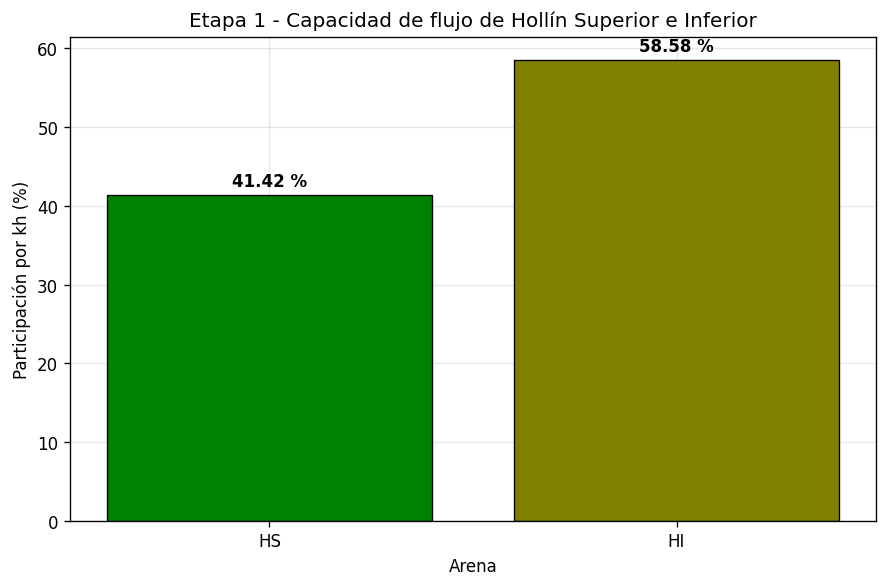


ETAPA 2. COMPORTAMIENTO PRODUCTIVO: PRODUCCIÓN Y BSW

ETAPA 2 - RESUMEN PRODUCTIVO DE LOS POZOS
    Pozo                          Arenas Fecha_inicial Fecha_final  qL_promedio_BFPD  qO_promedio_BPPD  qW_promedio_BAPD  qO_maximo_BPPD  BSW_global_pct  qL_final_BFPD  qO_final_BPPD
LGAC-053 HS + HI (producción commingled)    01/05/2026  20/06/2026           968.487           569.786           398.577         713.286          41.155        735.000        434.000
LGAC-057 HS + HI (producción commingled)    23/04/2026  17/07/2026           613.147           441.618           171.529         672.568          27.975        417.744        342.550
LGAC-056                              HS    17/05/2026  02/08/2026           424.324           357.447            66.877         504.196          15.761        530.733        504.196
LGAC-011                              HS    15/01/2026  02/07/2026           139.667            97.466            42.201         117.662          30.216         94.050    

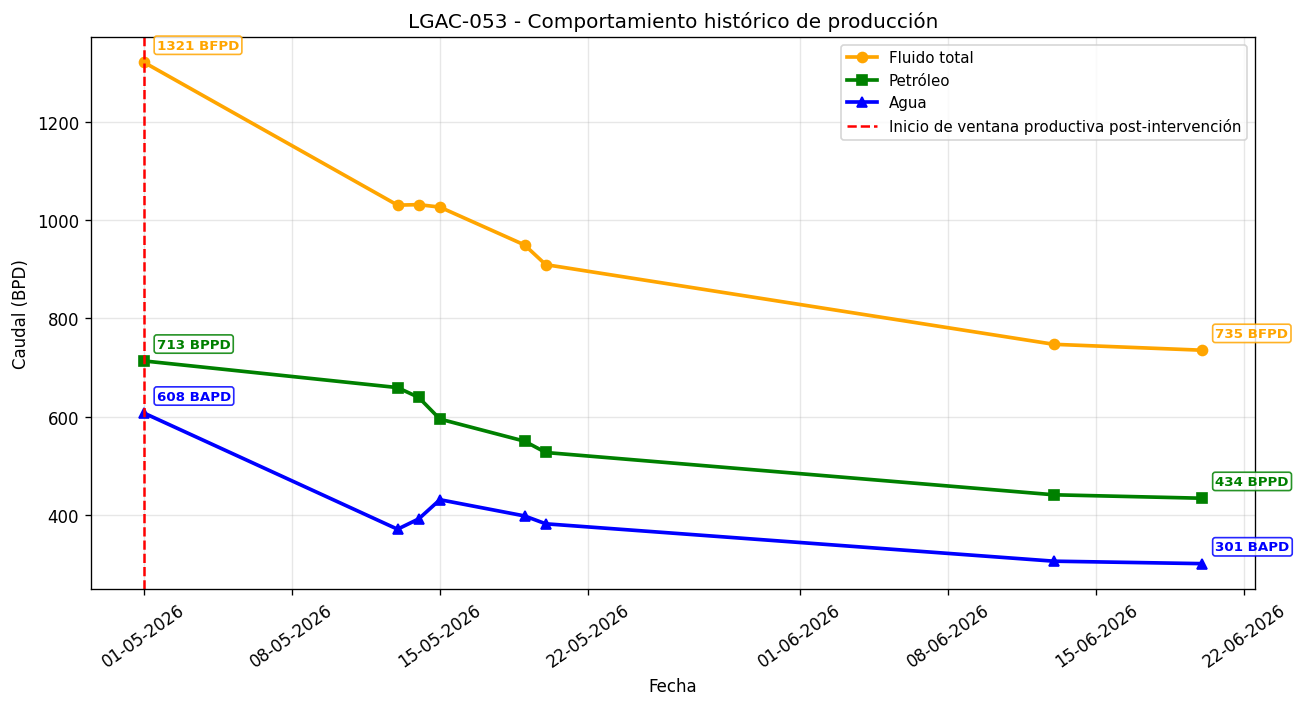

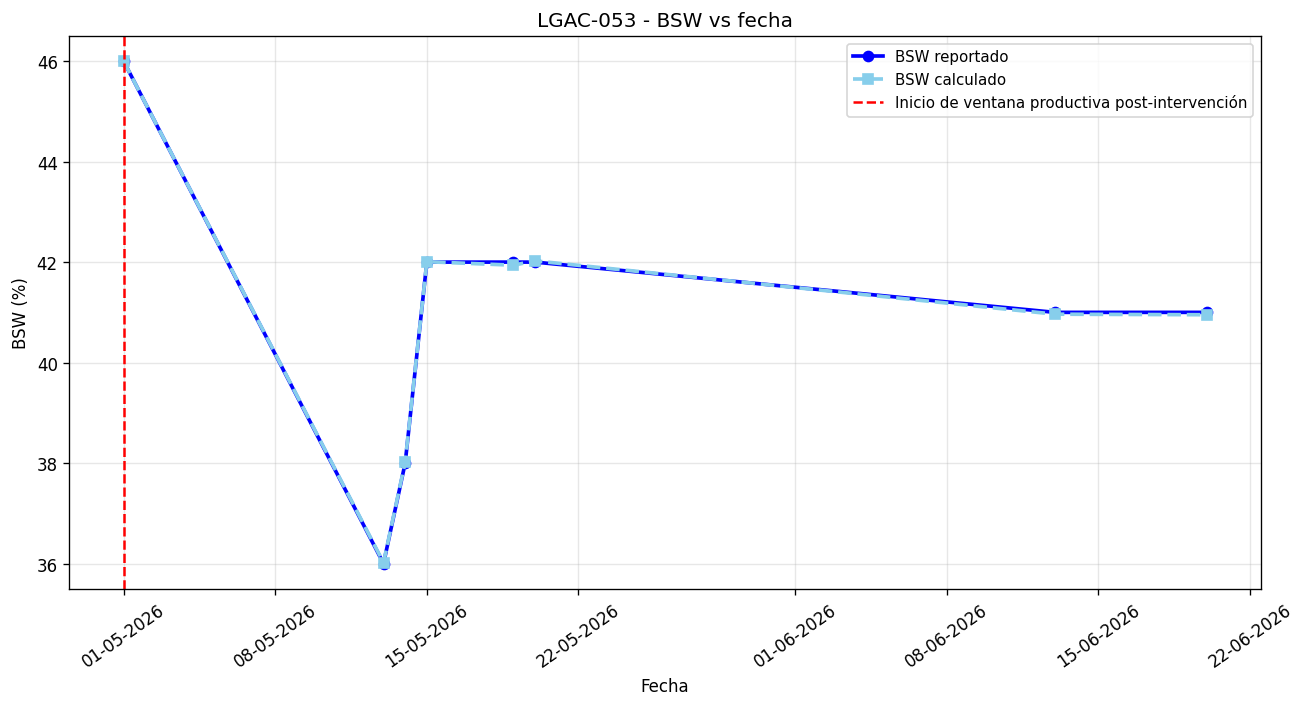

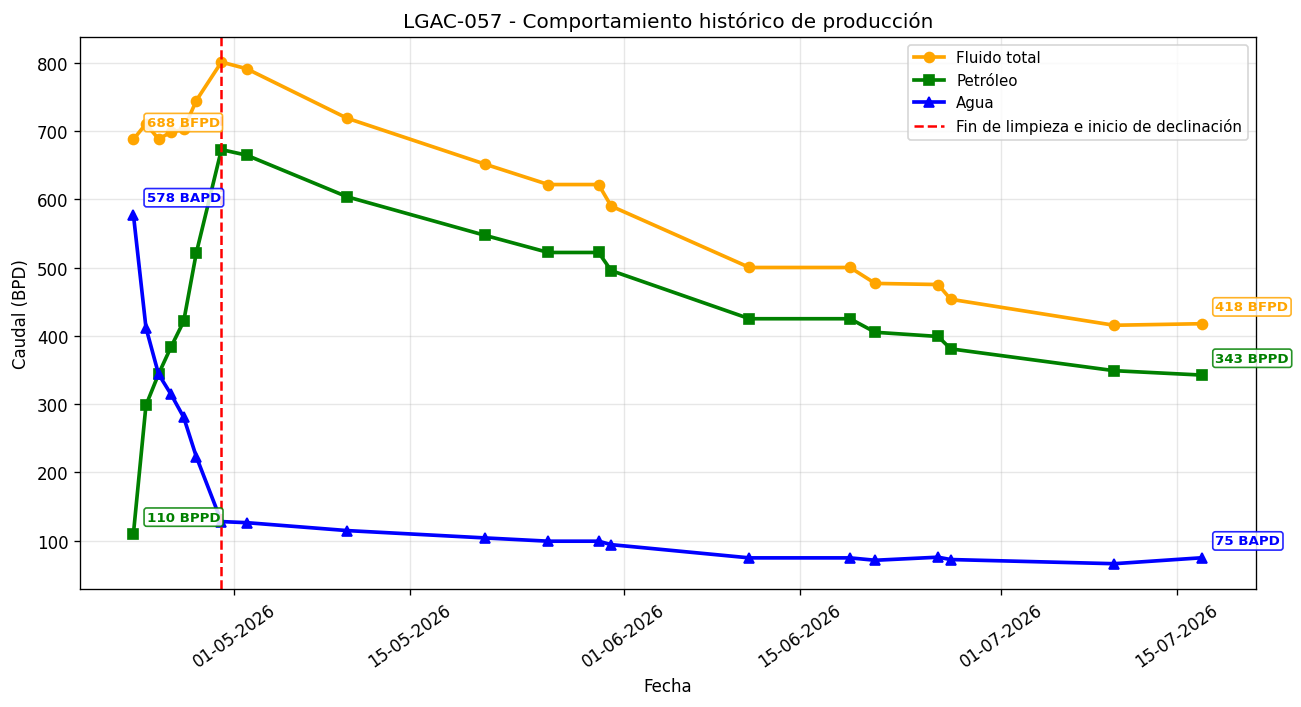

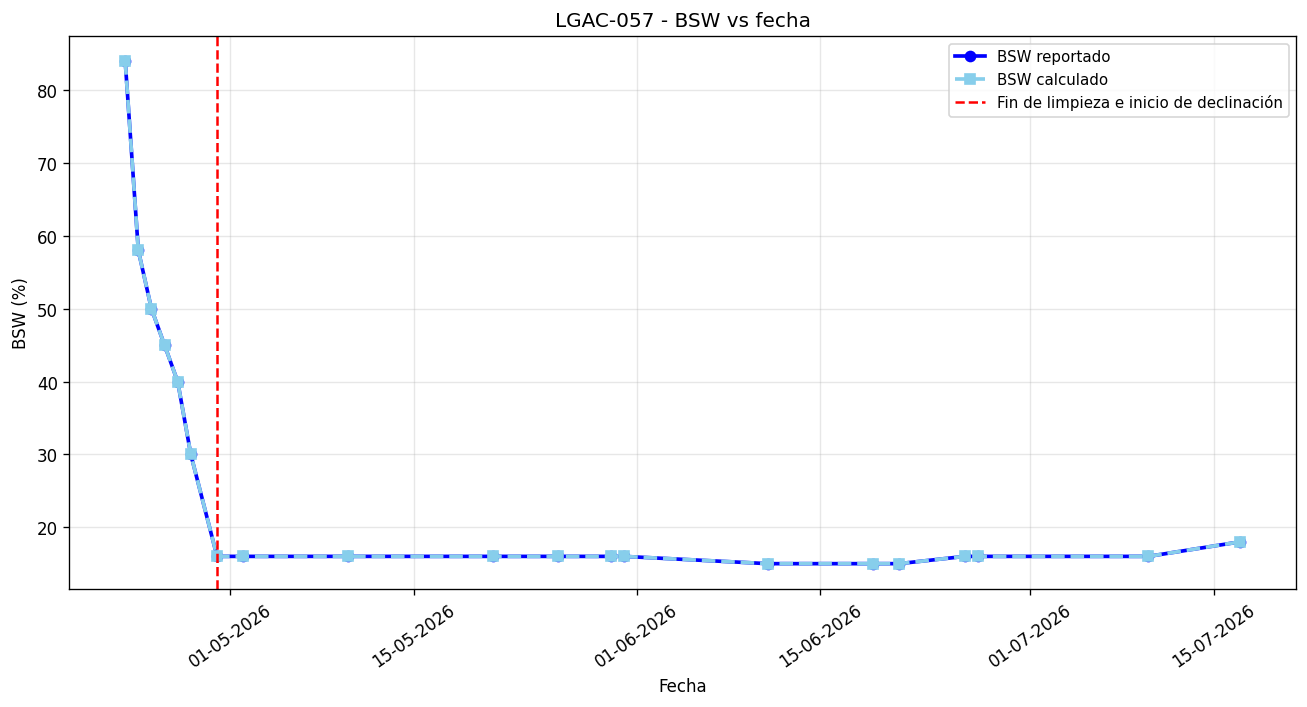


ETAPA 3. PERMEABILIDADES RELATIVAS, FLUJO FRACCIONAL Y ANÁLISIS NODAL

ETAPA 3.1A - PARÁMETROS / RESULTADOS COREY BASE POR ARENA
Escenario Arena  Sw_Simandoux  Swc_Corey     Swe     krw     kro         Tw        To  fw_en_Sw_Simandoux_pct
     Base    HS       0.66422    0.15000 0.93494 0.24518 0.00381 1596.99777   4.22599                99.73608
     Base    HI       0.23233    0.19000 0.08300 0.00017 0.75680    1.74276 913.10796                 0.19050


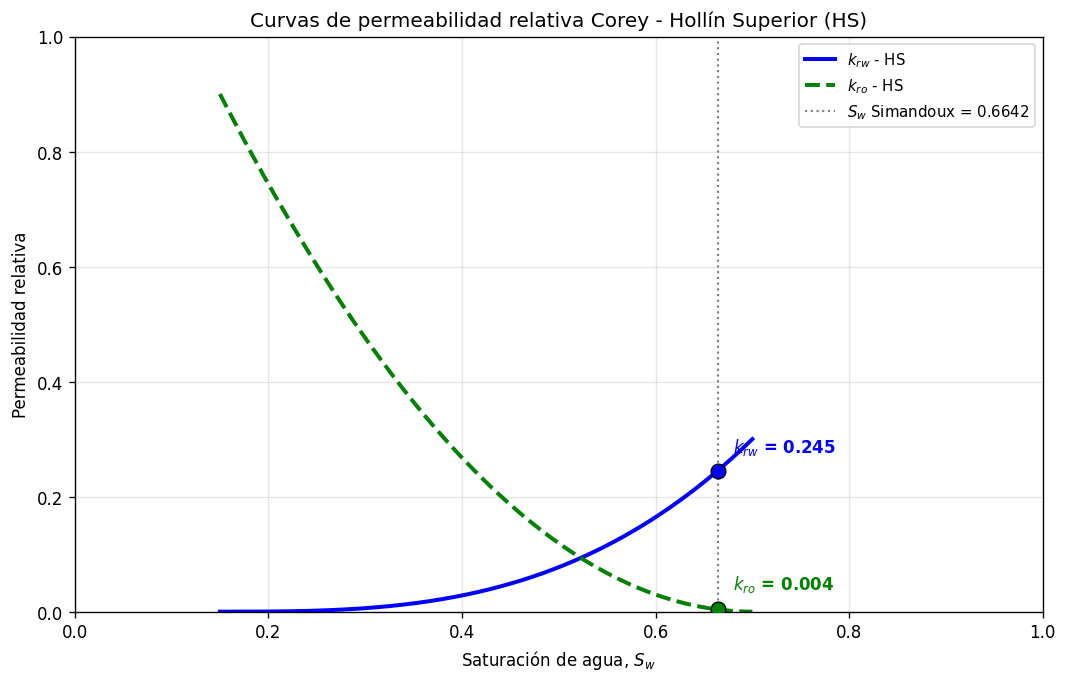

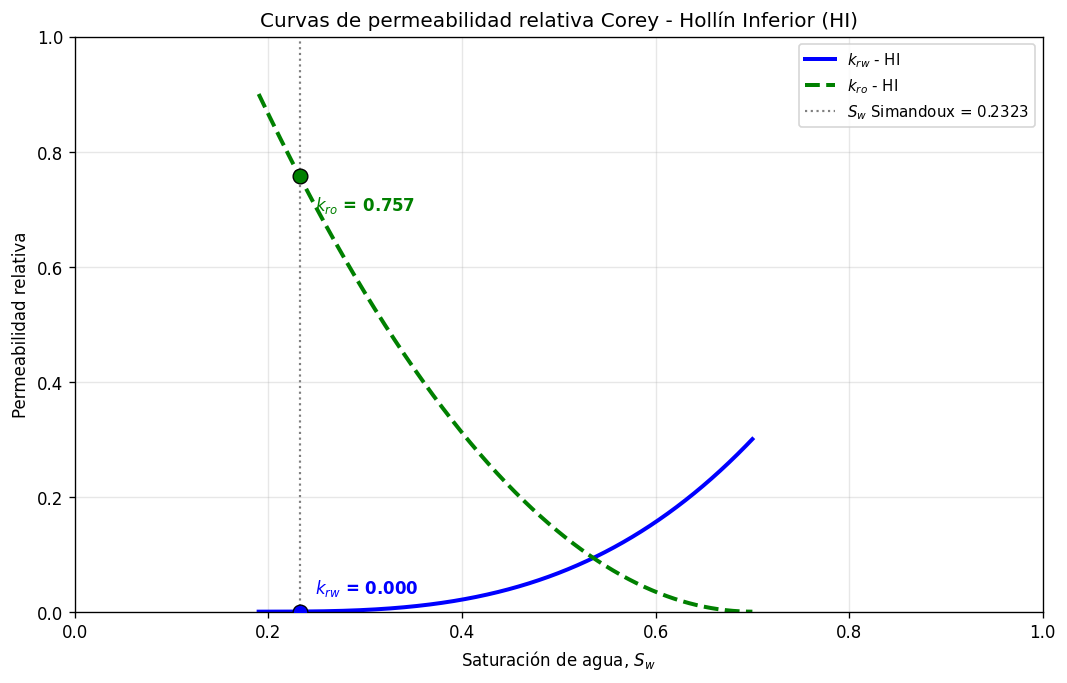


ETAPA 3.1B - FLUJO FRACCIONAL BUCKLEY-LEVERETT POR ARENA
Arena  Sw_Simandoux_actual  Swc_Corey  Swi_Buckley  fw_Swi_pct  Swf_Buckley  fw_Swf_pct  Sw_promedio_detras_frente  BSW_calculado_desde_fw_pct  BSW_adoptado_nodal_pct                                           Criterio_BSW
   HS               0.6642     0.1500       0.1500      0.0000       0.5269     86.4005                     0.5862                     86.4005                 86.4005   fw(Swf): condición de frente / fuerte avance de agua
   HI               0.2323     0.1900       0.3000      4.3781       0.4784     72.8714                     0.5490                      4.3781                  5.0000 fw(Swi=0.30), adoptado como 5 % para el análisis nodal


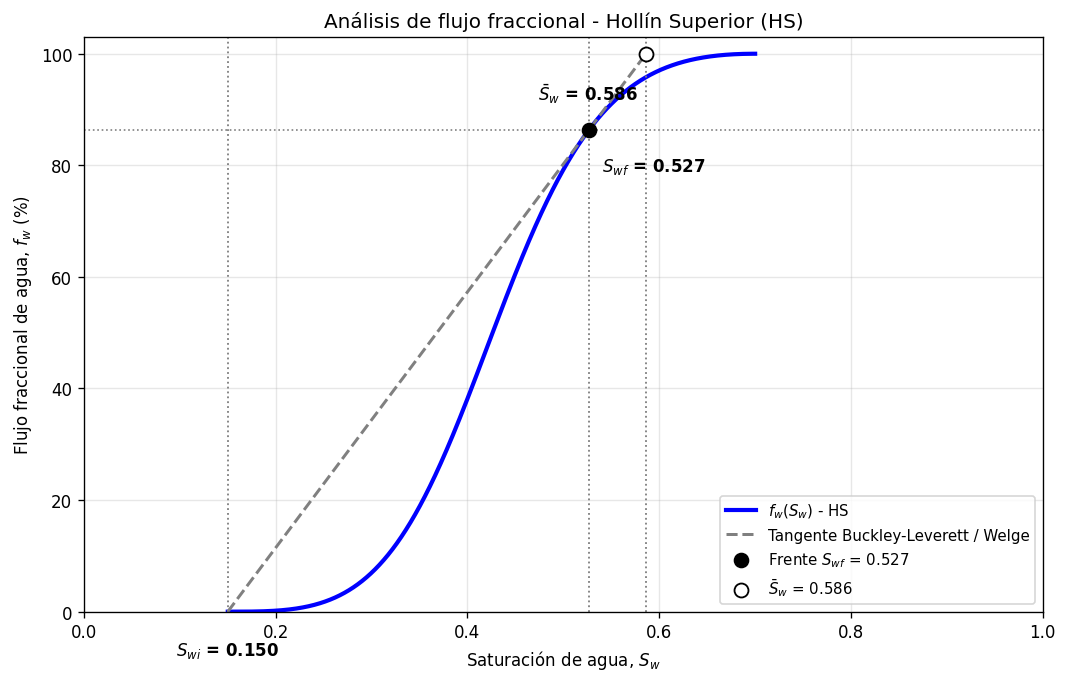

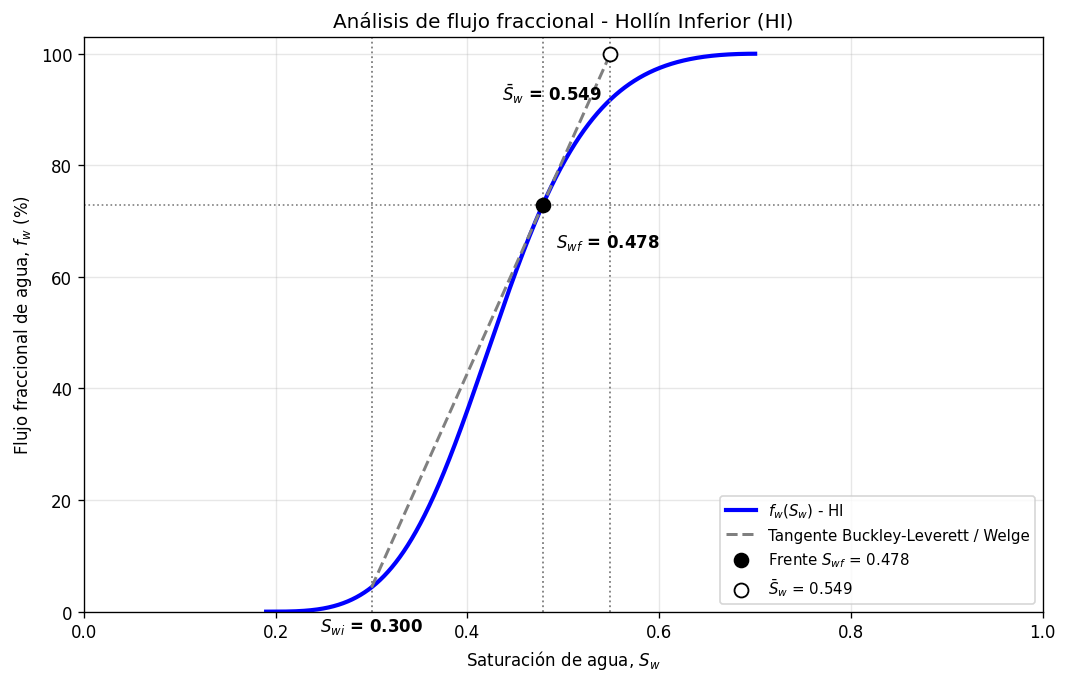


ETAPA 3.1C - ESTIMACIÓN PRE-NODAL DESDE 735 BFPD
Arena  kh_mD_ft  Participacion_kh_pct  BSW_adoptado_pct  qL_pre_nodal_BFPD  qO_pre_nodal_BOPD  qW_pre_nodal_BWPD                 Tipo_resultado
   HS  2432.000                41.417            86.401            304.414             41.399            263.015 Estimación por kh + fw; no PLT
   HI  3440.000                58.583             5.000            430.586            409.057             21.529 Estimación por kh + fw; no PLT

ETAPA 3.2A - NODAL HS EN CONDICIÓN ACTUAL FRACTURADA (S=-4.5)
Arena       Caso  Skin_referencia  qL_operacion_BFPD  qO_operacion_BOPD  qW_operacion_BWPD  BSW_adoptado  Pintake_operacion_psi
   HS Fracturado           -4.500            578.015             78.607            499.408        86.401                804.310


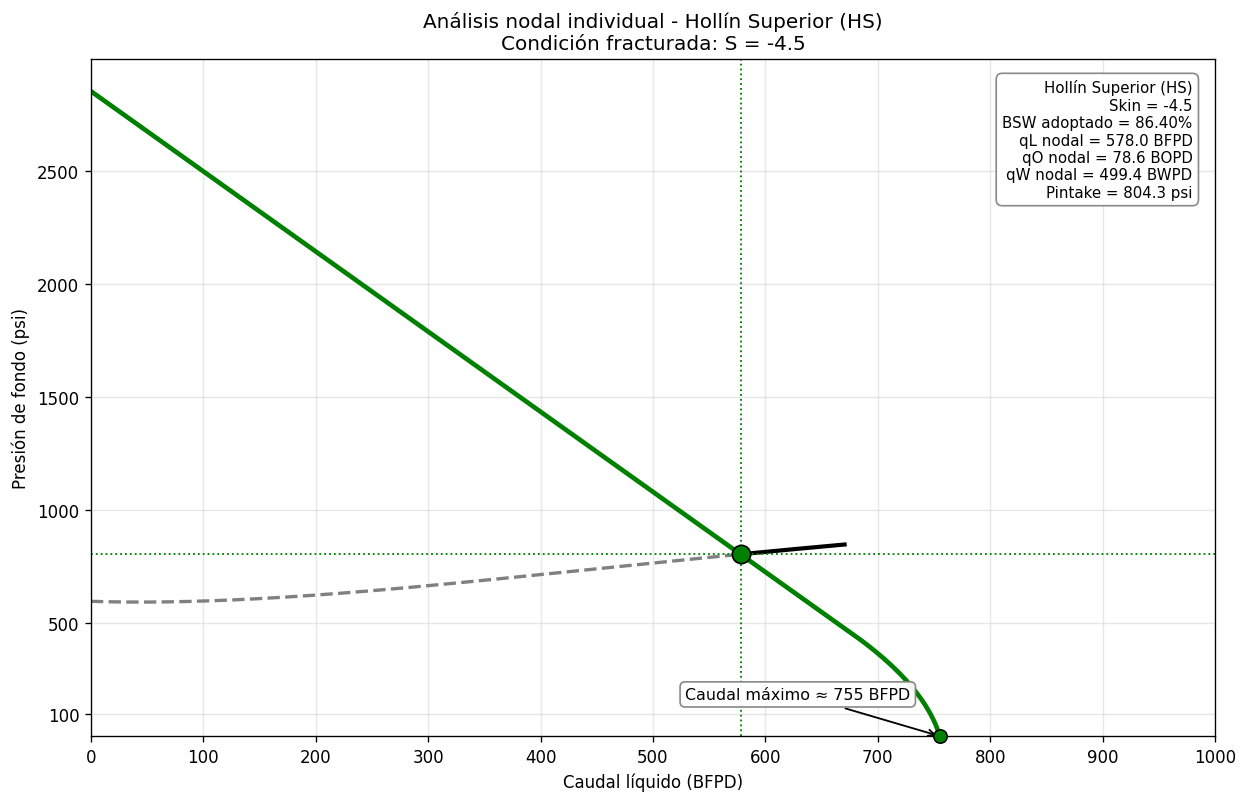


ETAPA 4. EVALUACIÓN POST-MORTEM DEL FRACTURAMIENTO HIDRÁULICO EN HOLLÍN SUPERIOR

ETAPA 4.1 - NODAL HS CONTRAFACTUAL SIN BENEFICIO DE FRACTURA (S=0)
Arena                      Caso  Skin  qL_operacion_BFPD  qO_operacion_BOPD  qW_operacion_BWPD  BSW_adoptado_pct  Pintake_operacion_psi
   HS Sin beneficio de fractura 0.000            214.604             29.185            185.419            86.401                629.159


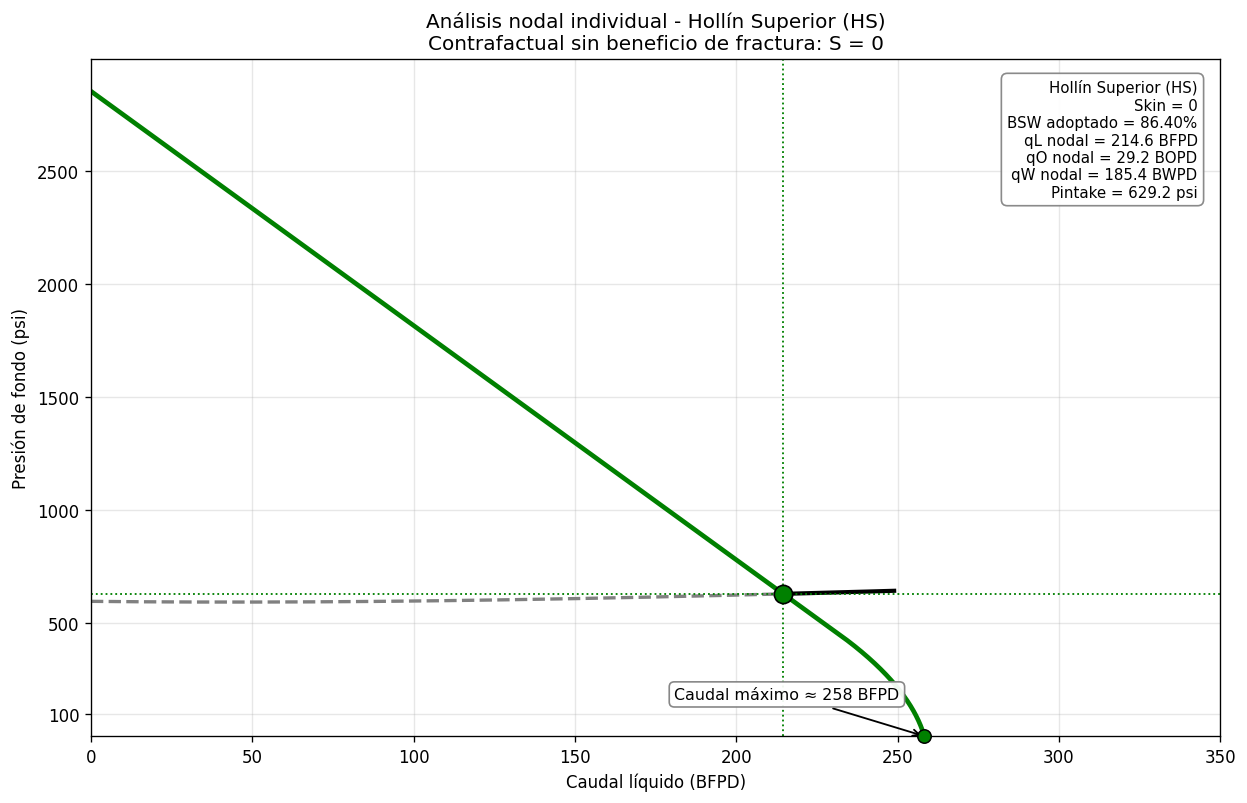

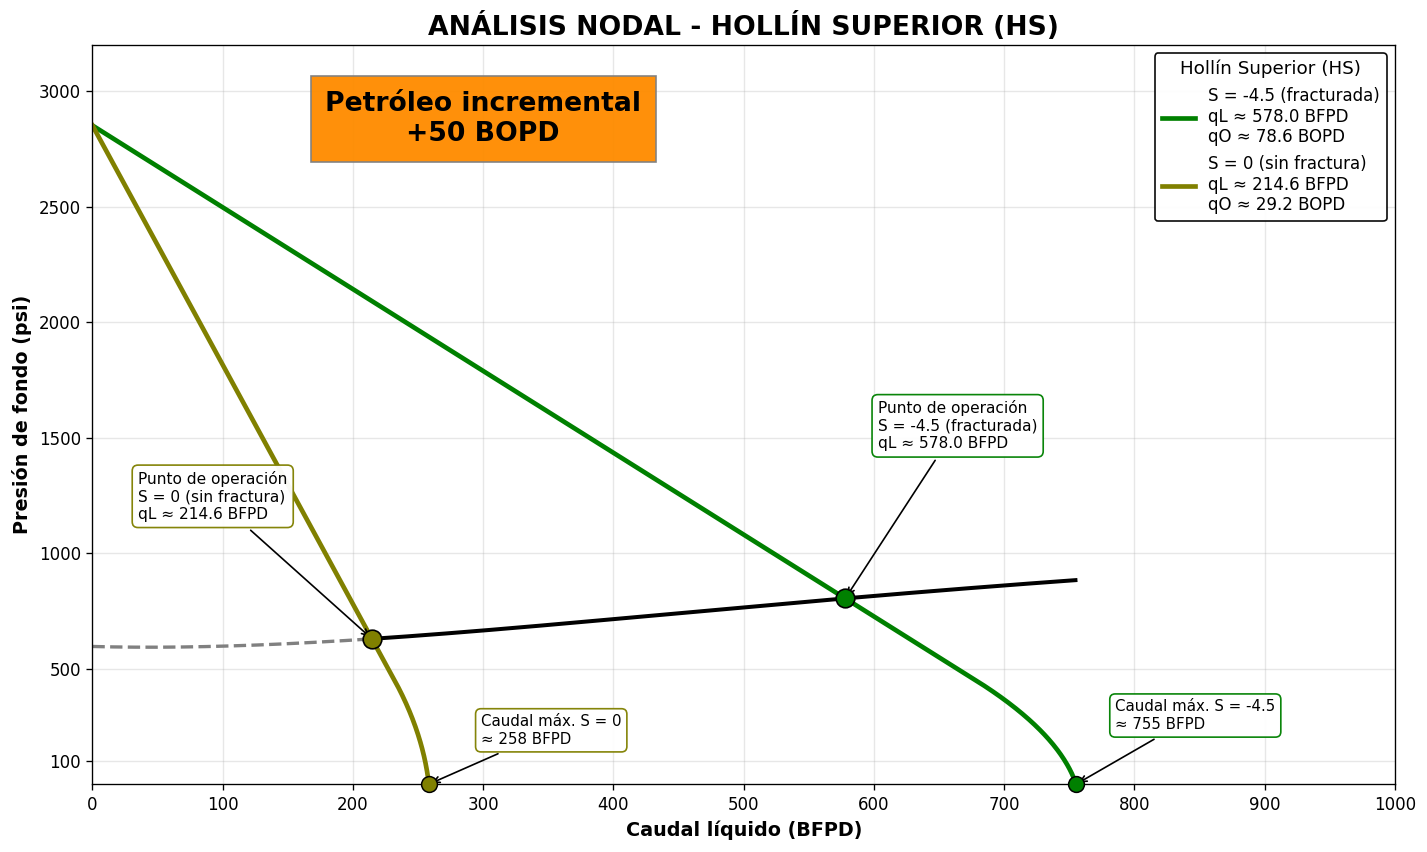


ETAPA 4.1 - HS FRACTURADO VS CONTRAFACTUAL SIN BENEFICIO DE FRACTURA
 Skin_HS                                     Descripcion  qL_BFPD  qO_BOPD  qW_BWPD  BSW_pct  Pintake_psi  Pwf_HS_psi  Delta_qO_vs_skin0_BOPD  Incremento_qO_vs_skin0_pct  Dentro_rango_BES_recomendado
 -4.5000 LGAC-053 HS fracturado; condición de referencia 578.0149  78.6071 499.4079  86.4005     804.3100    862.8440                 49.4220                    169.3401                          True
  0.0000         Contrafactual sin beneficio de fractura 214.6041  29.1851 185.4191  86.4005     629.1590    687.6930                  0.0000                      0.0000                         False


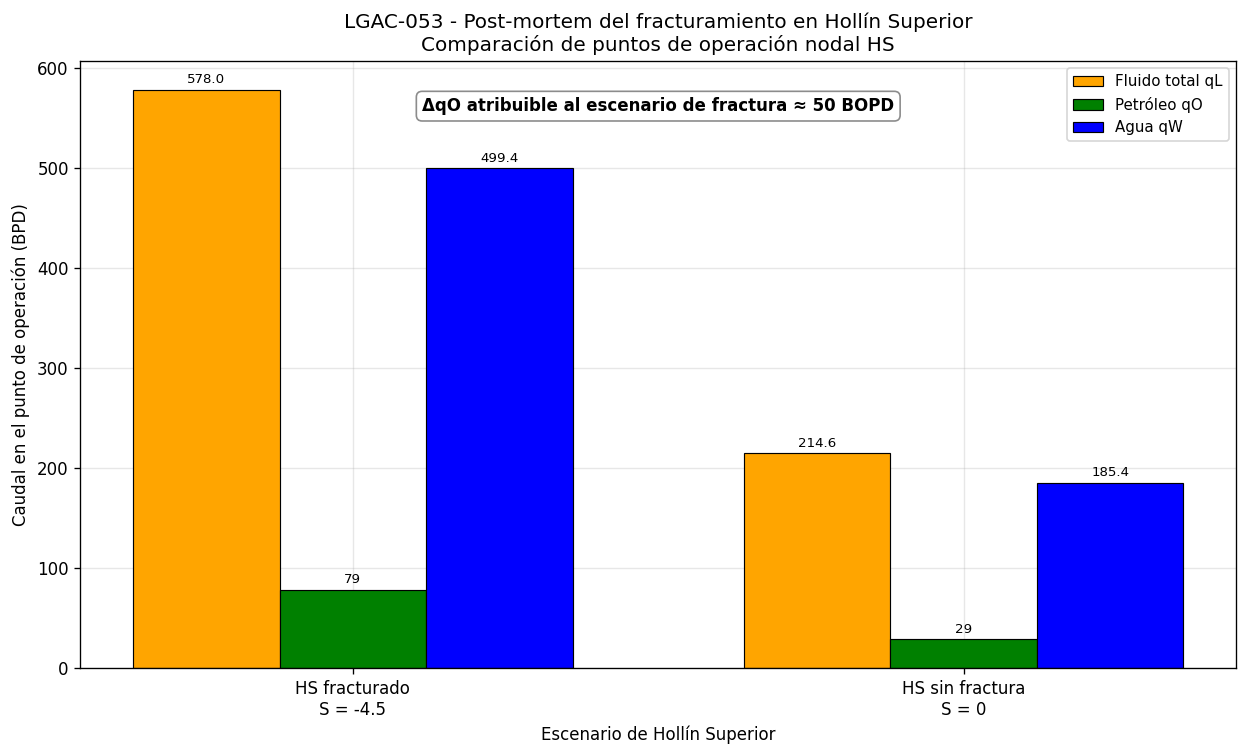


ETAPA 4.2 - COMPARACIÓN DE HOLLÍN SUPERIOR: LGAC-053 VS LGAC-056
    Pozo                                     Rol Fecha_referencia Fecha_final  Dias_analizados  qL_referencia_BFPD  qO_referencia_BOPD  qW_referencia_BWPD  qL_final_BFPD  qO_final_BOPD  qW_final_BWPD  Cambio_qL_periodo_pct  Cambio_qO_periodo_pct  Cambio_qW_periodo_pct  BSW_referencia_pct  BSW_final_pct
LGAC-056 Referencia principal de Hollín Superior       05/06/2026  23/07/2026           48.000             513.950             488.253              25.697        504.133        478.926         25.207                 -1.910                 -1.910                 -1.907               5.000          5.000

ETAPA 4.2 - SERIES HS PARA COMPARACIÓN CON TIEMPO NORMALIZADO
       Pozo      Fecha  Dia_desde_referencia  qL_HS_BFPD  qO_HS_BOPD  qW_HS_BWPD                                                                 Tipo_dato
LGAC-053 HS 2026-05-15                     0     461.700     269.494     192.206 Estimado: qL total × 0.45; 

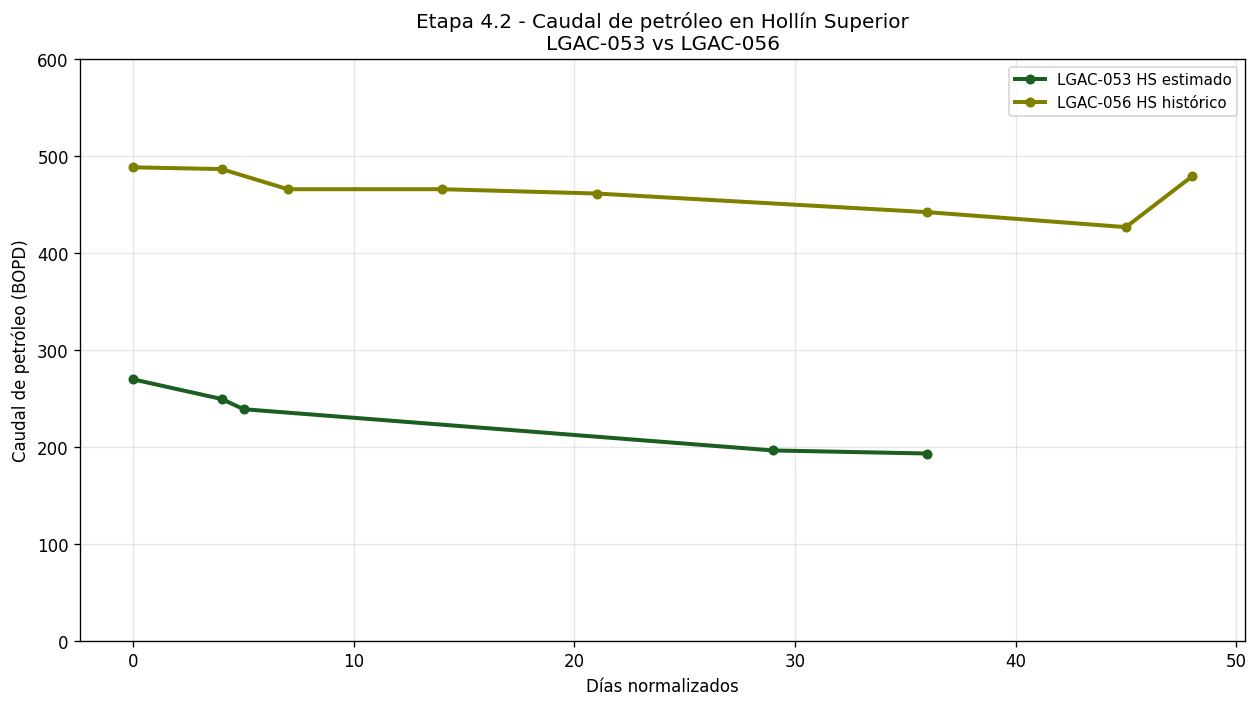

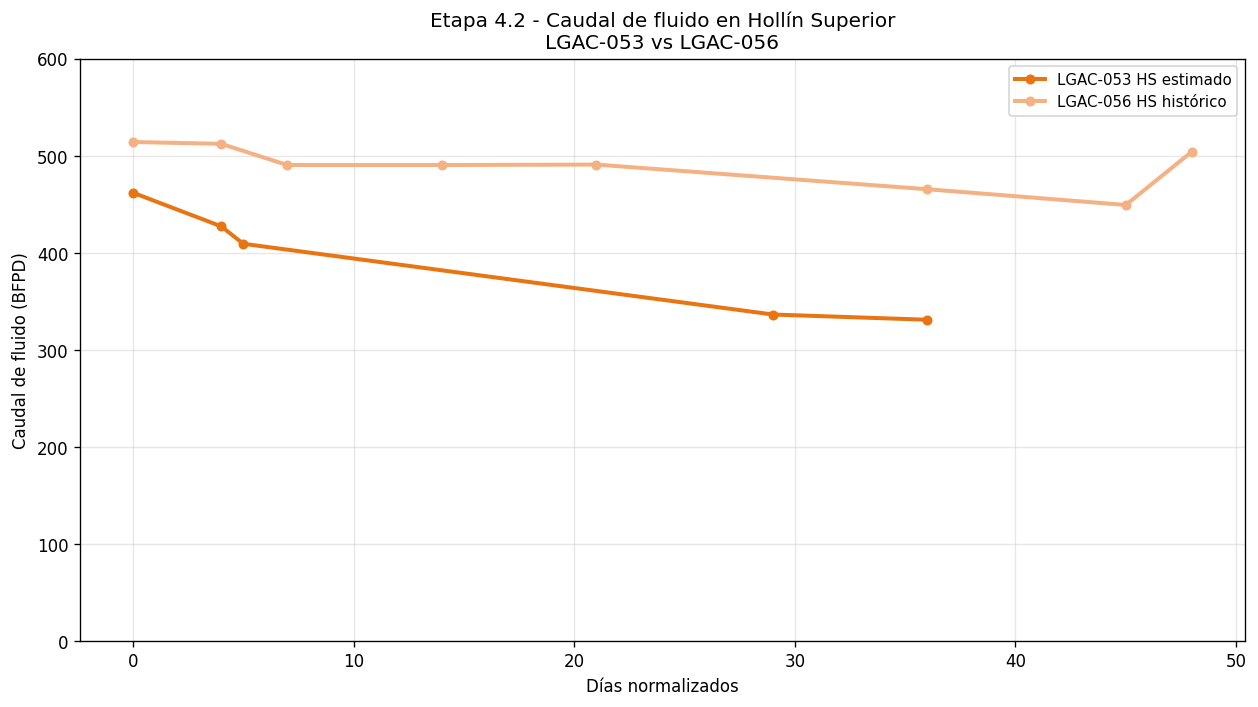


ETAPA 5. EVALUACIÓN TÉCNICO-ECONÓMICA DEL FRACTURAMIENTO Y PROPUESTA

ETAPA 5.1 - INDICADORES ECONÓMICOS INCREMENTALES DE LA FRACTURA HS
 qO_HS_skin0_BOPD  qO_HS_fracturado_BOPD  Delta_qO_frac_BOPD  Q_economico_redondeado_BOPD  Declinacion_referencia_anual_pct  Declinacion_mensual_pct  Horizonte_meses  Precio_USD_bbl  OPEX_USD_bbl  CAPEX_fractura_USD     VAN_USD  TIR_pct   B_C  Payback_meses
           29.185                 78.607              49.422                       50.000                            16.000                    1.330               18          70.000        12.000          300000.000 1187162.514   33.736 4.957          3.929


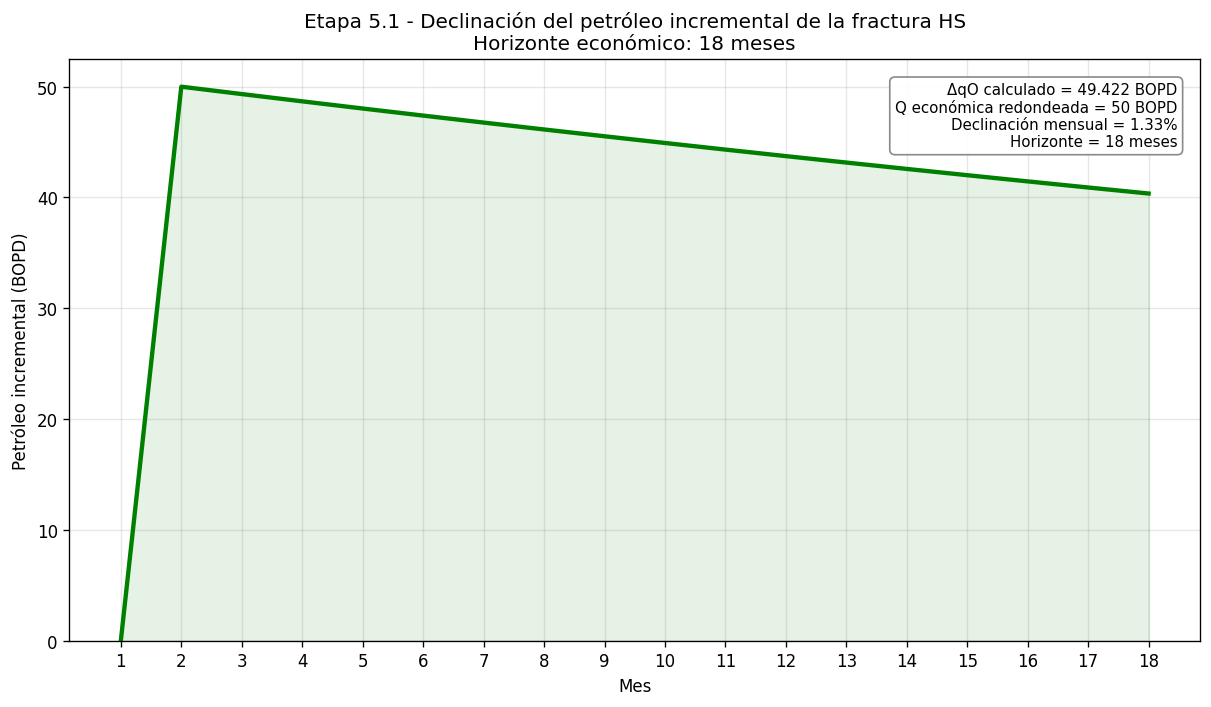

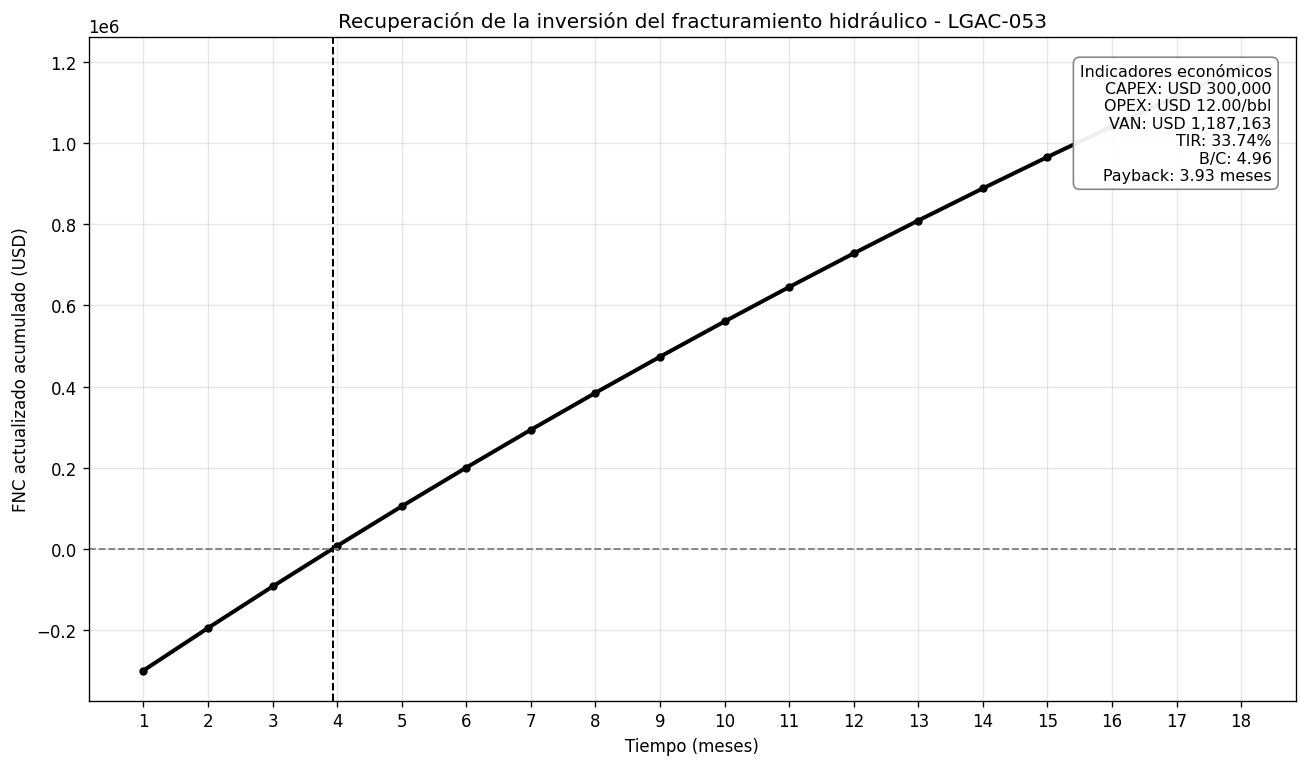


ETAPA 5.1 - INDICADORES FINALES DE RENTABILIDAD DE LA FRACTURA HS
 CAPEX_fractura_USD     VAN_USD  TIR_pct   B_C  Payback_meses
         300000.000 1187162.514   33.736 4.957          3.929

ETAPA 5.2 - RECOMENDACIÓN OPERATIVA
La BES simple se encuentra por encima de HS e HI y restringe el acceso del PLT hacia los intervalos productores.
Recomendación: ejecutar un PLT multifásico mediante e-line durante el próximo reacondicionamiento que requiera retirar la sarta BES.
Objetivos: cuantificar el aporte de HS e HI, identificar el origen del agua y verificar posible crossflow interzonal.
Intervención selectiva: considerar únicamente después del diagnóstico PLT.
Costo incremental conceptual del PLT durante workover programado: USD 40,000 (rango USD 25,000-50,000).
Retiro/reinstalación de BES exclusivamente para PLT: USD 160,000 (rango USD 120,000-200,000); no es la alternativa preferida.
Los costos corresponden a una estimación conceptual de planificación y deben validarse con cotizaciones

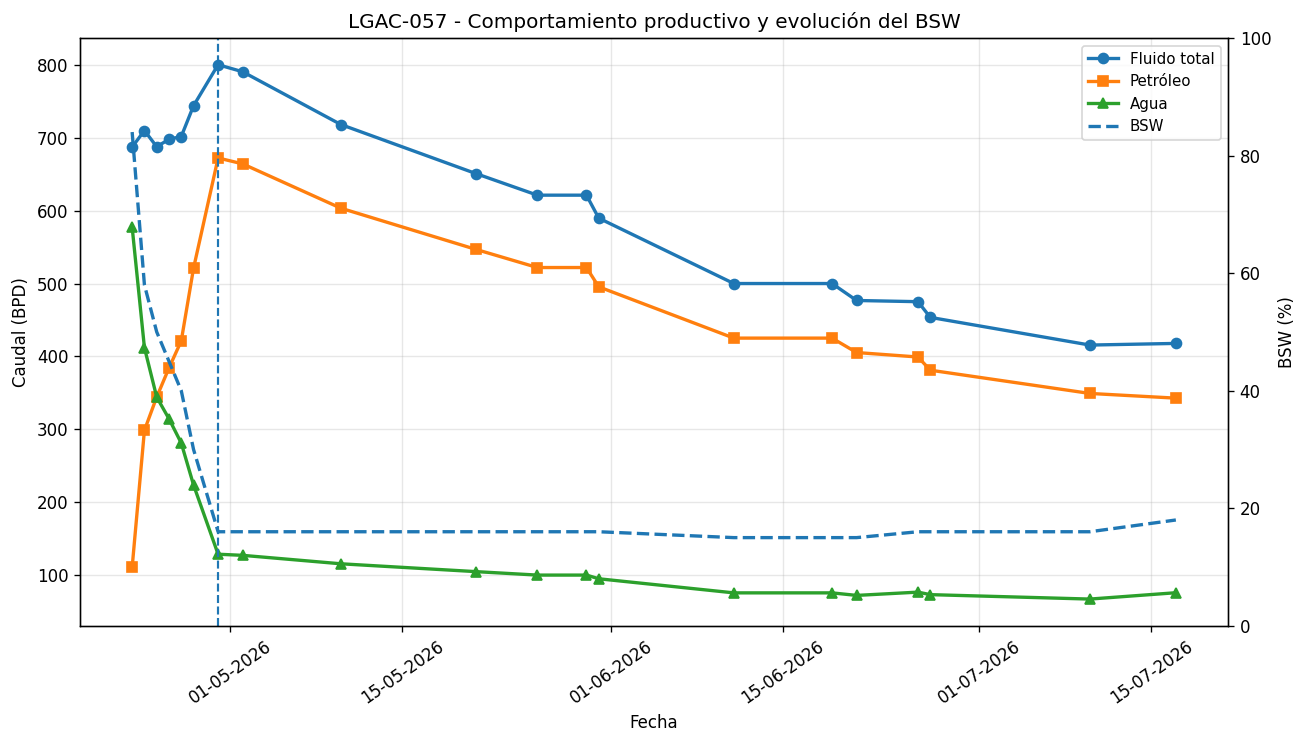


RESUMEN FINAL LGAC-053
Etapa                           Resultado       Valor Unidad
    1             Participación por kh HS      41.417      %
    1             Participación por kh HI      58.583      %
    2             Petróleo final LGAC-053     434.000   BOPD
    3        Petróleo nodal HS fracturado      78.607   BOPD
    4       Petróleo HS contrafactual S=0      29.185   BOPD
    4 Incremento atribuible a la fractura      49.422   BOPD
    5                                 VAN 1187162.514    USD
    5                                 TIR      33.736      %
    5                                 B/C       4.957      -
    5                             Payback       3.929  meses

Ejecución finalizada: 17 figuras generadas.
Resultados: /content/resultados_LGAC053


In [18]:
# ETAPA 5. EVALUACIÓN TÉCNICO-ECONÓMICA DEL FRACTURAMIENTO
# =============================================================================

CAPEX_FRACTURA_HS_USD = 300_000.0
HORIZONTE_FRACTURA_MESES = 18
Q_ECONOMICO_FRACTURA_BOPD = 50.0
PRECIO_CRUDO_FRACTURA_USD_BBL = 70.00
OPEX_PETROLEO_FRACTURA_USD_BBL = 12.00
TASA_DESCUENTO_FRACTURA_MENSUAL = 0.01
DECLINACION_REFERENCIA_ANUAL = 0.16
DECLINACION_FRACTURA_MENSUAL = 0.0133

GASTOS_MENSUALES_FRACTURA_USD = {
    "renta": 0.0,
    "energia": 0.0,
    "mantenimiento": 0.0,
    "quimicos": 0.0,
}


def construir_flujo_incremental_fractura(
    q_economico_bopd: float = Q_ECONOMICO_FRACTURA_BOPD,
    declinacion_mensual: float = DECLINACION_FRACTURA_MENSUAL,
    horizonte_meses: int = HORIZONTE_FRACTURA_MESES,
) -> pd.DataFrame:
    """Proyecta la producción incremental de petróleo durante el horizonte económico."""
    if q_economico_bopd <= 0.0:
        raise ValueError("La producción incremental debe ser positiva.")
    if not 0.0 <= declinacion_mensual < 1.0:
        raise ValueError("La declinación mensual debe estar entre 0 y 1.")
    if horizonte_meses < 2:
        raise ValueError("El horizonte debe ser de al menos 2 meses.")

    n = int(horizonte_meses)
    meses = np.arange(1, n + 1, dtype=int)
    produccion_diaria = [0.0, float(q_economico_bopd)]
    for _ in range(2, n):
        produccion_diaria.append(produccion_diaria[-1] * (1.0 - declinacion_mensual))

    q_o = np.asarray(produccion_diaria, dtype=float)
    petroleo_mes = q_o * 30.4
    ingreso = petroleo_mes * PRECIO_CRUDO_FRACTURA_USD_BBL
    gasto_fijo_mensual = float(sum(GASTOS_MENSUALES_FRACTURA_USD.values()))
    costo_operativo = np.asarray(
        [0.0] + [
            OPEX_PETROLEO_FRACTURA_USD_BBL * q + gasto_fijo_mensual
            for q in q_o[1:]
        ],
        dtype=float,
    )

    return pd.DataFrame(
        {
            "Mes": meses,
            "Periodo": meses,
            "Delta_qO_BOPD": q_o,
            "Petroleo_incremental_bbl": petroleo_mes,
            "Ingreso_petroleo_USD": ingreso,
            "Costo_operativo_petroleo_USD": costo_operativo,
        }
    )


def construir_flujo_caja_fractura(
    flujo_operativo: pd.DataFrame,
    capex_usd: float = CAPEX_FRACTURA_HS_USD,
) -> tuple[pd.DataFrame, dict[str, float | str]]:
    """Calcula VAN, TIR, B/C y payback descontado para el fracturamiento de HS."""
    fc = flujo_operativo.copy().reset_index(drop=True)
    fc["CAPEX_USD"] = 0.0
    fc.loc[0, "CAPEX_USD"] = float(capex_usd)
    fc["Flujo_neto_USD"] = (
        fc["Ingreso_petroleo_USD"]
        - fc["Costo_operativo_petroleo_USD"]
        - fc["CAPEX_USD"]
    )

    flujos = fc["Flujo_neto_USD"].to_numpy(dtype=float)
    fc["Flujo_actualizado_neto_USD"] = np.asarray(
        [
            flujo if flujo <= 0.0 else flujo / ((1.0 + TASA_DESCUENTO_FRACTURA_MENSUAL) ** t)
            for t, flujo in enumerate(flujos)
        ],
        dtype=float,
    )
    fc["Flujo_neto_acumulado_USD"] = fc["Flujo_neto_USD"].cumsum()
    fc["Flujo_actualizado_acumulado_USD"] = fc["Flujo_actualizado_neto_USD"].cumsum()

    van = float(fc["Flujo_actualizado_neto_USD"].sum())
    tir = calcular_tir(flujos)
    tir_pct = 100.0 * tir if np.isfinite(tir) else np.nan
    inversion_inicial = abs(float(flujos[0]))
    beneficios_actualizados = float(
        sum(
            flujo / ((1.0 + TASA_DESCUENTO_FRACTURA_MENSUAL) ** t)
            for t, flujo in enumerate(flujos[1:], start=1)
        )
    )
    bc = beneficios_actualizados / inversion_inicial if inversion_inicial > 0.0 else np.nan

    acumulado = fc["Flujo_actualizado_acumulado_USD"].to_numpy(dtype=float)
    tiempo = fc["Mes"].to_numpy(dtype=float)
    payback = np.nan
    for idx in range(len(acumulado) - 1):
        if acumulado[idx] <= 0.0 < acumulado[idx + 1]:
            x1, x2 = tiempo[idx], tiempo[idx + 1]
            y1, y2 = acumulado[idx], acumulado[idx + 1]
            payback = float(x1 - y1 * (x2 - x1) / (y2 - y1)) if y2 != y1 else float(x2)
            break

    metricas = {
        "CAPEX_USD": float(capex_usd),
        "VAN_USD": van,
        "TIR_pct": float(tir_pct) if np.isfinite(tir_pct) else np.nan,
        "B_C": float(bc) if np.isfinite(bc) else np.nan,
        "Payback_descontado_meses": float(payback) if np.isfinite(payback) else np.nan,
    }
    return fc, metricas


def ejecutar_economia_fractura(
    evaluacion_fractura: pd.DataFrame,
) -> pd.DataFrame:
    """Evalúa el beneficio incremental de la fractura de Hollín Superior durante 18 meses."""
    base = evaluacion_fractura.loc[
        np.isclose(evaluacion_fractura["Skin_HS"].astype(float), 0.0)
    ].iloc[0]
    frac = evaluacion_fractura.loc[
        np.isclose(evaluacion_fractura["Skin_HS"].astype(float), SKIN_HS_REFERENCIA)
    ].iloc[0]

    delta_qo = float(frac["qO_BOPD"] - base["qO_BOPD"])
    delta_qw = float(frac["qW_BWPD"] - base["qW_BWPD"])
    delta_ql = float(frac["qL_BFPD"] - base["qL_BFPD"])
    if delta_qo <= 0.0:
        raise RuntimeError("El caso fracturado no genera petróleo incremental positivo frente a S=0.")

    q_economico = Q_ECONOMICO_FRACTURA_BOPD
    flujo = construir_flujo_incremental_fractura(q_economico_bopd=q_economico)
    flujo.to_csv(CARPETAS[5] / "flujo_incremental_fractura_HS_18m.csv", index=False)

    flujo_caja, metricas = construir_flujo_caja_fractura(flujo)
    flujo_caja.to_csv(CARPETAS[5] / "flujo_caja_incremental_fractura_HS_18m.csv", index=False)

    petroleo_18m = float(flujo["Petroleo_incremental_bbl"].sum())
    estado = "RENTABLE" if metricas["VAN_USD"] > 0.0 and metricas["B_C"] > 1.0 else "NO RENTABLE"

    df = pd.DataFrame(
        [
            {
                "qO_HS_skin0_BOPD": float(base["qO_BOPD"]),
                "qO_HS_fracturado_BOPD": float(frac["qO_BOPD"]),
                "Delta_qL_frac_BFPD": delta_ql,
                "Delta_qO_frac_BOPD": delta_qo,
                "Delta_qW_frac_BWPD": delta_qw,
                "Q_economico_redondeado_BOPD": q_economico,
                "Declinacion_referencia_anual_pct": 100.0 * DECLINACION_REFERENCIA_ANUAL,
                "Declinacion_mensual_pct": 100.0 * DECLINACION_FRACTURA_MENSUAL,
                "Horizonte_meses": HORIZONTE_FRACTURA_MESES,
                "Petroleo_incremental_18m_bbl": petroleo_18m,
                "Precio_USD_bbl": PRECIO_CRUDO_FRACTURA_USD_BBL,
                "OPEX_USD_bbl": OPEX_PETROLEO_FRACTURA_USD_BBL,
                "Tasa_descuento_mensual_pct": 100.0 * TASA_DESCUENTO_FRACTURA_MENSUAL,
                "CAPEX_fractura_USD": CAPEX_FRACTURA_HS_USD,
                "VAN_USD": metricas["VAN_USD"],
                "TIR_pct": metricas["TIR_pct"],
                "B_C": metricas["B_C"],
                "Payback_meses": metricas["Payback_descontado_meses"],
                "Resultado": estado,
            }
        ]
    )
    df.to_csv(CARPETAS[5] / "indicadores_economicos_fractura_HS.csv", index=False)
    return df


def generar_tablas_y_graficas_por_etapa(
    df_petrofisica: pd.DataFrame,
    historiales: dict[str, pd.DataFrame],
    resumen_pozos: pd.DataFrame,
    arenas: dict[str, dict],
    tabla_kh: pd.DataFrame,
    df_corey: pd.DataFrame,
    tabla_bl: pd.DataFrame,
    tabla_pre_nodal: pd.DataFrame,
    nodal_por_arena: pd.DataFrame,
    resultados_zonales: dict[str, ResultadoNodal],
    resultados_skin_hs: dict[float, ResultadoNodal],
    evaluacion_fractura: pd.DataFrame,
    benchmark: pd.DataFrame,
    economia_fractura: pd.DataFrame,
) -> None:


    # =========================================================================
    # CONFIGURACIÓN VISUAL GENERAL
    # =========================================================================

    COLOR_FLUIDO = "orange"
    COLOR_PETROLEO = "green"
    COLOR_AGUA = "blue"

    # Colores para diferenciar arenas cuando no se representan fases
    COLOR_HS = "green"
    COLOR_HI = "olive"

    COLOR_REFERENCIA = "gray"
    COLOR_EVENTO = "red"
    COLOR_CALIBRACION = "black"
    COLOR_ECONOMICO = "black"

    ALPHA_CUADRICULA = 0.30
    ANCHO_LINEA = 2.2


    def aplicar_estilo(
        ax,
        titulo: str,
        etiqueta_x: str,
        etiqueta_y: str,
        leyenda: bool = True,
    ) -> None:
        """Aplica el formato general a las figuras."""
        ax.set_title(titulo)
        ax.set_xlabel(etiqueta_x)
        ax.set_ylabel(etiqueta_y)
        ax.grid(alpha=ALPHA_CUADRICULA)
        ax.set_axisbelow(True)

        if leyenda:
            ax.legend()


    def encabezado_etapa(numero: str, titulo: str) -> None:
        """Imprime el encabezado de cada etapa."""
        print("\n" + "=" * 108)
        print(f"ETAPA {numero}. {titulo}")
        print("=" * 108)


    def columnas_disponibles(
        df: pd.DataFrame,
        columnas: list[str],
    ) -> list[str]:
        """Devuelve únicamente las columnas disponibles en el DataFrame."""
        return [
            col
            for col in columnas
            if col in df.columns
        ]


    def mostrar_tabla_ordenada(
        titulo: str,
        df: pd.DataFrame,
        columnas: list[str] | None = None,
        decimales: int = 3,
    ) -> None:
        """Muestra una tabla utilizando únicamente las columnas solicitadas."""
        if df is None or df.empty:
            print(f"\n{titulo}: sin datos disponibles.")
            return

        vista = df.copy()

        if columnas is not None:
            cols = columnas_disponibles(
                vista,
                columnas,
            )

            if cols:
                vista = vista[cols]

        mostrar_tabla(
            titulo,
            vista,
            decimales=decimales,
        )


    def mostrar_y_guardar_figura(
        fig,
        ruta: Path,
    ) -> None:
        """Guarda la figura y la muestra en Colab cuando está habilitado."""
        ruta.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.tight_layout()

        fig.savefig(
            ruta,
            dpi=300,
            bbox_inches="tight",
        )

        if MOSTRAR_GRAFICAS:
            try:
                from IPython.display import display
                display(fig)

            except ImportError:
                plt.show()

        plt.close(fig)

    # =========================================================================
    # ETAPA 1. CARACTERIZACIÓN PETROFÍSICA Y CAPACIDAD DE FLUJO
    # =========================================================================
    encabezado_etapa("1", "CARACTERIZACIÓN PETROFÍSICA Y CAPACIDAD DE FLUJO")

    tabla_petrofisica_mostrar = df_petrofisica.copy()
    if "Vsh" in tabla_petrofisica_mostrar.columns:
        tabla_petrofisica_mostrar["Vsh_pct"] = 100.0 * tabla_petrofisica_mostrar["Vsh"]
    if "Sw_Archie" in tabla_petrofisica_mostrar.columns:
        tabla_petrofisica_mostrar["Sw_Archie_pct"] = 100.0 * tabla_petrofisica_mostrar["Sw_Archie"]
    if "Sw_Simandoux" in tabla_petrofisica_mostrar.columns:
        tabla_petrofisica_mostrar["Sw_Simandoux_pct"] = 100.0 * tabla_petrofisica_mostrar["Sw_Simandoux"]
    if "Sh" in tabla_petrofisica_mostrar.columns:
        tabla_petrofisica_mostrar["Sh_pct"] = 100.0 * tabla_petrofisica_mostrar["Sh"]

    mostrar_tabla_ordenada(
        "ETAPA 1 - RESUMEN PETROFÍSICO HS / HI",
        tabla_petrofisica_mostrar,
        columnas=[
            "Arena", "Nombre", "phi_pct", "Vsh_pct",
            "Sw_Archie_pct", "Sw_Simandoux_pct", "Sh_pct",
            "POES_STB", "k_mD", "h_perforado_ft", "kh_mD_ft",
        ],
        decimales=4,
    )

    mostrar_tabla_ordenada(
        "ETAPA 1 - CAPACIDAD DE FLUJO POR ARENA",
        tabla_kh,
        columnas=[
            "Arena", "k_mD", "h_perforado_ft", "kh_mD_ft",
            "Participacion_kh_pct",
        ],
        decimales=3,
    )

    # -------------------------------------------------------------------------
    # Figura 1.1. Participación por capacidad de flujo
    # -------------------------------------------------------------------------
    colores_kh = [
        COLOR_HS if arena == "HS" else COLOR_HI
        for arena in tabla_kh["Arena"]
    ]
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    barras = ax.bar(
        tabla_kh["Arena"],
        tabla_kh["Participacion_kh_pct"],
        color=colores_kh,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.bar_label(barras, fmt="%.2f %%", padding=3, fontweight="bold")
    aplicar_estilo(
        ax,
        "Etapa 1 - Capacidad de flujo de Hollín Superior e Inferior",
        "Arena",
        "Participación por kh (%)",
        leyenda=False,
    )
    ax.grid(axis="y", alpha=ALPHA_CUADRICULA)
    mostrar_y_guardar_figura(fig, CARPETAS[1] / "participacion_por_kh.png")


    # =========================================================================
    # ETAPA 2. ANÁLISIS PRODUCTIVO
    # =========================================================================
    encabezado_etapa("2", "COMPORTAMIENTO PRODUCTIVO: PRODUCCIÓN Y BSW")

    mostrar_tabla_ordenada(
        "ETAPA 2 - RESUMEN PRODUCTIVO DE LOS POZOS",
        resumen_pozos,
        columnas=[
            "Pozo", "Arenas", "Fecha_inicial", "Fecha_final",
            "qL_promedio_BFPD", "qO_promedio_BPPD", "qW_promedio_BAPD",
            "qO_maximo_BPPD", "BSW_global_pct",
            "qL_final_BFPD", "qO_final_BPPD",
        ],
        decimales=3,
    )

    orden_pozos = ["LGAC-053", "LGAC-057"]
    for pozo in orden_pozos:
        if pozo not in historiales:
            print(f"Aviso Etapa 2: no se encontró historial para {pozo}.")
            continue

        prod = historiales[pozo].copy()
        configuracion = HISTORIALES[pozo]

        # Garantiza que TODOS los pozos, incluido LGAC-011, tengan BSW calculado.
        if "BSW_calculado_pct" not in prod.columns:
            denom = prod["BFPD"].replace(0.0, np.nan)
            prod["BSW_calculado_pct"] = 100.0 * prod["BAPD"] / denom

        carpeta = (
            CARPETAS[2]
            if pozo == "LGAC-053"
            else CARPETAS[2] / "pozos_vecinos" / pozo
        )
        carpeta.mkdir(parents=True, exist_ok=True)

        evento = configuracion.get("evento")
        fecha_evento = None

        # ---------------------------------------------------------------------
        # Figura 2.1. Historial de producción
        # ---------------------------------------------------------------------
        fig, ax = plt.subplots(figsize=(11, 6))

        series = (
            ("BFPD", "Fluido total", "o", COLOR_FLUIDO),
            ("BPPD", "Petróleo", "s", COLOR_PETROLEO),
            ("BAPD", "Agua", "^", COLOR_AGUA),
        )

        for columna, etiqueta, marcador, color in series:
            ax.plot(
                prod["Fecha"],
                prod[columna],
                color=color,
                marker=marcador,
                linewidth=ANCHO_LINEA,
                label=etiqueta,
            )

            etiquetar_extremos(
                ax,
                prod["Fecha"],
                prod[columna],
                columna,
                color,
            )

        if evento:
            fecha_evento = pd.to_datetime(
                evento[0],
                dayfirst=True,
            )
            ax.axvline(
                fecha_evento,
                color=COLOR_EVENTO,
                linestyle="--",
                linewidth=1.5,
                label=evento[1],
            )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%d-%m-%Y")
        )
        ax.tick_params(
            axis="x",
            rotation=35,
        )

        aplicar_estilo(
            ax,
            f"{pozo} - Comportamiento histórico de producción",
            "Fecha",
            "Caudal (BPD)",
        )

        mostrar_y_guardar_figura(
            fig,
            carpeta / f"{pozo}_historial_produccion.png",
        )

        # ---------------------------------------------------------------------
        # Figura 2.2. BSW reportado y calculado
        # ---------------------------------------------------------------------
        fig, ax = plt.subplots(figsize=(11, 6))

        ax.plot(
            prod["Fecha"],
            prod["BSW_reportado_pct"],
            color="blue",
            marker="o",
            linewidth=ANCHO_LINEA,
            label="BSW reportado",
        )

        ax.plot(
            prod["Fecha"],
            prod["BSW_calculado_pct"],
            color="skyblue",
            marker="s",
            linestyle="--",
            linewidth=ANCHO_LINEA,
            label="BSW calculado",
        )

        if fecha_evento is not None:
            ax.axvline(
                fecha_evento,
                color=COLOR_EVENTO,
                linestyle="--",
                linewidth=1.5,
                label=evento[1],
            )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%d-%m-%Y")
        )
        ax.tick_params(
            axis="x",
            rotation=35,
        )

        aplicar_estilo(
            ax,
            f"{pozo} - BSW vs fecha",
            "Fecha",
            "BSW (%)",
        )

        mostrar_y_guardar_figura(
            fig,
            carpeta / f"{pozo}_bsw_vs_fecha.png",
        )




    # ETAPA 3. PERMEABILIDADES RELATIVAS, FLUJO FRACCIONAL Y ANÁLISIS NODAL DE HS
    # =========================================================================
    encabezado_etapa("3", "PERMEABILIDADES RELATIVAS, FLUJO FRACCIONAL Y ANÁLISIS NODAL")

    # 3.1A. Permeabilidades relativas Corey: tabla base antes de sus curvas.
    corey_base = df_corey.loc[
        df_corey["Escenario"].astype(str).str.lower().eq("base")
    ].copy() if "Escenario" in df_corey.columns else df_corey.copy()
    mostrar_tabla_ordenada(
        "ETAPA 3.1A - PARÁMETROS / RESULTADOS COREY BASE POR ARENA",
        corey_base,
        columnas=[
            "Escenario", "Arena", "Sw_Simandoux", "Swc_Corey",
            "Swe", "krw", "kro", "Tw", "To",
            "fw_en_Sw_Simandoux_pct",
        ],
        decimales=5,
    )


    analisis_bl = pd.read_csv(
        CARPETAS[3] / "analisis_buckley_leverett_por_arena.csv"
    )
    estado_base = estado_corey_total_hs_hi(arenas, "Base")

    # -------------------------------------------------------------------------
    # Figuras 3.1A y 3.1B. Permeabilidades relativas Corey POR ARENA
    # -------------------------------------------------------------------------
    for arena, nombre_arena in (
        ("HS", "Hollín Superior"),
        ("HI", "Hollín Inferior"),
    ):
        curva_corey = pd.read_csv(
            CARPETAS[3] / f"curva_corey_flujo_{arena}.csv"
        )
        resultado_actual = estado_base["resultados"][arena]
        sw_actual = float(resultado_actual["Sw_Simandoux"])
        krw_actual = float(resultado_actual["krw"])
        kro_actual = float(resultado_actual["kro"])

        fig, ax = plt.subplots(figsize=(9, 5.8))
        ax.plot(
            curva_corey["Sw"],
            curva_corey["krw"],
            color=COLOR_AGUA,
            linewidth=2.4,
            label=fr"$k_{{rw}}$ - {arena}",
        )
        ax.plot(
            curva_corey["Sw"],
            curva_corey["kro"],
            color=COLOR_PETROLEO,
            linestyle="--",
            linewidth=2.4,
            label=fr"$k_{{ro}}$ - {arena}",
        )
        ax.scatter(
            sw_actual,
            krw_actual,
            color=COLOR_AGUA,
            edgecolor="black",
            linewidth=0.8,
            s=78,
            zorder=5,
        )
        ax.scatter(
            sw_actual,
            kro_actual,
            color=COLOR_PETROLEO,
            edgecolor="black",
            linewidth=0.8,
            s=78,
            zorder=5,
        )
        ax.axvline(
            sw_actual,
            color=COLOR_REFERENCIA,
            linestyle=":",
            linewidth=1.3,
            label=fr"$S_w$ Simandoux = {sw_actual:.4f}",
        )
        ax.annotate(
            fr"$k_{{rw}}$ = {krw_actual:.3f}",
            xy=(sw_actual, krw_actual),
            xytext=(9, 11),
            textcoords="offset points",
            color=COLOR_AGUA,
            fontweight="bold",
        )
        desplazamiento_kro = (9, 12) if kro_actual < 0.12 else (9, -20)
        ax.annotate(
            fr"$k_{{ro}}$ = {kro_actual:.3f}",
            xy=(sw_actual, kro_actual),
            xytext=desplazamiento_kro,
            textcoords="offset points",
            color=COLOR_PETROLEO,
            fontweight="bold",
        )
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.0)
        aplicar_estilo(
            ax,
            f"Curvas de permeabilidad relativa Corey - {nombre_arena} ({arena})",
            r"Saturación de agua, $S_w$",
            "Permeabilidad relativa",
        )
        mostrar_y_guardar_figura(
            fig,
            CARPETAS[3] / f"permeabilidades_relativas_{arena}.png",
        )

    mostrar_tabla_ordenada(
        "ETAPA 3.1B - FLUJO FRACCIONAL BUCKLEY-LEVERETT POR ARENA",
        tabla_bl,
        columnas=[
            "Arena", "Sw_Simandoux_actual", "Swc_Corey", "Swi_Buckley",
            "fw_Swi_pct", "Swf_Buckley", "fw_Swf_pct",
            "Sw_promedio_detras_frente", "BSW_calculado_desde_fw_pct",
            "BSW_adoptado_nodal_pct", "Criterio_BSW",
        ],
        decimales=4,
    )

    # -------------------------------------------------------------------------
    # Figuras 3.2A y 3.2B. Flujo fraccional + tangente Buckley-Leverett POR ARENA
    # -------------------------------------------------------------------------
    for arena, nombre_arena, color_curva in (
        ("HS", "Hollín Superior", COLOR_AGUA),
        ("HI", "Hollín Inferior", COLOR_AGUA),
    ):
        curva_fw = pd.read_csv(
            CARPETAS[3] / f"curva_corey_flujo_{arena}.csv"
        )
        fila_bl = analisis_bl.loc[analisis_bl["Arena"] == arena].iloc[0]

        swi = float(fila_bl["Swi_Buckley"])
        swf = float(fila_bl["Swf_Buckley"])
        fwi = float(fila_bl["fw_Swi_pct"]) / 100.0
        fwf = float(fila_bl["fw_Swf_pct"]) / 100.0
        pendiente = float(fila_bl["Pendiente_tangente"])
        sw_promedio = float(fila_bl["Sw_promedio_detras_frente"])

        x_tangente = np.linspace(swi, sw_promedio, 200)
        y_tangente = fwi + pendiente * (x_tangente - swi)

        fig, ax = plt.subplots(figsize=(9, 5.8))
        ax.plot(
            curva_fw["Sw"],
            100.0 * curva_fw["fw"],
            color=color_curva,
            linewidth=2.5,
            label=fr"$f_w(S_w)$ - {arena}",
        )
        ax.plot(
            x_tangente,
            100.0 * y_tangente,
            color=COLOR_REFERENCIA,
            linestyle="--",
            linewidth=1.8,
            label="Tangente Buckley-Leverett / Welge",
        )
        ax.scatter(
            swf,
            100.0 * fwf,
            color="black",
            s=70,
            zorder=6,
            label=fr"Frente $S_{{wf}}$ = {swf:.3f}",
        )
        ax.scatter(
            sw_promedio,
            100.0,
            facecolor="white",
            edgecolor="black",
            linewidth=1.1,
            s=70,
            zorder=6,
            label=fr"$\bar{{S}}_w$ = {sw_promedio:.3f}",
        )
        ax.axvline(swi, color=COLOR_REFERENCIA, linestyle=":", linewidth=1.1)
        ax.axvline(swf, color=COLOR_REFERENCIA, linestyle=":", linewidth=1.1)
        ax.axvline(sw_promedio, color=COLOR_REFERENCIA, linestyle=":", linewidth=1.1)
        ax.axhline(100.0 * fwf, color=COLOR_REFERENCIA, linestyle=":", linewidth=1.0)

        ax.annotate(
            fr"$S_{{wi}}$ = {swi:.3f}",
            xy=(swi, 100.0 * fwi),
            xytext=(0, -26),
            textcoords="offset points",
            ha="center",
            fontweight="bold",
        )
        ax.annotate(
            fr"$S_{{wf}}$ = {swf:.3f}",
            xy=(swf, 100.0 * fwf),
            xytext=(8, -25),
            textcoords="offset points",
            fontweight="bold",
        )
        ax.annotate(
            fr"$\bar{{S}}_w$ = {sw_promedio:.3f}",
            xy=(sw_promedio, 100.0),
            xytext=(-5, -28),
            textcoords="offset points",
            ha="right",
            fontweight="bold",
        )

        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 103.0)
        aplicar_estilo(
            ax,
            f"Análisis de flujo fraccional - {nombre_arena} ({arena})",
            r"Saturación de agua, $S_w$",
            r"Flujo fraccional de agua, $f_w$ (%)",
        )
        mostrar_y_guardar_figura(
            fig,
            CARPETAS[3] / f"flujo_fraccional_buckley_leverett_{arena}.png",
        )

    # 3.1C. Estimación auxiliar pre-nodal desde 735 BFPD.
    mostrar_tabla_ordenada(
        "ETAPA 3.1C - ESTIMACIÓN PRE-NODAL DESDE 735 BFPD",
        tabla_pre_nodal,
        columnas=[
            "Arena", "kh_mD_ft", "Participacion_kh_pct",
            "BSW_adoptado_pct", "qL_pre_nodal_BFPD",
            "qO_pre_nodal_BOPD", "qW_pre_nodal_BWPD",
            "Tipo_resultado",
        ],
        decimales=3,
    )


    # -------------------------------------------------------------------------
    # Figuras 3.3-3.4. Análisis nodal individual
    # Orden metodológico:
    #   3.3 HS fracturado, S=-4.5 (condición fracturada)
    #   3.4 HI con TPC
        # -------------------------------------------------------------------------
    def graficar_nodal_individual(
        rz: ResultadoNodal,
        arena: str,
        nombre_arena: str,
        color_arena: str,
        titulo_extra: str,
        archivo: str,
        skin: float | None = None,
        carpeta_destino: Path | None = None,
    ) -> None:
        """
        Grafica el análisis nodal individual con una escala centrada en la IPR,
        muestra la VLP/BES con un tramo sólido visible después del punto de
        operación y etiqueta el caudal máximo (intersección IPR con el eje X).


        """
        qop = float(rz.q_operacion_bfpd)
        pop = float(rz.p_intake_operacion_psi)
        q_aof = float(rz.qmax_ipr_bfpd)

        # La escala se define con la IPR y el punto de operación, no con el
        # máximo de la bomba, para evitar que la curva quede comprimida.
        q_lim = max(
            1.20 * q_aof,
            1.35 * qop,
        )

        q_ipr_z = np.linspace(0.0, q_aof, 2000)

        # VLP/BES: tramo extrapolado hasta el cruce y una "punta" sólida
        # posterior para visualizar mejor la intersección.
        q_vlp_pre = np.linspace(0.0, qop, 1200)
        q_fin_vlp = min(q_lim * 0.98, max(qop * 1.16, qop + 0.08 * q_lim))
        q_vlp_post = np.linspace(qop, q_fin_vlp, 450)

        fig, ax = plt.subplots(figsize=(10.5, 6.8))

        ax.plot(
            q_ipr_z,
            rz.ipr(q_ipr_z),
            color=color_arena,
            linewidth=2.8,
        )
        ax.plot(
            q_vlp_pre,
            rz.outflow(q_vlp_pre),
            color="gray",
            linestyle="--",
            linewidth=2.0,
        )
        ax.plot(
            q_vlp_post,
            rz.outflow(q_vlp_post),
            color="black",
            linewidth=2.5,
        )

        # Punto de operación
        ax.scatter(
            qop,
            pop,
            s=120,
            color=color_arena,
            edgecolor="black",
            linewidth=1.0,
            zorder=7,
        )
        ax.axvline(qop, color=color_arena, linestyle=":", linewidth=1.1)
        ax.axhline(pop, color=color_arena, linestyle=":", linewidth=1.1)

        # Caudal máximo / AOF líquido: intersección de la IPR con el eje X.
        ax.scatter(
            q_aof,
            0.0,
            s=65,
            color=color_arena,
            edgecolor="black",
            linewidth=0.9,
            zorder=8,
            clip_on=False,
        )

        p0 = float(np.asarray(rz.ipr(np.array([0.0])))[0])
        y_lim = max(1.05 * p0, 1.35 * pop)

        ax.annotate(
            f"Caudal máximo ≈ {q_aof:.0f} BFPD",
            xy=(q_aof, 0.0),
            xytext=(0.70 * q_aof, max(150.0, 0.055 * y_lim)),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.1,
                "color": "black",
            },
            fontsize=9.5,
            bbox={
                "boxstyle": "round,pad=0.32",
                "facecolor": "white",
                "edgecolor": "gray",
                "alpha": 0.94,
            },
        )

        # Cuadro superior: se omite J para mantener la figura limpia.
        linea_skin = (
            f"Skin = {skin:g}\n"
            if skin is not None
            else ""
        )
        texto = (
            f"{nombre_arena} ({arena})\n"
            f"{linea_skin}"
            f"BSW adoptado = {100.0 * rz.bsw:.2f}%\n"
            f"qL nodal = {rz.q_operacion_bfpd:.1f} BFPD\n"
            f"qO nodal = {rz.q_oil_bopd:.1f} BOPD\n"
            f"qW nodal = {rz.q_water_bwpd:.1f} BWPD\n"
            f"Pintake = {rz.p_intake_operacion_psi:.1f} psi"
        )
        ax.text(
            0.98,
            0.97,
            texto,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": "white",
                "edgecolor": "gray",
                "alpha": 0.92,
            },
        )

        aplicar_estilo(
            ax,
            f"Análisis nodal individual - {nombre_arena} ({arena})\n{titulo_extra}",
            "Caudal líquido (BFPD)",
            "Presión de fondo (psi)",
            leyenda=False,
        )

        ax.set_xlim(0.0, q_lim)
        ax.set_ylim(0.0, y_lim)

        # La primera etiqueta visible del eje Y es 100 psi, conservando y=0
        # para visualizar el caudal máximo.
        paso_y = 500.0 if y_lim >= 1500.0 else 250.0
        ticks_y = [100.0] + list(np.arange(paso_y, y_lim + paso_y, paso_y))
        ticks_y = sorted(set(t for t in ticks_y if t <= y_lim))
        ax.set_yticks(ticks_y)

        # Escala X más compacta y legible.
        paso_x = 50.0
        if q_lim > 800.0:
            paso_x = 100.0
        if q_lim > 1600.0:
            paso_x = 250.0
        ax.set_xticks(np.arange(0.0, q_lim + paso_x, paso_x))

        mostrar_y_guardar_figura(
            fig,
            (carpeta_destino or CARPETAS[3]) / archivo,
        )

    # Figura 3.3. HS fracturado (condición fracturada)
    rz_hs_frac = resultados_zonales.get("HS")
    if rz_hs_frac is not None:
        tabla_hs_frac = pd.DataFrame([{
            "Arena": "HS",
            "Caso": "Fracturado",
            "Skin_referencia": float(SKIN_HS_REFERENCIA),
            "qL_operacion_BFPD": rz_hs_frac.q_operacion_bfpd,
            "qO_operacion_BOPD": rz_hs_frac.q_oil_bopd,
            "qW_operacion_BWPD": rz_hs_frac.q_water_bwpd,
            "BSW_adoptado": 100.0 * rz_hs_frac.bsw,
            "Pintake_operacion_psi": rz_hs_frac.p_intake_operacion_psi,
        }])
        mostrar_tabla_ordenada(
            "ETAPA 3.2A - NODAL HS EN CONDICIÓN ACTUAL FRACTURADA (S=-4.5)",
            tabla_hs_frac,
            decimales=3,
        )
        graficar_nodal_individual(
            rz_hs_frac,
            "HS",
            "Hollín Superior",
            COLOR_HS,
            "Condición fracturada: S = -4.5",
            "analisis_nodal_HS_fracturado_skin_m4_5.png",
            skin=SKIN_HS_REFERENCIA,
        )



    # El análisis nodal de esta tesis se concentra exclusivamente en Hollín Superior.

    # ETAPA 4. EVALUACIÓN POST-MORTEM DEL FRACTURAMIENTO EN HOLLÍN SUPERIOR
    # =========================================================================
    encabezado_etapa("4", "EVALUACIÓN POST-MORTEM DEL FRACTURAMIENTO HIDRÁULICO EN HOLLÍN SUPERIOR")

    # -------------------------------------------------------------------------
    # 4.1. Análisis contrafactual: HS fracturado vs HS sin beneficio de fractura
    # -------------------------------------------------------------------------
    # Figura 4.1. Análisis nodal contrafactual de HS sin beneficio de fractura
    rz_hs_s0 = resultados_skin_hs.get(0.0)
    if rz_hs_s0 is not None:
        tabla_hs_s0 = pd.DataFrame([{
            "Arena": "HS",
            "Caso": "Sin beneficio de fractura",
            "Skin": 0.0,
            "qL_operacion_BFPD": rz_hs_s0.q_operacion_bfpd,
            "qO_operacion_BOPD": rz_hs_s0.q_oil_bopd,
            "qW_operacion_BWPD": rz_hs_s0.q_water_bwpd,
            "BSW_adoptado_pct": 100.0 * rz_hs_s0.bsw,
            "Pintake_operacion_psi": rz_hs_s0.p_intake_operacion_psi,
        }])
        mostrar_tabla_ordenada(
            "ETAPA 4.1 - NODAL HS CONTRAFACTUAL SIN BENEFICIO DE FRACTURA (S=0)",
            tabla_hs_s0,
            decimales=3,
        )
        graficar_nodal_individual(
            rz_hs_s0,
            "HS",
            "Hollín Superior",
            COLOR_HS,
            "Contrafactual sin beneficio de fractura: S = 0",
            "4_1_nodal_HS_contrafactual_skin_0.png",
            skin=0.0,
            carpeta_destino=CARPETAS[4],
        )



    # -------------------------------------------------------------------------
    # Figura 4.2A. Comparación nodal HS fracturado vs HS sin fractura
    # Resalta el petróleo incremental atribuible al escenario de fractura.
    # No incluye flechas verticales de comparación; solo llamadas cortas a puntos.
    # -------------------------------------------------------------------------
    if rz_hs_frac is not None and rz_hs_s0 is not None:
        qop_frac = float(rz_hs_frac.q_operacion_bfpd)
        pop_frac = float(rz_hs_frac.p_intake_operacion_psi)
        qo_frac_linea = float(rz_hs_frac.q_oil_bopd)

        qop_s0 = float(rz_hs_s0.q_operacion_bfpd)
        pop_s0 = float(rz_hs_s0.p_intake_operacion_psi)
        qo_s0_linea = float(rz_hs_s0.q_oil_bopd)

        qmax_frac = float(rz_hs_frac.qmax_ipr_bfpd)
        qmax_s0 = float(rz_hs_s0.qmax_ipr_bfpd)

        delta_qo_linea = qo_frac_linea - qo_s0_linea
        delta_qo_redondeado = 5.0 * round(delta_qo_linea / 5.0)

        q_lim_comp = max(
            1000.0,
            1.18 * max(qmax_frac, qmax_s0, qop_frac, qop_s0),
        )

        q_ipr_frac = np.linspace(0.0, qmax_frac, 900)
        q_ipr_s0 = np.linspace(0.0, qmax_s0, 900)

        # La VLP/BES es común a ambos escenarios; el cambio de skin modifica
        # la afluencia de HS, no el sistema de levantamiento.
        q_inicio_solido = min(qop_s0, qop_frac)
        q_fin_vlp = min(
            0.82 * q_lim_comp,
            max(1.42 * qop_frac, 1.25 * qop_s0),
        )
        q_vlp_pre = np.linspace(0.0, q_inicio_solido, 350)
        q_vlp_post = np.linspace(q_inicio_solido, q_fin_vlp, 650)

        p0_frac = float(
            np.asarray(rz_hs_frac.ipr(np.array([0.0])))[0]
        )
        p0_s0 = float(
            np.asarray(rz_hs_s0.ipr(np.array([0.0])))[0]
        )
        y_lim_comp = max(3200.0, 1.10 * max(p0_frac, p0_s0))

        fig, ax = plt.subplots(figsize=(12.0, 7.2))

        # Curvas IPR de HS para los dos escenarios.
        ax.plot(
            q_ipr_frac,
            rz_hs_frac.ipr(q_ipr_frac),
            color=COLOR_HS,
            linewidth=2.8,
            label=(
                "S = -4.5 (fracturada)\n"
                f"qL ≈ {qop_frac:.1f} BFPD\n"
                f"qO ≈ {qo_frac_linea:.1f} BOPD"
            ),
        )
        ax.plot(
            q_ipr_s0,
            rz_hs_s0.ipr(q_ipr_s0),
            color=COLOR_HI,
            linewidth=2.8,
            label=(
                "S = 0 (sin fractura)\n"
                f"qL ≈ {qop_s0:.1f} BFPD\n"
                f"qO ≈ {qo_s0_linea:.1f} BOPD"
            ),
        )

        # VLP/BES común. El tramo inicial se deja punteado para conservar
        # el estilo de la figura comparativa y el tramo útil se muestra sólido.
        ax.plot(
            q_vlp_pre,
            rz_hs_frac.outflow(q_vlp_pre),
            color="gray",
            linestyle="--",
            linewidth=2.0,
        )
        ax.plot(
            q_vlp_post,
            rz_hs_frac.outflow(q_vlp_post),
            color="black",
            linewidth=2.4,
        )

        # Puntos de operación.
        ax.scatter(
            qop_frac,
            pop_frac,
            s=125,
            color=COLOR_HS,
            edgecolor="black",
            linewidth=1.0,
            zorder=8,
        )
        ax.scatter(
            qop_s0,
            pop_s0,
            s=125,
            color=COLOR_HI,
            edgecolor="black",
            linewidth=1.0,
            zorder=8,
        )

        # Caudales máximos teóricos.
        ax.scatter(
            qmax_frac,
            0.0,
            s=90,
            color=COLOR_HS,
            edgecolor="black",
            linewidth=0.9,
            zorder=8,
            clip_on=False,
        )
        ax.scatter(
            qmax_s0,
            0.0,
            s=90,
            color=COLOR_HI,
            edgecolor="black",
            linewidth=0.9,
            zorder=8,
            clip_on=False,
        )

        # Llamadas cortas a los puntos de operación.
        ax.annotate(
            (
                "Punto de operación\n"
                "S = 0 (sin fractura)\n"
                f"qL ≈ {qop_s0:.1f} BFPD"
            ),
            xy=(qop_s0, pop_s0),
            xytext=(
                max(35.0, qop_s0 - 220.0),
                min(y_lim_comp * 0.43, pop_s0 + 520.0),
            ),
            fontsize=9.2,
            bbox={
                "boxstyle": "round,pad=0.38",
                "facecolor": "white",
                "edgecolor": COLOR_HI,
                "alpha": 0.96,
            },
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.0,
                "color": "black",
            },
        )

        ax.annotate(
            (
                "Punto de operación\n"
                "S = -4.5 (fracturada)\n"
                f"qL ≈ {qop_frac:.1f} BFPD"
            ),
            xy=(qop_frac, pop_frac),
            xytext=(
                min(0.64 * q_lim_comp, qop_frac + 25.0),
                min(y_lim_comp * 0.46, pop_frac + 650.0),
            ),
            fontsize=9.2,
            bbox={
                "boxstyle": "round,pad=0.38",
                "facecolor": "white",
                "edgecolor": COLOR_HS,
                "alpha": 0.96,
            },
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.0,
                "color": "black",
            },
        )

        # Etiquetas de caudal máximo.
        ax.annotate(
            f"Caudal máx. S = 0\n≈ {qmax_s0:.0f} BFPD",
            xy=(qmax_s0, 0.0),
            xytext=(
                min(q_lim_comp * 0.42, qmax_s0 + 40.0),
                y_lim_comp * 0.055,
            ),
            fontsize=9.0,
            bbox={
                "boxstyle": "round,pad=0.36",
                "facecolor": "white",
                "edgecolor": COLOR_HI,
                "alpha": 0.96,
            },
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.0,
                "color": "black",
            },
        )

        ax.annotate(
            f"Caudal máx. S = -4.5\n≈ {qmax_frac:.0f} BFPD",
            xy=(qmax_frac, 0.0),
            xytext=(
                min(q_lim_comp * 0.82, qmax_frac + 30.0),
                y_lim_comp * 0.075,
            ),
            fontsize=9.0,
            bbox={
                "boxstyle": "round,pad=0.36",
                "facecolor": "white",
                "edgecolor": COLOR_HS,
                "alpha": 0.96,
            },
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.0,
                "color": "black",
            },
        )

        # Mensaje principal para exposición.
        ax.text(
            0.30,
            0.90,
            (
                "Petróleo incremental\n"
                f"+{delta_qo_redondeado:.0f} BOPD"
            ),
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            bbox={
                "boxstyle": "square,pad=0.55",
                "facecolor": "darkorange",
                "edgecolor": "gray",
                "alpha": 0.96,
            },
            zorder=12,
        )

        ax.set_title(
            "ANÁLISIS NODAL - HOLLÍN SUPERIOR (HS)",
            fontsize=16,
            fontweight="bold",
        )
        ax.set_xlabel(
            "Caudal líquido (BFPD)",
            fontsize=11.5,
            fontweight="bold",
        )
        ax.set_ylabel(
            "Presión de fondo (psi)",
            fontsize=11.5,
            fontweight="bold",
        )

        ax.set_xlim(0.0, q_lim_comp)
        ax.set_ylim(0.0, y_lim_comp)
        ax.set_xticks(
            np.arange(
                0.0,
                q_lim_comp + 100.0,
                100.0,
            )
        )
        ticks_y_comp = [
            100.0,
            500.0,
            1000.0,
            1500.0,
            2000.0,
            2500.0,
            3000.0,
        ]
        ax.set_yticks(
            [t for t in ticks_y_comp if t <= y_lim_comp]
        )

        ax.grid(alpha=ALPHA_CUADRICULA)
        ax.set_axisbelow(True)
        ax.legend(
            title="Hollín Superior (HS)",
            loc="upper right",
            fontsize=10.0,
            title_fontsize=11.0,
            frameon=True,
            framealpha=0.96,
            edgecolor="black",
        )

        fig.tight_layout()

        mostrar_y_guardar_figura(
            fig,
            CARPETAS[4]
            / "4_2A_nodal_HS_fracturado_vs_skin0_incremental.png",
        )


    # 4.1. Tabla principal del análisis contrafactual del fracturamiento.
    tabla_dano_j = evaluacion_fractura.copy()
    if "J_relativo_skin0" not in tabla_dano_j.columns and "Skin_HS" in tabla_dano_j.columns:
        tabla_dano_j["J_relativo_skin0"] = tabla_dano_j["Skin_HS"].astype(float).map(
            lambda s: j_relativo_a_skin0(float(s))
        )

    skins_principales = [float(SKIN_HS_REFERENCIA), 0.0]
    if "Skin_HS" in tabla_dano_j.columns:
        mascara_principal = np.zeros(len(tabla_dano_j), dtype=bool)
        for skin_obj in skins_principales:
            mascara_principal |= np.isclose(
                tabla_dano_j["Skin_HS"].astype(float).to_numpy(),
                skin_obj,
            )
        tabla_dano_j_principal = tabla_dano_j.loc[mascara_principal].copy()
    else:
        tabla_dano_j_principal = tabla_dano_j.copy()

    mostrar_tabla_ordenada(
        "ETAPA 4.1 - HS FRACTURADO VS CONTRAFACTUAL SIN BENEFICIO DE FRACTURA",
        tabla_dano_j_principal,
        columnas=[
            "Skin_HS", "Descripcion",
            "qL_BFPD", "qO_BOPD", "qW_BWPD", "BSW_pct",
            "Pintake_psi", "Pwf_HS_psi",
            "Delta_qO_vs_skin0_BOPD",
            "Incremento_qO_vs_skin0_pct",
            "Dentro_rango_BES_recomendado",
        ],
        decimales=4,
    )

    # -------------------------------------------------------------------------
    # Figura 4.2B. Comparación principal por barras: HS fracturado S=-4.5 vs HS S=0
    # -------------------------------------------------------------------------
    # La comparación principal no combina todos los skins. Se muestran únicamente
    # los dos escenarios necesarios para cuantificar el beneficio de la fractura.
    post = evaluacion_fractura.loc[
        evaluacion_fractura["Skin_HS"].astype(float).isin(
            [float(SKIN_HS_REFERENCIA), 0.0]
        )
    ].copy()
    post["_orden"] = post["Skin_HS"].map(
        {float(SKIN_HS_REFERENCIA): 0, 0.0: 1}
    )
    post = post.sort_values("_orden").reset_index(drop=True)

    if len(post) == 2:
        etiquetas = [
            "HS fracturado\nS = -4.5",
            "HS sin fractura\nS = 0",
        ]
        x = np.arange(2)
        ancho = 0.24

        fig, ax = plt.subplots(figsize=(10.5, 6.4))
        barras_ql = ax.bar(
            x - ancho,
            post["qL_BFPD"],
            ancho,
            color=COLOR_FLUIDO,
            edgecolor="black",
            linewidth=0.7,
            label="Fluido total qL",
        )
        barras_qo = ax.bar(
            x,
            post["qO_BOPD"],
            ancho,
            color=COLOR_PETROLEO,
            edgecolor="black",
            linewidth=0.7,
            label="Petróleo qO",
        )
        barras_qw = ax.bar(
            x + ancho,
            post["qW_BWPD"],
            ancho,
            color=COLOR_AGUA,
            edgecolor="black",
            linewidth=0.7,
            label="Agua qW",
        )

        # Etiquetas visuales:
        # - qL y qW conservan un decimal.
        # - qO se muestra redondeado al entero más cercano para exposición
        #   (79 y 29 BOPD). Los cálculos internos NO se modifican.
        for barras in (barras_ql, barras_qw):
            ax.bar_label(
                barras,
                fmt="%.1f",
                padding=2,
                fontsize=8,
            )
        ax.bar_label(
            barras_qo,
            labels=[f"{valor:.0f}" for valor in post["qO_BOPD"]],
            padding=2,
            fontsize=8,
        )

        qo_frac = float(
            post.loc[
                np.isclose(post["Skin_HS"].astype(float), SKIN_HS_REFERENCIA),
                "qO_BOPD",
            ].iloc[0]
        )
        qo_s0 = float(
            post.loc[
                np.isclose(post["Skin_HS"].astype(float), 0.0),
                "qO_BOPD",
            ].iloc[0]
        )
        delta_qo = qo_frac - qo_s0

        ax.text(
            0.5,
            0.94,
            (
                "ΔqO atribuible al escenario de fractura "
                f"≈ {5.0 * round(delta_qo / 5.0):.0f} BOPD"
            ),
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": "gray",
                "alpha": 0.90,
            },
        )

        ax.set_xticks(x, labels=etiquetas)
        aplicar_estilo(
            ax,
            "LGAC-053 - Post-mortem del fracturamiento en Hollín Superior\n"
            "Comparación de puntos de operación nodal HS",
            "Escenario de Hollín Superior",
            "Caudal en el punto de operación (BPD)",
        )
        ax.grid(axis="y", alpha=ALPHA_CUADRICULA)
        mostrar_y_guardar_figura(
            fig,
            CARPETAS[4] / "4_2_postmortem_HS_fracturado_vs_skin0.png",
        )


    # -------------------------------------------------------------------------
    # 4.2. Comparación productiva de Hollín Superior con tiempo normalizado
    # -------------------------------------------------------------------------
    # Criterio de comparación:
    #   LGAC-053: produce HS + HI en commingled. El aporte de HS se estima en
    #             cada fecha a partir del fluido total, la participación por kh
    #             de HS y el BSW adoptado para HS.
    #   LGAC-056: produce únicamente de HS. Se utilizan directamente sus caudales
    #             históricos de fluido y petróleo, sin reparto ni suavizado.
    #   Normalización: SOLO se alinea el tiempo. El primer dato estabilizado de
    #                  cada pozo se define como Día 0; los BFPD y BOPD mantienen
    #                  sus magnitudes originales/estimadas.
    # -------------------------------------------------------------------------

    tabla_hs_benchmark = benchmark.loc[
        benchmark["Pozo"].isin(["LGAC-056"])
    ].copy()
    mostrar_tabla_ordenada(
        "ETAPA 4.2 - COMPARACIÓN DE HOLLÍN SUPERIOR: LGAC-053 VS LGAC-056",
        tabla_hs_benchmark,
        columnas=[
            "Pozo", "Rol", "Arenas", "Fecha_referencia", "Fecha_final",
            "Dias_analizados",
            "qL_referencia_BFPD", "qO_referencia_BOPD", "qW_referencia_BWPD",
            "qL_final_BFPD", "qO_final_BOPD", "qW_final_BWPD",
            "Cambio_qL_periodo_pct", "Cambio_qO_periodo_pct", "Cambio_qW_periodo_pct",
            "BSW_referencia_pct", "BSW_final_pct",
        ],
        decimales=3,
    )

    series_benchmark = pd.read_csv(
        CARPETAS[4] / "series_benchmark_productivo.csv",
        parse_dates=["Fecha"],
    )

    serie_053 = series_benchmark.loc[
        series_benchmark["Pozo"] == "LGAC-053"
    ].copy().sort_values("Dia_desde_referencia")
    serie_056 = series_benchmark.loc[
        series_benchmark["Pozo"] == "LGAC-056"
    ].copy().sort_values("Dia_desde_referencia")

    hs_pre = tabla_pre_nodal.loc[
        tabla_pre_nodal["Arena"] == "HS"
    ].copy()

    if not serie_053.empty and not serie_056.empty and not hs_pre.empty:
        hs_pre = hs_pre.iloc[0]

        # Valores adoptados para la comparación zonal de Hollín Superior.
        # Se fijan explícitamente para esta etapa, según el criterio de análisis:
        #   - Participación de HS por capacidad de flujo = 45 %
        #   - BSW adoptado de HS = 41.63 %
        participacion_hs = 0.45
        bsw_hs_base = 0.4163

        # ---------------------------------------------------------------------
        # LGAC-053 HS: ESTIMACIÓN ZONAL FECHA POR FECHA
        # qL_HS = qL_total_commingled * 0.45
        # qO_HS = qL_HS * (1 - 0.4163)
        # ---------------------------------------------------------------------
        serie_053 = serie_053.loc[
            serie_053["Dia_desde_referencia"] <= VENTANA_HS_PRINCIPAL_DIAS
        ].copy()
        serie_053["qL_HS_BFPD"] = serie_053["BFPD"] * participacion_hs
        serie_053["qO_HS_BOPD"] = (
            serie_053["qL_HS_BFPD"] * (1.0 - bsw_hs_base)
        )
        serie_053["qW_HS_BWPD"] = (
            serie_053["qL_HS_BFPD"] * bsw_hs_base
        )
        serie_053["Tipo_dato"] = (
            "Estimado: qL total × 0.45; "
            "qO = qL HS × (1 - 0.4163); "
            "qW = qL HS × 0.4163"
        )

        # ---------------------------------------------------------------------
        # LGAC-056 HS: HISTORIAL OBSERVADO DIRECTO
        # ---------------------------------------------------------------------
        serie_056 = serie_056.loc[
            serie_056["Dia_desde_referencia"] <= VENTANA_HS_PRINCIPAL_DIAS
        ].copy()
        serie_056["qL_HS_BFPD"] = serie_056["BFPD"]
        serie_056["qO_HS_BOPD"] = serie_056["BPPD"]
        serie_056["qW_HS_BWPD"] = serie_056["BAPD"]
        serie_056["Tipo_dato"] = "Histórico observado: pozo productor únicamente de HS"

        # ---------------------------------------------------------------------
        # Respaldo numérico de las dos series utilizadas en las figuras
        # ---------------------------------------------------------------------
        columnas_salida = [
            "Fecha", "Dia_desde_referencia", "qL_HS_BFPD", "qO_HS_BOPD",
            "qW_HS_BWPD", "Tipo_dato",
        ]
        serie_053_salida = serie_053[columnas_salida].copy()
        serie_053_salida.insert(0, "Pozo", "LGAC-053 HS")
        serie_056_salida = serie_056[columnas_salida].copy()
        serie_056_salida.insert(0, "Pozo", "LGAC-056 HS")

        series_hs_comparacion = pd.concat(
            [serie_053_salida, serie_056_salida],
            ignore_index=True,
            sort=False,
        )
        series_hs_comparacion.to_csv(
            CARPETAS[4] / "series_HS_BFPD_BOPD_tiempo_normalizado_LGAC053_vs_LGAC056.csv",
            index=False,
        )

        mostrar_tabla_ordenada(
            "ETAPA 4.2 - SERIES HS PARA COMPARACIÓN CON TIEMPO NORMALIZADO",
            series_hs_comparacion,
            columnas=[
                "Pozo", "Fecha", "Dia_desde_referencia",
                "qL_HS_BFPD", "qO_HS_BOPD", "qW_HS_BWPD", "Tipo_dato",
            ],
            decimales=3,
        )

        # Colores consistentes con el resto del trabajo.
        VERDE_OSCURO_HS = "#1B5E20"
        VERDE_OLIVA_HS = "#808000"
        NARANJA_HS = "#E87511"
        NARANJA_PALIDO_HS = "#F4B183"

        # ---------------------------------------------------------------------
        # Figura 4.3. PETRÓLEO HS (BOPD) vs DÍAS NORMALIZADOS
        # ---------------------------------------------------------------------
        fig, ax = plt.subplots(figsize=(10.6, 6.0))
        ax.plot(
            serie_053["Dia_desde_referencia"],
            serie_053["qO_HS_BOPD"],
            color=VERDE_OSCURO_HS,
            marker="o",
            markersize=5.0,
            linewidth=2.4,
            label="LGAC-053 HS estimado",
        )
        ax.plot(
            serie_056["Dia_desde_referencia"],
            serie_056["qO_HS_BOPD"],
            color=VERDE_OLIVA_HS,
            marker="o",
            markersize=5.0,
            linewidth=2.4,
            label="LGAC-056 HS histórico",
        )
        aplicar_estilo(
            ax,
            "Etapa 4.2 - Caudal de petróleo en Hollín Superior\n"
            "LGAC-053 vs LGAC-056",
            "Días normalizados",
            "Caudal de petróleo (BOPD)",
        )
        ax.set_ylim(0, 600)
        ax.set_yticks(np.arange(0, 601, 100))
        mostrar_y_guardar_figura(
            fig,
            CARPETAS[4]
            / "4_3_HS_petroleo_BOPD_tiempo_normalizado_LGAC053_vs_LGAC056.png",
        )

        # ---------------------------------------------------------------------
        # Figura 4.4. FLUIDO HS (BFPD) vs DÍAS NORMALIZADOS
        # ---------------------------------------------------------------------
        fig, ax = plt.subplots(figsize=(10.6, 6.0))
        ax.plot(
            serie_053["Dia_desde_referencia"],
            serie_053["qL_HS_BFPD"],
            color=NARANJA_HS,
            marker="o",
            markersize=5.0,
            linewidth=2.4,
            label="LGAC-053 HS estimado",
        )
        ax.plot(
            serie_056["Dia_desde_referencia"],
            serie_056["qL_HS_BFPD"],
            color=NARANJA_PALIDO_HS,
            marker="o",
            markersize=5.0,
            linewidth=2.4,
            label="LGAC-056 HS histórico",
        )
        aplicar_estilo(
            ax,
            "Etapa 4.2 - Caudal de fluido en Hollín Superior\n"
            "LGAC-053 vs LGAC-056",
            "Días normalizados",
            "Caudal de fluido (BFPD)",
        )
        ax.set_ylim(0, 600)
        ax.set_yticks(np.arange(0, 601, 100))
        mostrar_y_guardar_figura(
            fig,
            CARPETAS[4]
            / "4_4_HS_fluido_BFPD_tiempo_normalizado_LGAC053_vs_LGAC056.png",
        )


    # =========================================================================
    # ETAPA 5. EVALUACIÓN TÉCNICO-ECONÓMICA Y PROPUESTA
    # =========================================================================
    encabezado_etapa("5", "EVALUACIÓN TÉCNICO-ECONÓMICA DEL FRACTURAMIENTO Y PROPUESTA")

    mostrar_tabla_ordenada(
        "ETAPA 5.1 - INDICADORES ECONÓMICOS INCREMENTALES DE LA FRACTURA HS",
        economia_fractura,
        columnas=[
            "qO_HS_skin0_BOPD",
            "qO_HS_fracturado_BOPD",
            "Delta_qO_frac_BOPD",
            "Q_economico_redondeado_BOPD",
            "Declinacion_referencia_anual_pct",
            "Declinacion_mensual_pct",
            "Horizonte_meses",
            "Precio_USD_bbl",
            "OPEX_USD_bbl",
            "CAPEX_fractura_USD",
            "VAN_USD",
            "TIR_pct",
            "B_C",
            "Payback_meses",
            "Estado_economico",
        ],
        decimales=3,
    )

    ruta_inc = CARPETAS[5] / "flujo_incremental_fractura_HS_18m.csv"
    ruta_res_inc = CARPETAS[5] / "indicadores_economicos_fractura_HS.csv"

    # -------------------------------------------------------------------------
    # Figura 6.2A. Declinación del petróleo incremental
    # Petróleo = verde, de acuerdo con la convención gráfica de la tesis.
    # -------------------------------------------------------------------------
    if ruta_inc.exists():
        inc = pd.read_csv(ruta_inc)
        res_inc = (
            pd.read_csv(ruta_res_inc).iloc[0]
            if ruta_res_inc.exists()
            else None
        )

        fig, ax = plt.subplots(figsize=(10.2, 6.0))
        ax.plot(
            inc["Mes"],
            inc["Delta_qO_BOPD"],
            color=COLOR_PETROLEO,
            linewidth=2.6,
        )
        ax.fill_between(
            inc["Mes"],
            0.0,
            inc["Delta_qO_BOPD"],
            color=COLOR_PETROLEO,
            alpha=0.10,
        )

        if res_inc is not None:
            delta_qo_calc = float(res_inc["Delta_qO_frac_BOPD"])
            q_econ = float(res_inc["Q_economico_redondeado_BOPD"])

            ax.text(
                0.98,
                0.96,
                f"ΔqO calculado = {delta_qo_calc:.3f} BOPD\n"
                f"Q económica redondeada = {q_econ:.0f} BOPD\n"
                f"Declinación mensual = {DECLINACION_FRACTURA_MENSUAL*100:.2f}%\n"
                f"Horizonte = {HORIZONTE_FRACTURA_MESES} meses",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox={
                    "boxstyle": "round,pad=0.35",
                    "facecolor": "white",
                    "edgecolor": "gray",
                    "alpha": 0.92,
                },
            )

        aplicar_estilo(
            ax,
            "Etapa 5.1 - Declinación del petróleo incremental de la fractura HS\n"
            "Horizonte económico: 18 meses",
            "Mes",
            "Petróleo incremental (BOPD)",
            leyenda=False,
        )
        ax.set_ylim(bottom=0.0)
        ax.set_xticks(np.arange(1, HORIZONTE_FRACTURA_MESES + 1, 1))
        mostrar_y_guardar_figura(
            fig,
            CARPETAS[5] / "5_1_declinacion_petroleo_incremental_HS.png",
        )

    # -------------------------------------------------------------------------
    # Figura 6.2B. Recuperación de la inversión de la fractura
    # Economía = negro, para no confundir con agua (azul/celeste),
    # petróleo (verde/oliva) o fluido total (naranja).
    # -------------------------------------------------------------------------
    ruta_fc_fractura = (
        CARPETAS[5]
        / "flujo_caja_incremental_fractura_HS_18m.csv"
    )

    if ruta_fc_fractura.exists():
        fc = pd.read_csv(ruta_fc_fractura)
        res_inc = (
            pd.read_csv(ruta_res_inc).iloc[0]
            if ruta_res_inc.exists()
            else None
        )

        fig, ax = plt.subplots(figsize=(11.0, 6.5))
        ax.plot(
            fc["Periodo"],
            fc["Flujo_actualizado_acumulado_USD"],
            color=COLOR_ECONOMICO,
            marker="o",
            markersize=4.0,
            linewidth=2.4,
        )
        ax.axhline(
            0.0,
            color="gray",
            linestyle="--",
            linewidth=1.1,
        )

        if res_inc is not None:
            van = float(res_inc["VAN_USD"])
            tir_pct = float(res_inc["TIR_pct"])
            bc = float(res_inc["B_C"])
            payback = float(res_inc["Payback_meses"])

            if np.isfinite(payback):
                ax.axvline(
                    payback,
                    color=COLOR_ECONOMICO,
                    linestyle="--",
                    linewidth=1.2,
                )

            payback_txt = (
                f"{payback:.2f} meses"
                if np.isfinite(payback)
                else "No alcanzado"
            )

            # Único cuadro de indicadores, ubicado arriba a la derecha.
            ax.text(
                0.98,
                0.96,
                "Indicadores económicos\n"
                f"CAPEX: USD {CAPEX_FRACTURA_HS_USD:,.0f}\n"
                f"OPEX: USD {OPEX_PETROLEO_FRACTURA_USD_BBL:.2f}/bbl\n"
                f"VAN: USD {van:,.0f}\n"
                f"TIR: {tir_pct:.2f}%\n"
                f"B/C: {bc:.2f}\n"
                f"Payback: {payback_txt}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9.5,
                bbox={
                    "boxstyle": "round,pad=0.40",
                    "facecolor": "white",
                    "edgecolor": "gray",
                    "alpha": 0.94,
                },
            )

        aplicar_estilo(
            ax,
            "Recuperación de la inversión del fracturamiento hidráulico - LGAC-053",
            "Tiempo (meses)",
            "FNC actualizado acumulado (USD)",
            leyenda=False,
        )
        ax.set_xticks(np.arange(1, HORIZONTE_FRACTURA_MESES + 1, 1))

        mostrar_y_guardar_figura(
            fig,
            CARPETAS[5] / "5_2_flujo_caja_incremental_fractura_HS.png",
        )

    mostrar_tabla_ordenada(
        "ETAPA 5.1 - INDICADORES FINALES DE RENTABILIDAD DE LA FRACTURA HS",
        economia_fractura,
        columnas=[
            "CAPEX_fractura_USD",
            "VAN_USD",
            "TIR_pct",
            "B_C",
            "Payback_meses",
            "Estado_economico",
        ],
        decimales=3,
    )

    # =========================================================================
    # ETAPA 5.2. RECOMENDACIÓN OPERATIVA
    # =========================================================================
    #
    # Configuración mecánica del LGAC-053:
    # - BES simple instalada por encima de los intervalos productores.
    # - Hollín Superior: 10,283-10,302 ft MD.
    # - Hollín Inferior: 10,326-10,345 ft MD.
    # - El diagrama mecánico no identifica un bypass/Y-Tool para acceso por e-line
    #   hacia los intervalos ubicados debajo de la BES.
    #
    # Por esta razón, no se recomienda retirar una BES operativa únicamente
    # para ejecutar un PLT.
    #
    # La alternativa propuesta es realizar el PLT durante el próximo
    # reacondicionamiento que requiera retirar la sarta BES.
    # =========================================================================

    COSTO_PLT_INCREMENTAL_MIN_USD = 25_000.0
    COSTO_PLT_INCREMENTAL_BASE_USD = 40_000.0
    COSTO_PLT_INCREMENTAL_MAX_USD = 50_000.0

    COSTO_WORKOVER_PLT_MIN_USD = 120_000.0
    COSTO_WORKOVER_PLT_BASE_USD = 160_000.0
    COSTO_WORKOVER_PLT_MAX_USD = 200_000.0

    costos_diagnostico = pd.DataFrame(
        [
            {
                "Escenario": "PLT durante reacondicionamiento programado de BES",
                "Costo_min_USD": COSTO_PLT_INCREMENTAL_MIN_USD,
                "Costo_base_USD": COSTO_PLT_INCREMENTAL_BASE_USD,
                "Costo_max_USD": COSTO_PLT_INCREMENTAL_MAX_USD,
                "Criterio": "Alternativa recomendada",
            },
            {
                "Escenario": "Retiro/reinstalación de BES exclusivamente para PLT",
                "Costo_min_USD": COSTO_WORKOVER_PLT_MIN_USD,
                "Costo_base_USD": COSTO_WORKOVER_PLT_BASE_USD,
                "Costo_max_USD": COSTO_WORKOVER_PLT_MAX_USD,
                "Criterio": "No recomendado si la BES opera normalmente",
            },
        ]
    )

    costos_diagnostico.to_csv(
        CARPETAS[5] / "5_3_costos_conceptuales_PLT.csv",
        index=False,
    )

    recomendacion_operativa = pd.DataFrame(
        [
            {
                "Orden": 1,
                "Accion": "Seguimiento operativo",
                "Descripcion": (
                    "Mantener seguimiento de producción, BSW y presión de fondo "
                    "mientras la BES permanezca operativa."
                ),
            },
            {
                "Orden": 2,
                "Accion": "Próximo reacondicionamiento de BES",
                "Descripcion": (
                    "Aprovechar una intervención programada que requiera retirar "
                    "la sarta de producción y el conjunto BES."
                ),
            },
            {
                "Orden": 3,
                "Accion": "PLT multifásico mediante e-line",
                "Descripcion": (
                    "Con acceso libre a los intervalos, registrar Hollín Superior "
                    "e Inferior con pases en flujo y cierre."
                ),
            },
            {
                "Orden": 4,
                "Accion": "Diagnóstico zonal",
                "Descripcion": (
                    "Cuantificar el aporte de petróleo, agua y fluido por arena, "
                    "identificar el origen del agua y verificar posible crossflow "
                    "entre HS e HI."
                ),
            },
            {
                "Orden": 5,
                "Accion": "Intervención selectiva",
                "Descripcion": (
                    "Evaluarla únicamente si el PLT identifica el intervalo "
                    "responsable del ingreso de agua o una oportunidad clara "
                    "de mejora productiva."
                ),
            },
            {
                "Orden": 6,
                "Accion": "Recompletación",
                "Descripcion": (
                    "Evaluar la incorporación de un Y-Tool o bypass para facilitar "
                    "futuros registros por debajo de la BES."
                ),
            },
        ]
    )

    recomendacion_operativa.to_csv(
        CARPETAS[5] / "5_4_recomendacion_operativa_PLT.csv",
        index=False,
    )

    print("\n" + "=" * 90)
    print("ETAPA 5.2 - RECOMENDACIÓN OPERATIVA")
    print("=" * 90)
    print(
        "La BES simple se encuentra por encima de HS e HI y restringe el acceso "
        "del PLT hacia los intervalos productores."
    )
    print(
        "Recomendación: ejecutar un PLT multifásico mediante e-line durante el "
        "próximo reacondicionamiento que requiera retirar la sarta BES."
    )
    print(
        "Objetivos: cuantificar el aporte de HS e HI, identificar el origen del "
        "agua y verificar posible crossflow interzonal."
    )
    print(
        "Intervención selectiva: considerar únicamente después del diagnóstico PLT."
    )
    print(
        f"Costo incremental conceptual del PLT durante workover programado: "
        f"USD {COSTO_PLT_INCREMENTAL_BASE_USD:,.0f} "
        f"(rango USD {COSTO_PLT_INCREMENTAL_MIN_USD:,.0f}-"
        f"{COSTO_PLT_INCREMENTAL_MAX_USD:,.0f})."
    )
    print(
        f"Retiro/reinstalación de BES exclusivamente para PLT: "
        f"USD {COSTO_WORKOVER_PLT_BASE_USD:,.0f} "
        f"(rango USD {COSTO_WORKOVER_PLT_MIN_USD:,.0f}-"
        f"{COSTO_WORKOVER_PLT_MAX_USD:,.0f}); no es la alternativa preferida."
    )
    print(
        "Los costos corresponden a una estimación conceptual de planificación "
        "y deben validarse con cotizaciones operativas."
    )




# =============================================================================
# ENTREGABLES ESPOL: TABLAS Y FIGURAS QUE APARECEN EN LA TESIS
# =============================================================================

def exportar_entregables_espol(
    df_petrofisica: pd.DataFrame,
    historiales: dict[str, pd.DataFrame],
    tabla_kh: pd.DataFrame,
    evaluacion_fractura: pd.DataFrame,
    economia_fractura: pd.DataFrame,
) -> None:
    """Exporta una carpeta compacta con las tablas y figuras principales del Word.

    La organización sigue exclusivamente las cinco etapas metodológicas:
    1) Evaluación petrofísica HS-HI.
    2) Comportamiento productivo commingled.
    3) Análisis nodal de Hollín Superior.
    4) Post-mortem del fracturamiento en Hollín Superior.
    5) Evaluación técnico-económica y propuesta de optimización.
    """
    raiz = CARPETA_RAIZ / "entregables_ESPOL"
    tablas = raiz / "tablas"
    figuras = raiz / "figuras"
    tablas.mkdir(parents=True, exist_ok=True)
    figuras.mkdir(parents=True, exist_ok=True)

    # -------------------------------------------------------------------------
    # TABLA 1. Información técnica utilizada del pozo LGAC-053
    # -------------------------------------------------------------------------
    tabla_1 = pd.DataFrame(
        [
            ("Producción real", "Histórico de producción LGAC-053.xls"),
            ("Diseño / producción esperada", "LGAC-053 CPI – Integrated Design of Service"),
            ("Petrofísica HS–HI", "Datos petrofísicos y características del hidrocarburo HS HI.xlsx + LWD"),
            ("Fracturamiento HS", "Resumen Operativo Minifrac_CF.pdf"),
            ("BES instalada", "Reporte de instalación del equipo BES.pdf"),
            ("Geometría del pozo", "Geodetic Survey Report.xls"),
            ("Completación / profundidades", "Esquema Mecánico C&PI + Diagrama Mecánico"),
            ("Calidad de cementación", "Cement Evaluation + ACE 7IN"),
        ],
        columns=["Aplicación de estudio", "Archivo"],
    )
    tabla_1.to_csv(tablas / "Tabla_1_Informacion_tecnica_LGAC053.csv", index=False)

    # -------------------------------------------------------------------------
    # TABLA 2. Propiedades petrofísicas y de reservorio de HS e HI
    # -------------------------------------------------------------------------
    tabla_2 = pd.DataFrame(
        {
            "Propiedad": [
                "Espesor neto, ft",
                "Porosidad, %",
                "Permeabilidad, mD",
                "Presión de reservorio, psi",
            ],
            "Hollín Superior": [
                DATOS_ETAPA_1["HS"]["h_perforado_ft"],
                100.0 * DATOS_ETAPA_1["HS"]["phi"],
                DATOS_ETAPA_1["HS"]["k_mD"],
                DATOS_RESERVORIO["HS"]["Pr_psi"],
            ],
            "Hollín Inferior": [
                DATOS_ETAPA_1["HI"]["h_perforado_ft"],
                100.0 * DATOS_ETAPA_1["HI"]["phi"],
                DATOS_ETAPA_1["HI"]["k_mD"],
                DATOS_RESERVORIO["HI"]["Pr_psi"],
            ],
        }
    )
    tabla_2.to_csv(tablas / "Tabla_2_Propiedades_petrofisicas_y_reservorio_HS_HI.csv", index=False)

    # -------------------------------------------------------------------------
    # TABLA 3. Historial de producción utilizado en la metodología
    # -------------------------------------------------------------------------
    prod_053 = historiales["LGAC-053"].copy()
    prod_053 = prod_053.loc[prod_053["Fecha"] >= pd.Timestamp("2026-05-13")].copy()
    tabla_3 = prod_053[
        ["Fecha", "BFPD", "BPPD", "BAPD", "BSW_reportado_pct"]
    ].rename(
        columns={
            "Fecha": "Tiempo",
            "BFPD": "BFPD (Fluido Total)",
            "BPPD": "BPPD (Qo - Petróleo)",
            "BAPD": "BAPD (Qw - Agua)",
            "BSW_reportado_pct": "BSW (%)",
        }
    )
    tabla_3["Tiempo"] = tabla_3["Tiempo"].dt.strftime("%d/%m/%Y")
    tabla_3.to_csv(tablas / "Tabla_3_Historial_produccion_LGAC053.csv", index=False)

    # -------------------------------------------------------------------------
    # TABLA 4. Comparación de resultados petrofísicos HS-HI
    # -------------------------------------------------------------------------
    petro = df_petrofisica.set_index("Arena")
    kh = tabla_kh.set_index("Arena")
    tabla_4 = pd.DataFrame(
        {
            "Parámetro": [
                "Vsh, %",
                "Sw Archie, %",
                "Sw Simandoux, %",
                "Sh, %",
                "kh relativo, %",
                "POES, STB",
            ],
            "Hollín Superior": [
                100.0 * petro.loc["HS", "Vsh"],
                100.0 * petro.loc["HS", "Sw_Archie"],
                100.0 * petro.loc["HS", "Sw_Simandoux"],
                100.0 * petro.loc["HS", "Sh"],
                kh.loc["HS", "Participacion_kh_pct"],
                petro.loc["HS", "POES_STB"],
            ],
            "Hollín Inferior": [
                100.0 * petro.loc["HI", "Vsh"],
                100.0 * petro.loc["HI", "Sw_Archie"],
                100.0 * petro.loc["HI", "Sw_Simandoux"],
                100.0 * petro.loc["HI", "Sh"],
                kh.loc["HI", "Participacion_kh_pct"],
                petro.loc["HI", "POES_STB"],
            ],
        }
    )
    tabla_4.to_csv(tablas / "Tabla_4_Resultados_petrofisicos_HS_HI.csv", index=False)

    # Tabla complementaria: punto de operación nodal de HS fracturado.
    hs_frac = evaluacion_fractura.loc[
        np.isclose(evaluacion_fractura["Skin_HS"].astype(float), SKIN_HS_REFERENCIA)
    ].copy()
    columnas_nodal = [
        "Skin_HS", "qL_BFPD", "qO_BOPD", "qW_BWPD",
        "BSW_pct", "Pintake_psi", "Pwf_HS_psi",
    ]
    hs_frac[columnas_nodal].to_csv(
        tablas / "Tabla_5_Resultado_analisis_nodal_HS_fracturado.csv", index=False
    )

    # Tabla complementaria: comparación post-mortem S=-4.5 vs S=0.
    postmortem = evaluacion_fractura.loc[
        evaluacion_fractura["Skin_HS"].astype(float).isin([SKIN_HS_REFERENCIA, 0.0])
    ].copy()
    postmortem[columnas_nodal + ["Delta_qO_vs_skin0_BOPD", "Incremento_qO_vs_skin0_pct"]].to_csv(
        tablas / "Tabla_6_Postmortem_HS_skin_m4_5_vs_0.csv", index=False
    )

    # Tabla complementaria: evaluación económica. Se exportan VAN y VPN como
    # nombres equivalentes para evitar ambigüedad entre metodología y resultados.
    tabla_econ = economia_fractura.copy()
    if "VAN_USD" in tabla_econ.columns and "VPN_USD" not in tabla_econ.columns:
        tabla_econ["VPN_USD"] = tabla_econ["VAN_USD"]
    tabla_econ.to_csv(tablas / "Tabla_7_Indicadores_economicos_fractura_HS.csv", index=False)

    # Copia la recomendación de PLT generada en la Etapa 5, si existe.
    recomendacion = CARPETAS[5] / "5_4_recomendacion_operativa_PLT.csv"
    if recomendacion.exists():
        shutil.copy2(recomendacion, tablas / "Tabla_8_Propuesta_optimizacion_PLT.csv")

    # -------------------------------------------------------------------------
    # FIGURA 13. LGAC-057: producción y BSW en una sola figura
    # -------------------------------------------------------------------------
    prod_057 = historiales["LGAC-057"].copy()
    fig, ax = plt.subplots(figsize=(11, 6.3))
    ax.plot(prod_057["Fecha"], prod_057["BFPD"], marker="o", linewidth=2.0, label="Fluido total")
    ax.plot(prod_057["Fecha"], prod_057["BPPD"], marker="s", linewidth=2.0, label="Petróleo")
    ax.plot(prod_057["Fecha"], prod_057["BAPD"], marker="^", linewidth=2.0, label="Agua")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Caudal (BPD)")
    ax.grid(alpha=0.30)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
    ax.tick_params(axis="x", rotation=35)

    ax_bsw = ax.twinx()
    ax_bsw.plot(
        prod_057["Fecha"],
        prod_057["BSW_reportado_pct"],
        linestyle="--",
        linewidth=2.0,
        label="BSW",
    )
    ax_bsw.set_ylabel("BSW (%)")
    ax_bsw.set_ylim(0, 100)

    evento_057 = pd.Timestamp("2026-04-30")
    ax.axvline(evento_057, linestyle="--", linewidth=1.3)
    ax.set_title("LGAC-057 - Comportamiento productivo y evolución del BSW")

    lineas_1, etiquetas_1 = ax.get_legend_handles_labels()
    lineas_2, etiquetas_2 = ax_bsw.get_legend_handles_labels()
    ax.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2, loc="best")

    fig.tight_layout()
    fig.savefig(figuras / "Figura_13_LGAC057_produccion_y_BSW.png", dpi=300, bbox_inches="tight")
    try:
        from IPython.display import display
        display(fig)
    except ImportError:
        plt.show()
    plt.close(fig)

    # -------------------------------------------------------------------------
    # Copia y renombra las figuras principales para que coincidan con el Word.
    # -------------------------------------------------------------------------
    mapa_figuras = [
        (
            CARPETAS[2] / "LGAC-053_historial_produccion.png",
            "Figura_11_Comportamiento_productivo_LGAC053.png",
        ),
        (
            CARPETAS[2] / "LGAC-053_bsw_vs_fecha.png",
            "Figura_12_Corte_agua_LGAC053.png",
        ),
        (
            CARPETAS[3] / "permeabilidades_relativas_HS.png",
            "Figura_14_Permeabilidad_relativa_HS.png",
        ),
        (
            CARPETAS[3] / "permeabilidades_relativas_HI.png",
            "Figura_15_Permeabilidad_relativa_HI.png",
        ),
        (
            CARPETAS[3] / "flujo_fraccional_buckley_leverett_HS.png",
            "Figura_16_Flujo_fraccional_HS.png",
        ),
        (
            CARPETAS[3] / "flujo_fraccional_buckley_leverett_HI.png",
            "Figura_17_Flujo_fraccional_HI.png",
        ),
        (
            CARPETAS[3] / "analisis_nodal_HS_fracturado_skin_m4_5.png",
            "Figura_18_Analisis_nodal_HS.png",
        ),
        (
            CARPETAS[4] / "4_2_postmortem_HS_fracturado_vs_skin0.png",
            "Figura_19_Postmortem_HS_fracturado_vs_base.png",
        ),
        (
            CARPETAS[4] / "4_3_HS_petroleo_BOPD_tiempo_normalizado_LGAC053_vs_LGAC056.png",
            "Figura_20_Comparacion_HS_LGAC053_vs_LGAC056.png",
        ),
        (
            CARPETAS[5] / "5_2_flujo_caja_incremental_fractura_HS.png",
            "Figura_21_Recuperacion_inversion_fractura_HS.png",
        ),
    ]
    for origen, nombre in mapa_figuras:
        if origen.exists():
            shutil.copy2(origen, figuras / nombre)

    # Índice compacto del entregable.
    indice = pd.DataFrame(
        [
            ("1", "Evaluación petrofísica HS-HI", "Tablas 2 y 4; Figuras 14-17"),
            ("2", "Comportamiento productivo commingled", "Tabla 3; Figuras 11-13"),
            ("3", "Análisis nodal de Hollín Superior", "Tabla 5; Figura 18"),
            ("4", "Post-mortem del fracturamiento en Hollín Superior", "Tabla 6; Figuras 19-20"),
            ("5", "Evaluación técnico-económica y propuesta de optimización", "Tablas 7-8; Figura 21"),
        ],
        columns=["Etapa", "Descripción", "Entregables principales"],
    )
    indice.to_csv(raiz / "Indice_entregables_ESPOL.csv", index=False)

    readme = """LGAC-053 - CÓDIGO CONSOLIDADO EN CINCO ETAPAS

1. Evaluación petrofísica HS-HI
   Vsh, Sw, Sh, POES y capacidad de flujo (kh).

2. Comportamiento productivo commingled
   Qo, Qw, QL y BSW del LGAC-053; LGAC-057 como referencia del comportamiento productivo.

3. Análisis nodal de Hollín Superior
   Permeabilidades relativas, flujo fraccional, IPR Darcy-Vogel, VLP + BES y punto de operación de HS.

4. Evaluación post-mortem del fracturamiento en Hollín Superior
   HS estimulado (S=-4.5) vs. condición base (S=0) y comparación temporal LGAC-053 vs. LGAC-056.

5. Evaluación técnico-económica y propuesta de optimización
   Producción incremental, CAPEX, VAN/VPN, TIR, B/C, payback y propuesta de diagnóstico PLT.

La carpeta 'tablas' contiene los CSV y la carpeta 'figuras' contiene las imágenes PNG a 300 dpi.
"""
    (raiz / "LEEME_ESPOL.txt").write_text(readme, encoding="utf-8")


def generar_resumen_final(
    tabla_kh: pd.DataFrame,
    resumen_pozos: pd.DataFrame,
    evaluacion_fractura: pd.DataFrame,
    economia_fractura: pd.DataFrame,
) -> pd.DataFrame:
    """Consolida los principales resultados de las cinco etapas."""
    kh_hs = float(tabla_kh.loc[tabla_kh["Arena"] == "HS", "Participacion_kh_pct"].iloc[0])
    kh_hi = float(tabla_kh.loc[tabla_kh["Arena"] == "HI", "Participacion_kh_pct"].iloc[0])
    pozo = resumen_pozos.loc[resumen_pozos["Pozo"] == "LGAC-053"].iloc[0]
    frac = evaluacion_fractura.loc[
        np.isclose(evaluacion_fractura["Skin_HS"].astype(float), SKIN_HS_REFERENCIA)
    ].iloc[0]
    s0 = evaluacion_fractura.loc[
        np.isclose(evaluacion_fractura["Skin_HS"].astype(float), 0.0)
    ].iloc[0]
    econ = economia_fractura.iloc[0]

    resumen = pd.DataFrame(
        [
            {"Etapa": "1", "Resultado": "Participación por kh HS", "Valor": kh_hs, "Unidad": "%"},
            {"Etapa": "1", "Resultado": "Participación por kh HI", "Valor": kh_hi, "Unidad": "%"},
            {"Etapa": "2", "Resultado": "Petróleo final LGAC-053", "Valor": float(pozo["qO_final_BPPD"]), "Unidad": "BOPD"},
            {"Etapa": "3", "Resultado": "Petróleo nodal HS fracturado", "Valor": float(frac["qO_BOPD"]), "Unidad": "BOPD"},
            {"Etapa": "4", "Resultado": "Petróleo HS contrafactual S=0", "Valor": float(s0["qO_BOPD"]), "Unidad": "BOPD"},
            {"Etapa": "4", "Resultado": "Incremento atribuible a la fractura", "Valor": float(econ["Delta_qO_frac_BOPD"]), "Unidad": "BOPD"},
            {"Etapa": "5", "Resultado": "VAN", "Valor": float(econ["VAN_USD"]), "Unidad": "USD"},
            {"Etapa": "5", "Resultado": "TIR", "Valor": float(econ["TIR_pct"]), "Unidad": "%"},
            {"Etapa": "5", "Resultado": "B/C", "Valor": float(econ["B_C"]), "Unidad": "-"},
            {"Etapa": "5", "Resultado": "Payback", "Valor": float(econ["Payback_meses"]), "Unidad": "meses"},
        ]
    )
    resumen.to_csv(CARPETA_RAIZ / "resumen_final_LGAC053.csv", index=False)
    return resumen


def crear_indice_figuras() -> pd.DataFrame:
    """Genera el índice de figuras de las cinco etapas."""
    orden = {
        1: {"participacion_por_kh.png": 1},
        2: {
            "LGAC-053_historial_produccion.png": 1,
            "LGAC-053_bsw_vs_fecha.png": 2,
            "LGAC-057_historial_produccion.png": 3,
            "LGAC-057_bsw_vs_fecha.png": 4,
        },
        3: {
            "permeabilidades_relativas_HS.png": 1,
            "permeabilidades_relativas_HI.png": 2,
            "flujo_fraccional_buckley_leverett_HS.png": 3,
            "flujo_fraccional_buckley_leverett_HI.png": 4,
            "analisis_nodal_HS_fracturado_skin_m4_5.png": 5,
        },
        4: {
            "4_1_nodal_HS_contrafactual_skin_0.png": 1,
            "4_2_postmortem_HS_fracturado_vs_skin0.png": 2,
            "4_3_HS_normalizado_petroleo_LGAC053_vs_LGAC056.png": 3,
            "4_4_HS_normalizado_fluido_LGAC053_vs_LGAC056.png": 4,
        },
        5: {
            "5_1_declinacion_petroleo_incremental_HS.png": 1,
            "5_2_flujo_caja_incremental_fractura_HS.png": 2,
        },
    }

    filas = []
    for etapa, carpeta in CARPETAS.items():
        rutas = list(carpeta.rglob("*.png"))
        mapa = orden.get(etapa, {})
        rutas = sorted(rutas, key=lambda r: (mapa.get(r.name, 99), r.name))
        for orden_local, ruta in enumerate(rutas, start=1):
            filas.append(
                {
                    "Etapa": etapa,
                    "Orden_en_etapa": orden_local,
                    "Figura": ruta.name,
                    "Ruta": str(ruta.resolve()),
                }
            )

    indice = pd.DataFrame(filas)
    indice.to_csv(CARPETA_RAIZ / "indice_figuras.csv", index=False)
    return indice


def main() -> None:
    """Ejecuta las cinco etapas del análisis del LGAC-053."""
    global MOSTRAR_TABLAS_CALCULO

    limpiar_figuras_previas()
    MOSTRAR_TABLAS_CALCULO = False

    # Etapa 1
    df_petrofisica = ejecutar_etapa_1()
    arenas = construir_arenas(df_petrofisica)

    # Etapa 2
    prod, resumen_pozos, historiales = ejecutar_etapa_2()

    # Etapa 3
    tabla_kh, df_corey, tabla_bl, tabla_pre_nodal = ejecutar_corey_y_distribucion(arenas, prod)
    bsw_zonal = {
        arena: float(
            tabla_bl.loc[tabla_bl["Arena"] == arena, "BSW_adoptado_nodal_pct"].iloc[0]
        ) / 100.0
        for arena in ("HS", "HI")
    }
    analisis_nodal = ModeloNodal(arenas, prod, bsw_zonal)
    nodal_por_arena, resultados_zonales = ejecutar_nodales_individuales_desde_buckley(
        analisis_nodal,
        df_corey,
        tabla_bl,
    )

    # Etapa 4
    evaluacion_fractura, resultados_skin_hs = ejecutar_evaluacion_fractura_hs(analisis_nodal)
    benchmark = ejecutar_comparacion_productiva_etapa_4(historiales, tabla_pre_nodal)

    # Etapa 5
    economia_fractura = ejecutar_economia_fractura(evaluacion_fractura)

    resumen_final = generar_resumen_final(
        tabla_kh,
        resumen_pozos,
        evaluacion_fractura,
        economia_fractura,
    )

    MOSTRAR_TABLAS_CALCULO = True
    generar_tablas_y_graficas_por_etapa(
        df_petrofisica,
        historiales,
        resumen_pozos,
        arenas,
        tabla_kh,
        df_corey,
        tabla_bl,
        tabla_pre_nodal,
        nodal_por_arena,
        resultados_zonales,
        resultados_skin_hs,
        evaluacion_fractura,
        benchmark,
        economia_fractura,
    )

    exportar_entregables_espol(
        df_petrofisica,
        historiales,
        tabla_kh,
        evaluacion_fractura,
        economia_fractura,
    )

    mostrar_tabla("RESUMEN FINAL LGAC-053", resumen_final)
    indice_figuras = crear_indice_figuras()
    print(f"\nEjecución finalizada: {len(indice_figuras)} figuras generadas.")
    print(f"Resultados: {CARPETA_RAIZ.resolve()}")


if __name__ == "__main__":
    main()

### Ejecución
Use **Run All / Ejecutar todo**. La última celda de código llama a `main()` y genera los resultados completos de las cinco etapas.